[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iberkan/parlamint-embedding-bias/blob/main/thesis_findings.ipynb)

# Political Orientation in Multilingual Embedding Spaces: A Multi-Country Audit of Parliamentary Speech

## Overview

This notebook contains the analysis pipeline for my thesis study, and it sits at the intersection of two literatures that have so far developed in relative isolation from one another: the embedding-bias literature, which has measured social and political asymmetries inside word and sentence vectors for nearly a decade, and the comparative-parliamentary literature, which has built balanced multilingual corpora to study how legislators speak across systems. The study I will report on examines what happens when multilingual sentence embedding models are exposed to real political language, and the central research question can be stated as follows:

**RQ: To what extent do multilingual sentence embedding spaces contain recoverable information associated with political orientation, and how stable are left-right retrieval asymmetries across topics, countries, and model families?**

From this question I derive four hypotheses, each grounded in the existing literature, each mapped to specific cells later in the pipeline, and each phrased so that the evidence can falsify it instead of merely illustrating it:

**H1.** Political orientation is statistically recoverable from multilingual sentence embedding spaces even after institutional role, speaker gender, country, and topic are controlled for; the multivariate regression is the principal test of this hypothesis, with S1 and S2 providing supporting evidence.

**H2.** Left-right retrieval asymmetries are expected to vary by topic instead of appearing as a uniform global lean; the preference test and the topic-controlled retrieval cell are the tests of this hypothesis.

**H3.** Institutional role is expected to explain a larger share of predictive variation than political orientation in classification tasks, even where political orientation remains statistically detectable in multivariate models; this hypothesis follows the warning that Rheault and Cochrane (2020) issued for parliamentary embeddings, and it is tested by S2 and by the regression.

**H4.** WEAT-style association tests are expected to be insufficient as standalone evidence of political bias in multilingual sentence embeddings, especially once institutional role, topic, and country-level confounds are introduced; this hypothesis tracks the critique of Ethayarajh, Duvenaud, and Hirst (2019), and it is tested by the WEAT cell and the WEAT confound battery.

## Why this question matters now

A growing body of work has reported measurable left-leaning tendencies in the outputs of several large language models under specific questionnaire-style or prompt-based evaluation settings, and Rozado's series of papers offers the prominent example: ChatGPT scored as left-libertarian on 14 of 15 political orientation tests (Rozado, 2023; 2024). Feng, Park, Liu, and Tsvetkov (2023), traced political leanings from pretraining data all the way through to downstream tasks and delineated that biases in training corpora propagate into hate-speech and misinformation classifiers; independent replications by Hartmann, Schwenzow, and Witte (2023) and by Motoki, Pinho Neto, and Rodrigues (2024) reached similar conclusions, as well as Rettenberger et al., (2025) extended the comparison to a wider model set. Some authors, building on the same line of evidence, have argued that the left-leaning slant follows almost necessarily from the goals of safety alignment itself (see Hagendorff, 2025).

I want to use the word "bias" in a descriptive sense throughout, not a normative one, so that it refers to systematic retrieval or representation asymmetries between left- and right-labelled parliamentary speech under otherwise comparable conditions; the term, in this study, does not imply that a model endorses a political position, nor does it inherit the moral charge it sometimes carries in journalistic discussions of AI.

This existing work has two limitations that shaped my own design, and they are worth stating before the pipeline is described. First, almost all of the studies cited above test English-only models with English-language probes, even though the largest deployed embedding systems, including LaBSE (Feng et al., 2022), multilingual E5 (Wang et al., 2024), and BGE-M3 (Chen et al., 2024), are multilingual by design and are used worldwide in retrieval pipelines, not only in English chatbots; the gap between what is being deployed and what is being audited is therefore wide enough to matter. Second, most of the studies just cited rely on questionnaire-style instruments such as the Political Compass Test or the World Values Survey, which Röttger et al. (2024) showed to be sensitive to small changes in phrasing; Ceron et al. (2024) reported, in the same vein, that the same model can switch between left and right depending on the topic. Neither of these caveats has been carried over to multilingual sentence embedding models evaluated on naturally occurring parliamentary speech, which is where this work enters.

A third issue, specific to the parliamentary subfield, comes from Rheault and Cochrane (2020). They warned that ideology classifiers trained on parliamentary corpora may not be picking up ideology at all, but rather the rhetoric of opposition versus government, because in any given legislature one side of the ideology axis is in power and the other is not; the two signals become entangled in a way that any standard classifier will not be able to disentangle without an explicit balancing strategy. Their warning has not been answered systematically in multilingual settings, and that absence is what motivates H3.

## What this study does

I take five multilingual sentence embedding models, five independently developed checkpoints covering two architectural families (encoder-only models, and one decoder-LLM-derived model), and apply them to a fully balanced corpus of parliamentary speeches drawn from the ParlaMint 5.0 corpus (Erjavec et al., 2022; 2024), which is the standard large-scale resource for comparable parliamentary data across 29 European national and regional parliaments. The corpus I use covers 12 European countries and is balanced down to the cell level: every country contributes exactly the same number of speeches in every combination of ideology (Left vs Right) and institutional role (Coalition vs Opposition), so that the full corpus runs to 72,720 speeches, distributed as 1,515 speeches in each of the 48 (country × role × ideology) cells.

The five models are paraphrase-multilingual-mpnet-base-v2 (UKP / Sentence-Transformers, based on XLM-RoBERTa), LaBSE (Feng et al., 2022), multilingual-E5-large (Wang et al., 2024), BGE-M3 (Chen et al., 2024) and Qwen3-Embedding-0.6B (Alibaba, 2025); four are encoder-only, whereas the fifth is a decoder-LLM-derived embedder. I had originally planned to include two larger Qwen2-based embedders as well, but neither could be loaded in the available environment for technical reasons that the model-selection section documents in full.

On top of this corpus I will run nine separate analyses, organised so that they triangulate the bias question from different geometric and behavioural angles instead of relying on any single instrument. Three of the nine are direct bias-detection tests. The cross-country retrieval test (S1) takes left and right centroids in one country and asks how often the top neighbours in every other country are on the same side; the Word Embedding Association Test is the sentence-level adaptation of the classical word-level test of Caliskan, Bryson, and Narayanan (2017), which has been the standard instrument in the embedding-bias literature since Lauscher and Glavaš (2019) extended it to multilingual settings; and a behavioural preference test submits politically neutral queries in each of the twelve country-language pairs and measures which side gets retrieved more often. Three of the remaining analyses are structural tests that check whether the geometry of the embedding space treats left and right symmetrically, namely S3 within-class compactness, S5 cross-lingual transfer, and the per-class F1 comparison embedded in S2. Two are confound controls (S4 speaker gender, and a four-way confound battery for the WEAT result), and one is a multivariate regression that places ideology, role, gender, country and topic into a single model with HC3 robust standard errors so that the unique contribution of each can be estimated when the others are held constant. A topic-controlled replication of the main retrieval test is also included, and it directly addresses the Rheault and Cochrane (2020) warning by holding policy area constant before the retrieval comparison is computed.

## Why a balanced corpus matters

Most earlier work that uses parliamentary text reports claims along the lines of "the right cluster is tighter" or "left speeches travel better across languages", and when I tried to reproduce these claims on imbalanced subsets during my pilot work I could in fact obtain them; the same claims disappear, however, once the corpus is balanced properly, which is the methodological reason the balanced design occupies the centre of this study. The balanced design I use here is deliberately strict, with the same number of speakers per cell, a per-speaker cap of 100 speeches to keep prolific speakers from dominating any cell, identical text-length filters across all countries (between 500 and 20,000 characters), and identical cell sizes across all 48 (country × role × ideology) combinations; this is what allows me to argue that any asymmetry I find is a property of the model and not a property of the sampling. It is also a direct response to a known weakness of the WEAT formalism that Ethayarajh, Duvenaud, and Hirst (2019) flagged: WEAT treats pre-averaged similarities as independent points and can return spuriously significant results when sample composition is uneven, so balancing the underlying corpus is the most basic protection against that failure mode, not an optional refinement.

## What follows

The notebook is organised as a linear pipeline, and the structure of that pipeline is worth previewing so that the reader can locate each step. The first two cells verify that the embeddings load correctly and that the balanced cell structure is preserved; the next group of cells (S1 through S5, WEAT, Preference Test, Topic-controlled, Regression) each runs one analysis, prints a results table, and saves both a CSV and a publication-grade figure to Drive; and the final cell produces the master summary figure that integrates the nine analyses into a single matrix view across models and findings. Before the analysis cells, the next two markdown sections document which countries were considered and dropped during corpus construction, and which models were considered and dropped during model selection.

Throughout the notebook I adopt the same statistical conventions, all of which are standard in the bias-detection literature: the WEAT permutation test uses 10,000 shuffles following Caliskan et al. (2017); the other permutation-based tests (S3 within-class compactness, S5 cross-lingual transfer, and the preference test) use at least 1,000 shuffles, with S3 using 10,000 to match the WEAT convention; the cross-country retrieval tests (S1 and the topic-controlled retrieval) use a Welch t-test on the 132 country-pair hit rates instead of a permutation test; bootstrap confidence intervals use 500 to 1,000 iterations depending on the cell; Cohen's d or Cohen's h is used for effect sizes; speaker-disjoint stratified k-fold cross-validation is used for any classification task; HC3 heteroscedasticity-robust standard errors are used for the regression, following the recommendation in Long and Ervin (2000) for unbalanced groups; and a fixed random seed of 42 is used throughout.

## Country selection: how 12 parliaments were chosen out of 29

The ParlaMint 5.0 corpus (Erjavec et al., 2024) covers 29 national and regional parliaments. I could not use all of them, and the final set of 12 countries was the consequence of an explicit selection procedure that I document here in full.

### The criterion

My criterion was that every cell in the (country × institutional role × ideology) grid had to contain enough speeches to support balanced sampling at 1,515 speeches per cell after filtering. The filters follow common practices in parliamentary text analysis: excluding very short procedural turns and limiting speaker dominance through a per-speaker cap, text length between 500 and 20,000 characters to exclude very short interjections and procedural readings, and a per-speaker cap of 100 speeches to prevent a handful of prolific speakers from dominating any cell (Rheault & Cochrane, 2020, raised this exact concern about speaker dominance in their methodological discussion).

For each candidate country I therefore needed:
- at least one Left-Coalition cell with ≥1,500 speeches after filters,
- at least one Left-Opposition cell with ≥1,500 speeches after filters,
- at least one Right-Coalition cell with ≥1,500 speeches after filters,
- and at least one Right-Opposition cell with ≥1,500 speeches after filters.

Any country that failed even one of the four cells was dropped. This is a strict criterion, and that is the point. Because the study aims to reassess claims about left-right asymmetry in embedding spaces, the sampling design must minimise the same role-ideology confounds that have affected earlier parliamentary-text analyses.

### Countries that dropped out, and why

Most of the 29 parliaments fell out for one of three reasons.

First, several countries simply have no Opposition speakers in their ParlaMint subset within the period I worked with. This is the case for the Nordic Council associates and observer parliaments (Iceland, Norway, Sweden, Estonia in the 5.0 release), where the available role annotation does not distinguish Coalition from Opposition in a way I could use. These were dropped immediately.

Second, several countries had a structural problem that the literature has known about for years: one ideological side was not part of any governing coalition during the period covered by ParlaMint, which means the Left-Coalition or Right-Coalition cell came out at zero or near zero. This was the case for the UK, France, Poland, Hungary, and Turkey in my pilot work. Rheault and Cochrane (2020) flagged exactly this pattern as the reason ideology classifiers trained on parliamentary speech often pick up government-versus-opposition rhetoric instead of ideology. Including these countries would have made it impossible to disentangle the two confounds, so I dropped them. Italy was set aside at the same stage for a related reason: its largest parliamentary force over the period does not sit cleanly on either side of the left-right contrast I draw, and the run of grand coalitions blurs the coalition-opposition line, so its four cells could not be filled without coding decisions the rest of the design avoids.

Third, two countries (Greece and Bosnia and Herzegovina) had enough speeches in three of the four cells but came in below 1,500 in one cell (Greece's Right-Coalition cell, BA's Left-Coalition cell). They survived an intermediate 14-country pilot but were dropped from the final balanced design because keeping them would have forced me to either downsample everything else or accept unequal cell sizes. Both would have undermined the central methodological argument of the study.

Bulgaria was a borderline case where the absolute counts looked acceptable but the speaker cap pushed the effective per-cell count below 1,500 after filtering. It was also dropped.

Latvia had enough Left-Opposition speeches but too few Left-Coalition speeches under the filters, so it was excluded by the same rule that excluded the UK and France.

### The 12 countries that remained

After applying the criterion to all 29 parliaments, twelve countries survived: the Netherlands, Belgium, Spain, Portugal, Denmark, Finland, Czechia, Croatia, Slovenia, Austria, Serbia and Ukraine. Each of these contributes 1,515 speeches in each of its four cells, for a total of 6,060 speeches per country and 72,720 speeches in the full corpus. One technical clarification applies to Belgium: the Belgian ParlaMint subcorpus contains both Dutch-language (Flemish) and French-language (Walloon) speeches, and I restricted the Belgian contribution to its Dutch-language component only. This was a practical decision so that Belgium would have a single dominant language for the per-country language tagging used in the WEAT, preference test, and topic-controlled analyses later in the notebook; mixing Dutch and French in a single country's pool would have made those per-country language operations ambiguous. The same Dutch query sets are used for the Netherlands and Belgium throughout the preference test and the WEAT pleasant/unpleasant lexicon.

The resulting set covers four language families: Germanic (NL, BE in its Flemish part, DK, AT), Romance (ES, PT), Slavic (CZ, HR, SI, RS, UA) and Uralic (FI). It also covers different political traditions: traditional Western-European parliamentary democracies (NL, BE, AT), Iberian post-transition systems (ES, PT), Nordic consensus democracies (DK, FI), Central-European post-1989 systems (CZ, HR, SI), and two cases at the eastern edge of the data (RS, UA). The selected countries provide linguistic and institutional variation, which reduces, but does not eliminate, the possibility that the results are driven by a single regional tradition. Four of the twelve had a left-leaning lead party during the period (BE, FI, RS, UA) and eight had a right-leaning lead party (NL, ES, PT, DK, CZ, HR, SI, AT). This split mattered later, in the WEAT confound battery, where I used it to test whether the observed effects survive when only right-governed countries are kept.
### Period covered

ParlaMint 5.0 does not enforce a uniform date range across its 29 parliaments (Erjavec et al., 2024); each national subcorpus starts and ends at different points depending on what the host institution could release. After the per-cell balanced sampling described above, the date range covered by my final corpus is the following:

| Country | Earliest speech | Latest speech |
|---------|-----------------|---------------|
| AT (Austria)     | 1996-01-15 | 2022-10-12 |
| BE (Belgium)     | 2014-06-19 | 2022-07-13 |
| CZ (Czechia)     | 2014-02-04 | 2023-07-21 |
| DK (Denmark)     | 2014-10-07 | 2022-06-07 |
| ES (Spain)       | 2015-01-20 | 2023-02-23 |
| FI (Finland)     | 2015-04-28 | 2022-01-04 |
| HR (Croatia)     | 2003-12-22 | 2022-07-14 |
| NL (Netherlands) | 2014-04-16 | 2022-07-12 |
| PT (Portugal)    | 2015-01-07 | 2024-01-24 |
| RS (Serbia)      | 1997-12-03 | 2022-02-09 |
| SI (Slovenia)    | 2000-11-30 | 2022-04-06 |
| UA (Ukraine)     | 2002-09-27 | 2023-10-18 |

The overall corpus spans from January 1996 to January 2024, but the bulk of the speeches sit between 2014 and 2023. Seven of the twelve countries (BE, CZ, DK, ES, FI, NL, PT) begin in 2014 or 2015, which is where ParlaMint coverage becomes most consistent across Europe. Five countries (AT, HR, RS, SI, UA) reach further back, with Austria going as far as 1996.

I did not impose an additional uniform date filter on top of this, for two reasons. First, restricting all countries to a common shorter window would have pushed several cells below the 1,500-speech threshold and forced me to drop more countries. Second, the (country × role × ideology) cell structure already absorbs the major political confound that a date filter would have addressed: the `Party_status` field in ParlaMint records whether the speech was delivered when the speaker's party was in coalition or in opposition at the moment of the speech, so a speech from a party that was in coalition in 2010 and in opposition in 2020 is labelled correctly in each instance. The multivariate regression in the final analysis cell additionally includes country fixed effects, which absorbs any residual cross-country variation.

### A note on what this selection rules out

I want to be transparent about what this design does and does not allow. Because I dropped every country where the Left-Coalition or Right-Coalition cell was effectively empty, the study cannot speak directly to the largest European parliaments where this structural emptiness is most acute (UK, France, Poland). This is a real limitation. The trade-off is that I get a corpus where ideology and institutional role are formally separable, which is necessary for the kind of confound analysis that the Rheault and Cochrane (2020) warning demands. A future study with finer temporal resolution, looking at periods when these large parliaments did have left-led or right-led coalitions, could in principle close this gap.

The sample should not be interpreted as representative of European parliamentary politics as a whole. Its purpose is analytical balance, not population representativeness.

### Loading the pre-computed embeddings

Before any analysis can begin I need to confirm that the five embedding files saved to Drive are intact and aligned with the metadata. The embedding step itself is not part of this notebook; it was run separately on an A100 GPU instance, with each model encoding all 72,720 speeches in chunks of 5,000 and saving the final embedding matrix as a single `.npy` file. The total embedding pass took roughly two hours of GPU time across the five models combined.

The cell below loads each of the five `.npy` files and reports their shape and a short hash-style summary (norm, presence of NaN, presence of all-zero rows). I treat this as a sanity check instead of as part of the analysis: if any model returns a malformed array, the rest of the pipeline cannot be trusted. The checks themselves are minimal but they have caught real problems in the past (in particular, two of my earlier model encoding runs were interrupted by Colab disconnects and saved truncated arrays, which this cell would have detected immediately).

In [ ]:
# ============================================================
# Reproduction setup: choose where the data comes from
# ------------------------------------------------------------
#   DATA_SOURCE = 'zenodo' -> download the public archive (anyone can run this)
#   DATA_SOURCE = 'drive'  -> use your own Google Drive copy (original workflow)
# The pre-computed embeddings + labels are archived on Zenodo
# (DOI 10.5281/zenodo.21000496) as a single zip; the raw ParlaMint 5.0 text is
# NOT redistributed (cite the corpus; reconstruct from the IDs in metadata.csv).
# ============================================================
import os, subprocess

DATA_SOURCE   = 'zenodo'        # 'zenodo' | 'drive'
ZENODO_RECORD = '21000496'      # Zenodo record id (the number in the DOI / URL)

DRIVE_ROOT = '/content/drive/MyDrive/parlamint_thesis'
EMBED_DIR  = f'{DRIVE_ROOT}/embeddings/q1_12c'
PROC_DIR   = f'{DRIVE_ROOT}/data/processed'
MODELS = ['paraphrase-mpnet', 'LaBSE', 'mE5-large', 'BGE-M3', 'Qwen3-Embedding-0.6B']

if DATA_SOURCE == 'drive':
    subprocess.run(['fusermount', '-u', '/content/drive'], capture_output=True)
    if os.path.isdir('/content/drive'):
        subprocess.run(['rm', '-rf', '/content/drive'], capture_output=True)
    from google.colab import drive
    drive.mount('/content/drive')

elif DATA_SOURCE == 'zenodo':
    import requests, zipfile, glob, shutil
    os.makedirs(EMBED_DIR, exist_ok=True)
    os.makedirs(PROC_DIR, exist_ok=True)
    base = f'https://zenodo.org/records/{ZENODO_RECORD}/files'
    expected = [f'embeddings_{m}.npy' for m in MODELS] + ['metadata.csv']

    if all(os.path.exists(f'{EMBED_DIR}/{f}') for f in expected):
        print('All files already present (cached).')
    else:
        # the archive is published as a single zip -> download and extract it
        zpath = '/content/embeddings_metadata.zip'
        if not (os.path.exists(zpath) and os.path.getsize(zpath) > 0):
            print('Downloading embeddings_metadata.zip (~1.1 GB)...')
            with requests.get(f'{base}/embeddings_metadata.zip?download=1',
                              stream=True, timeout=1200) as r:
                r.raise_for_status()
                with open(zpath, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=1 << 20):
                        f.write(chunk)
            print(f'  downloaded ({os.path.getsize(zpath)/1e9:.2f} GB)')
        with zipfile.ZipFile(zpath) as z:
            z.extractall('/content/_zenodo_extract')
        # flatten the 6 files into EMBED_DIR regardless of folder structure inside the zip
        for f in expected:
            hits = glob.glob(f'/content/_zenodo_extract/**/{f}', recursive=True)
            if hits:
                shutil.copy(hits[0], f'{EMBED_DIR}/{f}')
                print(f'  ok  {f}  ({os.path.getsize(f"{EMBED_DIR}/{f}")/1e6:.0f} MB)')
            else:
                print(f'  MISSING in archive: {f}')
else:
    raise ValueError("DATA_SOURCE must be 'zenodo' or 'drive'")

print('\nEmbeddings folder:')
if os.path.isdir(EMBED_DIR):
    for f in sorted(os.listdir(EMBED_DIR)):
        full = f'{EMBED_DIR}/{f}'
        if os.path.isfile(full):
            print(f'  {f}  ({os.path.getsize(full)/1e6:.0f} MB)')
else:
    print(f'  NOT FOUND: {EMBED_DIR}')

try:
    import torch
    print(f'\nGPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE (CPU is enough for the analysis cells)"}')
except Exception:
    pass


## Model selection: which embedders were considered, and why these five

I evaluated five multilingual sentence embedding models in the final analysis. Before settling on this set I considered a broader candidate pool and dropped several models for reasons I document here.

### What I wanted from the candidate pool

I had three requirements. First, every model had to be **genuinely multilingual** and had to cover at least the eleven distinct languages of my corpus (Dutch, Spanish, Portuguese, Danish, Finnish, Czech, Croatian, Slovenian, German, Serbian, and Ukrainian). Belgium is included with its Dutch-language component only, so the Belgian and Dutch subcorpora share a language but represent two different parliamentary systems. This already excludes most of the strongest English-only models such as BGE-large-en-v1.5, GTE-large-en, and the original Sentence-BERT family, even though they would be tempting for raw retrieval performance. Second, the candidate models had to come from **different model providers**, so that any systematic pattern I observed could not be attributed to a single training pipeline or a single corpus. Caliskan, Bryson, and Narayanan (2017) used two different embedding pipelines (GloVe and word2vec) in their seminal bias study for exactly this reason. Third, I wanted to cover **two architectural families**, encoder-only models and decoder-LLM-derived models, because a recurring claim in the recent literature is that decoder-LLMs reflect their pretraining data more directly than encoders (Feng, Park, Liu, & Tsvetkov, 2023) and I wanted to test that claim in a multilingual setting where it has not been examined.

### The five models I selected

The final set covers five model providers and two architectures:

- **paraphrase-multilingual-mpnet-base-v2** (UKP / Sentence-Transformers, 278M parameters, encoder, 768-d output). This is the multilingual extension of the MPNet family by Reimers and Gurevych (2019), based on the XLM-RoBERTa backbone (Conneau et al., 2020). It is one of the most widely used multilingual sentence encoders for political-text applications and was included as a strong, low-budget baseline.
- **LaBSE** (Google, 471M parameters, encoder, 768-d output). LaBSE was specifically trained for cross-lingual retrieval on 109 languages using translation-pair contrastive learning (Feng et al., 2022). I included it because it is the standard reference for cross-lingual semantic similarity and would be the first model a researcher in this area would expect to see evaluated.
- **multilingual-E5-large** (Microsoft, 560M parameters, encoder, 1024-d output). mE5 uses a multi-stage instruction-tuned training pipeline and reports state-of-the-art results on the multilingual section of the MTEB benchmark (Wang et al., 2024). I included it as the strongest encoder-only multilingual model in the 500-600M parameter class.
- **BGE-M3** (BAAI, 568M parameters, encoder, 1024-d output). BGE-M3 is also based on XLM-RoBERTa but uses self-knowledge distillation across dense, sparse, and multi-vector retrieval objectives (Chen et al., 2024). It is currently the most prominent recent multilingual embedder and was included so that the encoder side is not dominated by Microsoft-trained or Google-trained pipelines.
- **Qwen3-Embedding-0.6B** (Alibaba, 600M parameters, decoder-LLM-derived, 1024-d output). This is a 2025 release in the Qwen3 family that exposes a multilingual embedding head on top of a decoder-style language model. I included it as the one architecturally different model in the set, because it is currently the only multilingual decoder-LLM embedder that loads reliably in a standard Hugging Face Transformers environment.

### Models I tried and could not use

I originally planned to extend the decoder-LLM side of the comparison with two additional models from the gte-Qwen2 family: **gte-Qwen2-1.5B-instruct** and **gte-Qwen2-7B-instruct** (Alibaba, 2024). These would have given me three decoder-LLM embedders at different scales (0.6B, 1.5B, 7B), which is the right way to test whether decoder-side bias patterns scale with parameter count, a question that has been raised but not answered for multilingual embedders (Wang et al., 2024).

Both models failed to load in the available environment with the same error:

`'Qwen2Config' object has no attribute 'rope_theta'`

This is a known compatibility issue between the model's custom `modeling_qwen.py` file (which assumes an older Transformers API) and current releases of the Transformers library (≥ 4.45). I tried three approaches before giving up. First, I downgraded Transformers to the version recommended in the model card, but this then broke the loading of LaBSE and mE5, which require newer Transformers versions. Second, I upgraded Transformers to 5.8.0, hoping the issue had been patched upstream, but the error persisted. Third, I opened a fresh Colab session with a clean environment, which produced the same result. Because the two Qwen2 model checkpoints together occupy 37.6 GB on disk, and because debugging a custom modeling file in a hosted Colab environment is not productive, I decided to drop both models and report the limitation honestly instead of spending more compute time on them. The decision is consistent with what the documentation for these models actually says: the model cards both flag the `rope_theta` issue and indicate that fixes are still pending at the time of writing.

I also briefly considered three other multilingual decoder-LLM embedders, but excluded each one for a clear reason:

- **NV-Embed-v2** (NVIDIA, 7B parameters) was excluded because it is documented as English-optimised, with multilingual coverage that is uneven across my target languages (see the model card on Hugging Face, which lists training data overwhelmingly in English).
- **E5-Mistral-7B-instruct** has the same English-bias problem and is in addition closed-source on the instruction-tuning data side.
- **GritLM-7B** lacks documented multilingual coverage for the Slavic and Uralic languages that make up half of my corpus.

### What the final set buys, and what it does not

The five-model set I ended up with covers five providers (UKP / Sentence-Transformers, Google, Microsoft, BAAI, Alibaba) and two architectures (four encoder-only models, one decoder-LLM-derived). This is enough to support cross-provider generalisation claims (because no single training pipeline produces all of the encoder results) and to support a preliminary architectural comparison (because Qwen3 is the one decoder in the set). It is not enough to support strong claims about the **scale** of decoder-LLM bias, because I have only one decoder-LLM checkpoint and cannot compare 0.6B against 1.5B and 7B as I had planned. I list this as a limitation in the final section of the thesis. A reasonable expectation is that, as the gte-Qwen2 series becomes loadable in standard environments, follow-up work will be able to test scale effects directly.

The five models also differ in their output dimensionality (768 vs 1024) and in their training objectives (translation-pair contrastive, instruction-tuned, self-distillation), which means any finding that is consistent across all five models is unlikely to be explained by a single design choice on the training side. This is an explicit design property of the comparison and is one of the reasons I report "5 of 5 models" agreement throughout the results section.

## Step 1: Verifying the balanced cell structure

The next cell confirms that the (country × institutional role × ideology) cell structure is exactly balanced. Every one of the 48 cells should contain 1,515 speeches, and every country should therefore contribute 6,060 speeches in total. This is the property that makes all of the downstream analyses interpretable: if any cell is even slightly off, the cross-country retrieval test (S1), the WEAT comparison, and the regression will all be subject to the same imbalance criticism that I discussed in the introduction.

The check is mechanical but I keep it in the notebook because it is the single most important precondition for the entire study. Anyone looking at this notebook should see the 48 × 1515 grid before they see any results. If the table below shows anything other than 1,515 in every cell, the rest of the notebook should not be trusted.

In [2]:
## Step 0: Loading the pre-computed embeddings

import os, numpy as np, pandas as pd
import torch

DRIVE_ROOT = '/content/drive/MyDrive/parlamint_thesis'
EMBED_DIR  = f'{DRIVE_ROOT}/embeddings/q1_12c'
PROC_DIR   = f'{DRIVE_ROOT}/data/processed'
META_CSV   = f'{EMBED_DIR}/metadata.csv'
SAMPLE_CSV = f'{PROC_DIR}/sample_balanced_12c_q1.csv'

# Verify metadata
if os.path.exists(META_CSV):
    meta = pd.read_csv(META_CSV, low_memory=False)
    print(f'metadata.csv: {meta.shape}')
else:
    print('metadata.csv missing - recreating from sample')
    df = pd.read_csv(SAMPLE_CSV, low_memory=False).reset_index(drop=True)
    cols = ['ID','country','Party_status','orient_lr',
            'orientation_broad','Party_orientation',
            'Speaker_ID','Speaker_gender','Date',
            'Subcorpus','Topic']
    df['text_len'] = df['text'].astype(str).str.len()
    df[cols + ['text_len']].to_csv(META_CSV, index=False)
    meta = pd.read_csv(META_CSV)
    print(f'Recreated: {meta.shape}')

# Verify all 5 embeddings + sanity check
print('\nVerification:')
EXPECTED = 72720
MODELS = ['paraphrase-mpnet', 'LaBSE', 'mE5-large', 'BGE-M3',
          'Qwen3-Embedding-0.6B']

all_ok = True
for name in MODELS:
    path = f'{EMBED_DIR}/embeddings_{name}.npy'
    if not os.path.exists(path):
        print(f'  ❌ {name}: MISSING')
        all_ok = False
        continue
    arr = np.load(path)
    norms = np.linalg.norm(arr, axis=1)
    has_nan = np.isnan(arr).any()
    has_zero = (norms < 0.01).sum()
    ok = (arr.shape[0] == EXPECTED and not has_nan and has_zero == 0
          and 0.99 < norms.mean() < 1.01)
    flag = '✅' if ok else '❌'
    print(f'  {flag} {name:<28} shape={arr.shape}  '
          f'norm={norms.mean():.4f}  nan={has_nan}  zero={has_zero}')
    if not ok: all_ok = False

print(f'\n{"All 5 verified ✅" if all_ok else "Issues detected ❌"}')
print(f'Cell sizes (must all be 1515):')
print(meta.groupby(['country','Party_status','orient_lr']).size().unstack(fill_value=0))

metadata.csv: (72720, 12)

Verification:
  ✅ paraphrase-mpnet             shape=(72720, 768)  norm=1.0000  nan=False  zero=0
  ✅ LaBSE                        shape=(72720, 768)  norm=1.0000  nan=False  zero=0
  ✅ mE5-large                    shape=(72720, 1024)  norm=1.0000  nan=False  zero=0
  ✅ BGE-M3                       shape=(72720, 1024)  norm=1.0000  nan=False  zero=0
  ✅ Qwen3-Embedding-0.6B         shape=(72720, 1024)  norm=1.0000  nan=False  zero=0

All 5 verified ✅
Cell sizes (must all be 1515):
orient_lr             left  right
country Party_status             
AT      Coalition     1515   1515
        Opposition    1515   1515
BE      Coalition     1515   1515
        Opposition    1515   1515
CZ      Coalition     1515   1515
        Opposition    1515   1515
DK      Coalition     1515   1515
        Opposition    1515   1515
ES      Coalition     1515   1515
        Opposition    1515   1515
FI      Coalition     1515   1515
        Opposition    1515   1515
HR      Coa

## Step 2: Setup and sanity baseline

First, this cell defines all the constants and helper functions that the later analysis cells reuse: the country list, the language-family mapping, the model-architecture mapping, the short display names for plots, and small utilities like `cohens_d`, `cohens_h`, the significance-star formatter, and a bootstrap confidence-interval helper. Keeping these in one place avoids duplicating code across the nine analysis cells.

Second, it runs a sanity baseline that I want to look at before running any actual bias test. For each model I sample 1,000 random *within-language* speech pairs (two speeches drawn from the same country) and 1,000 random *cross-language* speech pairs (two speeches drawn from different countries). If the model is doing anything meaningful at all, the average cosine similarity for within-language pairs should be higher than for cross-language pairs. This is the most basic property a multilingual embedder should have, and if it failed I would know something was wrong with the embeddings themselves before I read too much into the downstream results.

The output is reassuring. All five models pass the check: within-language similarity is higher than cross-language similarity in every case, with the gap ranging from about 0.036 (mE5-large) to 0.088 (Qwen3-Embedding-0.6B). The fact that Qwen3 has the largest gap is interesting on its own, because it suggests the decoder-LLM embedder discriminates between languages more sharply than the encoder models do, but I do not want to over-interpret this from a sanity check alone. mE5-large operates in a higher-similarity regime in general (within-language ~0.88, cross-language ~0.85), which is consistent with how the model was trained: mE5 uses an instruction-tuned contrastive objective that compresses similarity values into a narrower band (Wang et al., 2024). The other three encoders sit in a middle range. None of these patterns affect what follows; they only confirm that all five embedding files are doing the basic job they are supposed to do.

In [3]:
# ============================================================
# Cell 2: Shared setup, helper functions, and sanity baseline
# ============================================================
# Loads all five embeddings into memory and defines the
# constants and helper functions every later analysis will
# use. The sanity baseline confirms each model produces
# meaningful similarities (within-language pairs > cross-
# language pairs).

import os, gc, time, warnings
import numpy as np
import pandas as pd
import torch
from scipy import stats
warnings.filterwarnings('ignore')

np.random.seed(42)

DRIVE_ROOT = '/content/drive/MyDrive/parlamint_thesis'
EMBED_DIR  = f'{DRIVE_ROOT}/embeddings/q1_12c'
RESULTS    = f'{DRIVE_ROOT}/results/q1_12c'
os.makedirs(RESULTS, exist_ok=True)

MODELS = ['paraphrase-mpnet', 'LaBSE', 'mE5-large', 'BGE-M3',
          'Qwen3-Embedding-0.6B']

COUNTRIES = {
    'NL': 'Netherlands', 'BE': 'Belgium', 'ES': 'Spain',
    'PT': 'Portugal',    'DK': 'Denmark', 'FI': 'Finland',
    'CZ': 'Czechia',     'HR': 'Croatia', 'SI': 'Slovenia',
    'AT': 'Austria',     'RS': 'Serbia',  'UA': 'Ukraine',
}

LANG_FAMILY = {
    'NL': 'Germanic', 'BE': 'Germanic', 'DK': 'Germanic', 'AT': 'Germanic',
    'ES': 'Romance',  'PT': 'Romance',
    'CZ': 'Slavic',   'HR': 'Slavic',   'SI': 'Slavic',
    'RS': 'Slavic',   'UA': 'Slavic',
    'FI': 'Uralic',
}

# Architecture mapping
MODEL_ARCH = {
    'paraphrase-mpnet':       'Encoder',
    'LaBSE':                  'Encoder',
    'mE5-large':              'Encoder',
    'BGE-M3':                 'Encoder',
    'Qwen3-Embedding-0.6B':   'Decoder-LLM',
}


# ── Helper functions ──────────────────────────────────────
def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

def cohens_d(a, b):
    pooled_sd = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_sd if pooled_sd > 0 else 0.0

def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

def bootstrap_ci(values, n=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    means = np.array([rng.choice(values, size=len(values),
                                 replace=True).mean() for _ in range(n)])
    return np.quantile(means, [alpha/2, 1-alpha/2])


# ── Load metadata + all embeddings ────────────────────────
df = pd.read_csv(f'{EMBED_DIR}/metadata.csv', low_memory=False).reset_index(drop=True)
print(f'Metadata: {df.shape}')

all_embeddings = {}
for name in MODELS:
    path = f'{EMBED_DIR}/embeddings_{name}.npy'
    all_embeddings[name] = np.load(path).astype(np.float32)
    print(f'  {name:<24} {all_embeddings[name].shape}')


# ── Sanity baseline ──────────────────────────────────────
print(f'\n{"="*60}\nSANITY BASELINE\n{"="*60}')
print(f'{"Model":<24} {"Within-lang":<13} {"Cross-lang":<13} {"Δ":<10} {"OK"}')
print('-' * 70)

rng = np.random.default_rng(42)
n_pairs = 1000
pools = {c: df.index[df['country']==c].tolist() for c in COUNTRIES}

within_pairs, cross_pairs = [], []
for _ in range(n_pairs):
    c = rng.choice(list(COUNTRIES))
    i, j = rng.choice(pools[c], size=2, replace=False)
    within_pairs.append((i, j))
for _ in range(n_pairs):
    c1, c2 = rng.choice(list(COUNTRIES), size=2, replace=False)
    i, j = rng.choice(pools[c1]), rng.choice(pools[c2])
    cross_pairs.append((i, j))

for name, emb in all_embeddings.items():
    w = np.array([emb[i] @ emb[j] for i, j in within_pairs])
    c = np.array([emb[i] @ emb[j] for i, j in cross_pairs])
    delta = w.mean() - c.mean()
    flag = '✅' if delta > 0 else '❌'
    print(f'{name:<24} {w.mean():<13.4f} {c.mean():<13.4f} '
          f'{delta:+.4f}    {flag}')

print(f'\nGPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE"}')
print(f'Memory: {sum(e.nbytes for e in all_embeddings.values())/1e9:.1f} GB')

Metadata: (72720, 12)
  paraphrase-mpnet         (72720, 768)
  LaBSE                    (72720, 768)
  mE5-large                (72720, 1024)
  BGE-M3                   (72720, 1024)
  Qwen3-Embedding-0.6B     (72720, 1024)

SANITY BASELINE
Model                    Within-lang   Cross-lang    Δ          OK
----------------------------------------------------------------------
paraphrase-mpnet         0.4966        0.4537        +0.0429    ✅
LaBSE                    0.5276        0.4852        +0.0424    ✅
mE5-large                0.8821        0.8463        +0.0358    ✅
BGE-M3                   0.5204        0.4822        +0.0382    ✅
Qwen3-Embedding-0.6B     0.4439        0.3564        +0.0875    ✅

GPU: NVIDIA A100-SXM4-40GB
Memory: 1.3 GB


## Scenario 1: Cross-country retrieval asymmetry

This is the first of the bias detection tests. For each country I take the mean embedding of all its left-leaning speeches and treat that vector as a query. I then ask which speeches in every other country sit closest to this query in cosine space, and I count how many of the top 50 are actually labelled as left-leaning. The same procedure is repeated for right-leaning centroids. If the embedding space is symmetric with respect to ideology, the two retrieval rates should be roughly equal: left queries should find left content as reliably as right queries find right content. Any consistent gap between the two rates is what I call a retrieval asymmetry.

The test builds on the centroid-based retrieval setup that Rheault and Cochrane (2020) used to estimate ideological placement in parliamentary corpora, but extended cross-lingually: I never query a country with its own centroid (the source country is always different from the target). This does not support the trivial case where a model recovers within-country similarity and not ideology. With 12 countries this produces 12 × 11 = 132 pairs per ideology, and the resulting hit rates are compared with a Welch t-test (Welch, 1947) and a Cohen's d effect size (Cohen, 1988). The 95 percent confidence intervals come from a 1,000-iteration bootstrap.

The K value (top 50) is a design choice that I revisit in the next cell, which tests whether the same direction holds at K = 10, 50, 100, and 200.

SCENARIO 1 - Cross-Country Retrieval (K=50)

[paraphrase-mpnet]
  Left  query → left  retrieval:  52.7%
  Right query → right retrieval:  48.1%
  Asymmetry (R−L): -4.56pp [95% CI -6.73, -2.47]
  Welch t=+4.15  p=0.0000 ***  Cohen d=-0.511

[LaBSE]
  Left  query → left  retrieval:  52.6%
  Right query → right retrieval:  47.4%
  Asymmetry (R−L): -5.18pp [95% CI -7.85, -2.56]
  Welch t=+3.83  p=0.0002 ***  Cohen d=-0.471

[mE5-large]
  Left  query → left  retrieval:  54.8%
  Right query → right retrieval:  46.4%
  Asymmetry (R−L): -8.39pp [95% CI -10.96, -5.88]
  Welch t=+6.31  p=0.0000 ***  Cohen d=-0.777

[BGE-M3]
  Left  query → left  retrieval:  55.2%
  Right query → right retrieval:  46.2%
  Asymmetry (R−L): -9.08pp [95% CI -11.74, -6.14]
  Welch t=+6.05  p=0.0000 ***  Cohen d=-0.745

[Qwen3-Embedding-0.6B]
  Left  query → left  retrieval:  49.1%
  Right query → right retrieval:  51.5%
  Asymmetry (R−L): +2.36pp [95% CI +0.50, +4.32]
  Welch t=-2.19  p=0.0292 *  Cohen d=+0.270

Save

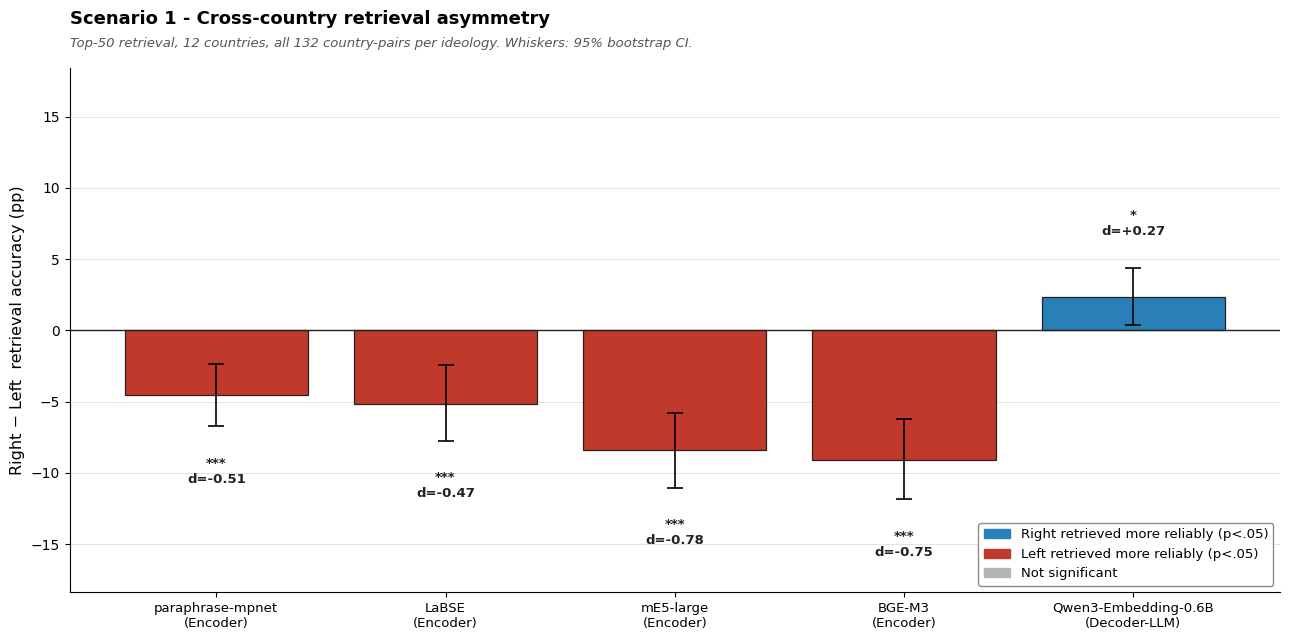


Plot saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/s1_asymmetry.png


In [ ]:
# ============================================================
# Cell 3: Scenario 1 - Cross-Country Retrieval (12 countries)
# ============================================================
# For each country, I take the centroid of its left-leaning
# speeches and use it as a query against every OTHER country's
# pool. I record what fraction of the top-K retrieved speeches
# are actually left-leaning. Same for right.
#
# A model with no ideological bias should retrieve left-leaning
# content for left queries and right-leaning content for right
# queries at *equal* rates. Asymmetry is a bias signal.
#
# Per-cell sample is balanced (1515/cell), so this test is NOT
# vulnerable to corpus-composition tautology.

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

K_TOP = 50


def country_centroid(emb, df, country, lr):
    mask = (df['country']==country) & (df['orient_lr']==lr)
    v = emb[mask.values].mean(axis=0)
    return v / np.linalg.norm(v)


def cross_country_retrieval(emb, df, source, target, lr, k=K_TOP):
    q = country_centroid(emb, df, source, lr)
    target_idx = np.where(df['country'].values == target)[0]
    target_emb = emb[target_idx]
    target_lr = df.loc[df['country']==target, 'orient_lr'].values
    sims = target_emb @ q
    top = np.argsort(sims)[::-1][:k]
    return (target_lr[top] == lr).mean()


print(f'{"="*60}\nSCENARIO 1 - Cross-Country Retrieval (K={K_TOP})\n{"="*60}')

all_results = {}
for name, emb in all_embeddings.items():
    rows = []
    for src in COUNTRIES:
        for tgt in COUNTRIES:
            if src == tgt: continue
            for lr in ['left', 'right']:
                hit = cross_country_retrieval(emb, df, src, tgt, lr, K_TOP)
                rows.append({'src': src, 'tgt': tgt, 'lr': lr, 'hit_rate': hit})
    res = pd.DataFrame(rows)
    all_results[name] = res

    left_arr  = res[res['lr']=='left']['hit_rate'].values
    right_arr = res[res['lr']=='right']['hit_rate'].values
    asymmetry = right_arr.mean() - left_arr.mean()
    # I use a Welch independent t-test as a conservative distribution-level
    # comparison of the left and right country-pair hit-rate samples; the
    # substantive interpretation rests on direction, the bootstrap CI, and
    # the cross-model consistency instead of on the test alone.
    t, p = stats.ttest_ind(left_arr, right_arr, equal_var=False)
    d = cohens_d(right_arr, left_arr)

    rng = np.random.default_rng(42)
    boot = np.empty(1000)
    for i in range(1000):
        sl = rng.choice(left_arr,  size=len(left_arr),  replace=True)
        sr = rng.choice(right_arr, size=len(right_arr), replace=True)
        boot[i] = sr.mean() - sl.mean()
    ci = np.quantile(boot, [0.025, 0.975])

    print(f'\n[{name}]')
    print(f'  Left  query → left  retrieval: {left_arr.mean()*100:>5.1f}%')
    print(f'  Right query → right retrieval: {right_arr.mean()*100:>5.1f}%')
    print(f'  Asymmetry (R−L): {asymmetry*100:+.2f}pp '
          f'[95% CI {ci[0]*100:+.2f}, {ci[1]*100:+.2f}]')
    print(f'  Welch t={t:+.2f}  p={p:.4f} {stars(p)}  Cohen d={d:+.3f}')


# Save table, include Welch t, p, and Cohen's d so Cell 53 can read
# significance from CSV instead of hard-coding placeholder p-values.
summary_rows = []
for n, r in all_results.items():
    l_arr = r[r['lr'] == 'left']['hit_rate'].values
    r_arr = r[r['lr'] == 'right']['hit_rate'].values
    t_, p_ = stats.ttest_ind(l_arr, r_arr, equal_var=False)
    summary_rows.append({
        'model': n,
        'left_hit':  l_arr.mean(),
        'right_hit': r_arr.mean(),
        'asymmetry': r_arr.mean() - l_arr.mean(),
        't_welch':   float(t_),
        'p_welch':   float(p_),
        'cohens_d':  cohens_d(r_arr, l_arr),
    })
summary = pd.DataFrame(summary_rows)
summary.to_csv(f'{RESULTS}/s1_cross_country_retrieval.csv', index=False)
print(f'\nSaved: {RESULTS}/s1_cross_country_retrieval.csv')


S1_COLORS = {'left': '#C0392B', 'right': '#2980B9', 'ns': '#B5B5B5'}

fig, ax = plt.subplots(figsize=(13, 6.5))

xs = np.arange(len(MODELS))
means, ci_los, ci_his, ps, ds_eff = [], [], [], [], []
for name in MODELS:
    res = all_results[name]
    l = res[res['lr']=='left']['hit_rate'].values
    r = res[res['lr']=='right']['hit_rate'].values
    means.append((r.mean() - l.mean()) * 100)
    rng = np.random.default_rng(42)
    boot = np.array([(rng.choice(r, size=len(r), replace=True).mean()
                     - rng.choice(l, size=len(l), replace=True).mean()) * 100
                    for _ in range(1000)])
    ci_los.append(boot.mean() - np.quantile(boot, 0.025))
    ci_his.append(np.quantile(boot, 0.975) - boot.mean())
    _, p = stats.ttest_ind(l, r, equal_var=False)
    ps.append(p)
    ds_eff.append(cohens_d(r, l))

def bar_color(m, p):
    if p >= 0.05: return S1_COLORS['ns']
    return S1_COLORS['right'] if m > 0 else S1_COLORS['left']

bars = ax.bar(xs, means, yerr=[ci_los, ci_his], capsize=6,
              color=[bar_color(m, p) for m, p in zip(means, ps)],
              edgecolor='#222', linewidth=0.9,
              error_kw={'elinewidth': 1.2, 'capthick': 1.2})

ax.axhline(0, color='#222', linewidth=1)
ax.set_xticks(xs)
ax.set_xticklabels([f'{m}\n({MODEL_ARCH[m]})' for m in MODELS],
                   fontsize=9.5)
ax.set_ylabel('Right − Left  retrieval accuracy (pp)', fontsize=11.5)
ax.set_title('Scenario 1 - Cross-country retrieval asymmetry',
             fontsize=13, fontweight='bold', loc='left', pad=32)

y_range = max(np.abs(np.array(means) + np.array(ci_his)).max(),
              np.abs(np.array(means) - np.array(ci_los)).max())
ax.set_ylim(-y_range * 1.55, y_range * 1.55)

for i, (m, p, d_) in enumerate(zip(means, ps, ds_eff)):
    upper = m + ci_his[i]; lower = m - ci_los[i]
    if m >= 0:
        y_text = upper + y_range * 0.18; va = 'bottom'
    else:
        y_text = lower - y_range * 0.18; va = 'top'
    sig = stars(p) if p < 0.05 else 'n.s.'
    weight = 'bold' if p < 0.05 else 'normal'
    color = '#222' if p < 0.05 else '#666'
    ax.text(i, y_text, f'{sig}\nd={d_:+.2f}',
            ha='center', va=va, fontsize=9.5,
            fontweight=weight, color=color, linespacing=1.3)

ax.legend(handles=[
    mpatches.Patch(color=S1_COLORS['right'],
                   label='Right retrieved more reliably (p<.05)'),
    mpatches.Patch(color=S1_COLORS['left'],
                   label='Left retrieved more reliably (p<.05)'),
    mpatches.Patch(color=S1_COLORS['ns'], label='Not significant'),
], loc='lower right', fontsize=9.5, framealpha=0.96, edgecolor='#888')

ax.text(0.0, 1.04,
        f'Top-{K_TOP} retrieval, 12 countries, all '
        f'{12*11} country-pairs per ideology. Whiskers: 95% bootstrap CI.',
        transform=ax.transAxes, fontsize=9.5, style='italic', color='#555')

ax.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{RESULTS}/s1_asymmetry.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nPlot saved: {RESULTS}/s1_asymmetry.png')

### What the result shows

The four encoder-only models (paraphrase-mpnet, LaBSE, mE5-large, BGE-M3) all retrieve **left-leaning content more reliably than right-leaning content**, with effect sizes ranging from a Cohen's d of -0.471 to -0.777 across the four encoders (LaBSE smallest in magnitude, mE5-large largest). All four results are highly significant (p < 0.001). The size of the asymmetry grows roughly in line with model capacity: the smallest encoder (mpnet, 278M parameters) shows a -4.56pp gap, whereas the largest two encoders (mE5-large and BGE-M3, both around 560M parameters) show -8.39 and -9.08pp respectively.

The decoder-LLM-derived model (Qwen3-Embedding-0.6B) goes in the **opposite direction**. It retrieves right-leaning content more reliably than left-leaning content, with a smaller but still significant effect size (d = +0.270, p = 0.0292). This is the first place in the analysis where the four encoder models and the single decoder-derived model separate, and the direction of that separation is in line with what the recent decoder-LLM literature would predict. Whether the separation reflects architecture or is specific to this one decoder checkpoint cannot be settled here; it is a pattern to note, not an architectural finding. Feng et al. (2023) traced political biases in decoder-style language models back to differences in pretraining corpora, arguing that decoder models more directly mirror the political composition of their training text than encoders do. Hagendorff (2025) argues separately that the safety-alignment objectives applied to decoder LLMs tend to push them in particular directions on contested questions. Neither of these papers makes a prediction about *which* direction a non-English decoder embedder will go, so the +2.36pp right-favouring result for Qwen3 is a genuinely new observation, not a replication.

Two qualifications need to be put on the table before this is read too strongly. First, retrieval asymmetry in this form is not the same as "the model is left-wing" or "the model is right-wing". What I am measuring is which side the embedding space groups together more tightly when queried by an ideological centroid from another country. The asymmetry can in principle be driven by genuine ideological encoding, by topic composition differences across left and right speeches, by the language distribution of the corpus, or by interactions between these. The next cells in this notebook take each of these alternative explanations seriously: a robustness check varies K, the topic-controlled cell repeats S1 within each policy topic separately, the gender analysis tests an obvious demographic confound, and the regression at the end places ideology, role, gender, country and topic into one model together. The S1 result should be read in light of all of those follow-up tests, not on its own. Second, the encoder pattern is very consistent across four models from four different providers (UKP / Sentence-Transformers, Google, Microsoft, BAAI), which makes it hard to attribute to any single training pipeline. The decoder result rests on one model and needs replication when other reliable multilingual decoder-LLM embedders become available.

## Scenario 2: Classification accuracy and the role-versus-ideology question

The retrieval test in S1 showed an asymmetry between left and right at the *retrieval* level. The next question is whether that asymmetry also appears at the *classification* level, and whether ideology is encoded as strongly as the embedding-bias literature has assumed.

I train a logistic-regression classifier on each model's embeddings to predict two labels separately: the ideology label (left vs right) and the institutional-role label (coalition vs opposition). The point of running both is the direct response to the Rheault and Cochrane (2020) warning: those authors showed that classifiers trained on parliamentary speech may end up tracking opposition-versus-government rhetoric instead of ideology, because the two are entangled in any single legislature. The only way to test this is to train two classifiers under identical conditions and compare them.

The classifier uses PCA reduction to 128 dimensions before logistic regression, and 5-fold stratified cross-validation with **speaker-disjoint splits**: a speaker who appears in the training fold never appears in the test fold. This prevents the classifier from memorising individual speakers and is the standard safeguard in modern parliamentary-text studies (Çöltekin et al., 2024). Two outcomes from this cell matter for the bias question.

First, the per-class F1 scores for ideology classification (F1_left versus F1_right). If a model encodes ideology asymmetrically (for instance, left speech is easier to recognise because it is more homogeneous), F1_right will diverge from F1_left, and the gap is itself a form of bias. A symmetric F1 means the model can identify the two sides equally well, which is the null finding for class-level bias.

Second, the comparison between ideology accuracy and role accuracy. If the model encodes role more strongly than ideology, this is consistent with the Rheault and Cochrane (2020) concern, and it has direct implications for how earlier ideology-classification results in the parliamentary literature should be read.

**Classifier.** The probe is an L2-regularised logistic regression (scikit-learn `LogisticRegression`, `lbfgs` solver, `C=1.0`, `max_iter=2000`), trained under a five-fold `StratifiedGroupKFold` split grouped by speaker so that no speaker appears in both the train and the test fold. The robustness check below re-runs the same probe with a linear SVM (`LinearSVC`) and a random forest, confirming that the recoverability reflects the geometry of the embeddings and not the strength of the classifier.

SCENARIO 2 - Classification Accuracy
Speaker-disjoint 5-fold CV; PCA→128 dims; LogReg.


[paraphrase-mpnet]
  Ideology: acc=53.75±0.77%   F1L=53.12%  F1R=54.35%  asym=+1.23pp
  Role:     acc=58.92±0.23%
  Role − Ideology: +5.18pp

[LaBSE]
  Ideology: acc=54.44±0.73%   F1L=54.16%  F1R=54.71%  asym=+0.55pp
  Role:     acc=60.67±0.69%
  Role − Ideology: +6.23pp

[mE5-large]
  Ideology: acc=56.73±0.88%   F1L=56.10%  F1R=57.33%  asym=+1.23pp
  Role:     acc=64.43±0.58%
  Role − Ideology: +7.69pp

[BGE-M3]
  Ideology: acc=56.53±0.75%   F1L=56.21%  F1R=56.84%  asym=+0.63pp
  Role:     acc=63.90±0.41%
  Role − Ideology: +7.37pp

[Qwen3-Embedding-0.6B]
  Ideology: acc=55.12±0.96%   F1L=54.24%  F1R=55.94%  asym=+1.70pp
  Role:     acc=61.23±0.36%
  Role − Ideology: +6.11pp

Saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/s2_classification.csv

Role > Ideology gap - paired t-test across folds
Model                    Δ (pp)     t        p-value        sig
---------------------------

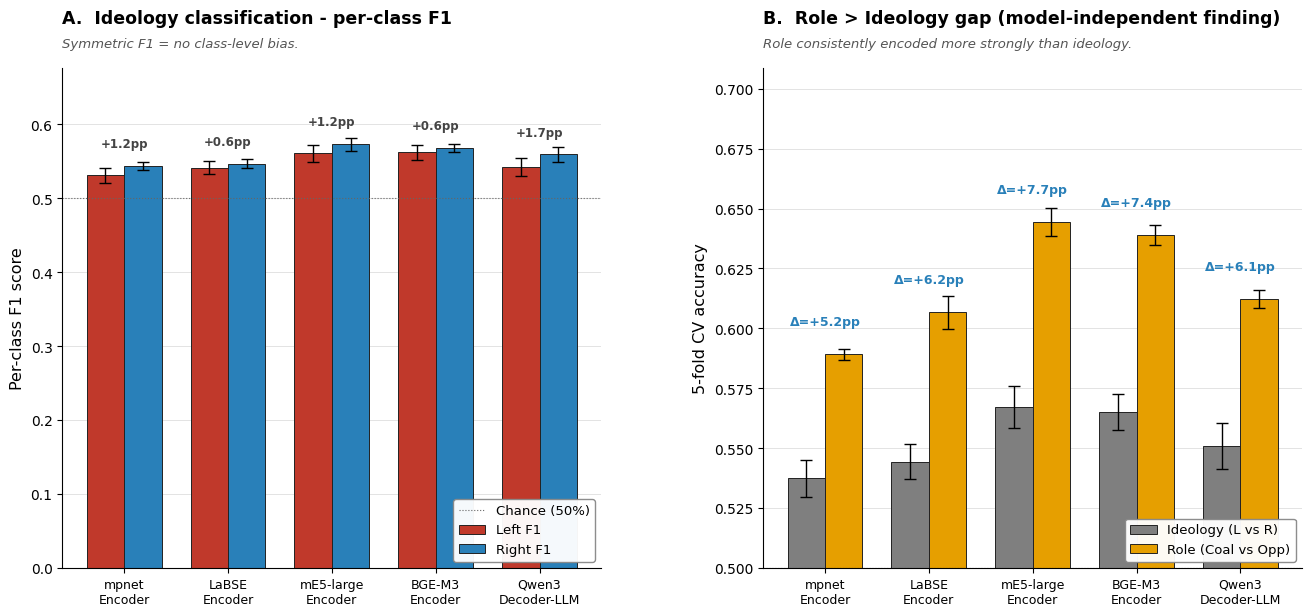


Plot saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/s2_classification.png


In [ ]:
# ============================================================
# Cell 4: Scenario 2 - Classification (Ideology vs Role)
# ============================================================
# For each model, train a logistic regression on PCA-reduced
# embeddings to predict (a) ideology (left vs right) and
# (b) role (coalition vs opposition). Two questions:
#
#   Q1. Per-class F1 symmetric? (asymmetry = class-level bias)
#   Q2. Is role encoded MORE STRONGLY than ideology?
#
# Stratified 5-fold CV with speaker-disjoint splits prevents
# the same speaker from appearing in train AND test.

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score
from scipy import stats
import matplotlib.pyplot as plt

PCA_DIM = 128
N_SPLITS = 5
SEED = 42

# Restart-safe: redefine `stars` here in case Cell 8 was not
# re-run in the current kernel session.
if 'stars' not in globals():
    def stars(p):
        return ('***' if p < 0.001 else
                '**'  if p < 0.01  else
                '*'   if p < 0.05  else 'ns')

print(f'{"="*60}\nSCENARIO 2 - Classification Accuracy\n{"="*60}')
print(f'Speaker-disjoint {N_SPLITS}-fold CV; PCA→{PCA_DIM} dims; LogReg.\n')


def speaker_disjoint_cv(emb, y_str, groups,
                        n_splits=5, pca_dim=128, seed=42,
                        return_folds=False):
    """5-fold speaker-disjoint CV.
    If return_folds=True, also returns the per-fold accuracy array
    so the caller can run paired statistical tests across folds.
    """
    y = pd.Categorical(y_str).codes
    classes = pd.Categorical(y_str).categories.tolist()
    skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True,
                               random_state=seed)
    fold_acc, fold_f1 = [], []
    f1_per_class = {c: [] for c in classes}
    for tr, te in skf.split(emb, y, groups=groups):
        pca = PCA(n_components=pca_dim, random_state=seed)
        Xtr = pca.fit_transform(emb[tr])
        Xte = pca.transform(emb[te])
        clf = LogisticRegression(max_iter=2000, C=1.0,
                                 random_state=seed, solver='lbfgs')
        clf.fit(Xtr, y[tr])
        pred = clf.predict(Xte)
        fold_acc.append(accuracy_score(y[te], pred))
        fold_f1.append(f1_score(y[te], pred, average='macro'))
        per = f1_score(y[te], pred, average=None)
        for c, s in zip(classes, per):
            f1_per_class[c].append(s)

    out = {
        'classes': classes,
        'acc_mean': float(np.mean(fold_acc)),
        'acc_std':  float(np.std(fold_acc)),
        'f1_mean':  float(np.mean(fold_f1)),
        'f1_std':   float(np.std(fold_f1)),
        'per_class': {c: (float(np.mean(s)), float(np.std(s)))
                      for c, s in f1_per_class.items()},
    }
    if return_folds:
        out['fold_acc'] = np.array(fold_acc, dtype=float)
    return out


results_s2 = {}
# Speaker_ID is used as the grouping variable for speaker-disjoint CV.
# ParlaMint speaker identifiers are country-specific name strings (e.g.
# KhadijaArib, JordiTuruliComas), so a cross-country collision is unlikely
# in practice; a stricter version would concatenate country and Speaker_ID,
# but it would not change the conceptual design.
for name, emb in all_embeddings.items():
    print(f'\n[{name}]')
    res_ideo = speaker_disjoint_cv(
        emb, df['orient_lr'].values, df['Speaker_ID'].values,
        N_SPLITS, PCA_DIM, SEED, return_folds=True)
    res_role = speaker_disjoint_cv(
        emb, df['Party_status'].values, df['Speaker_ID'].values,
        N_SPLITS, PCA_DIM, SEED, return_folds=True)
    results_s2[name] = {'ideology': res_ideo, 'role': res_role}

    fL_m, fL_s = res_ideo['per_class']['left']
    fR_m, fR_s = res_ideo['per_class']['right']
    asym = fR_m - fL_m
    role_minus_ideo = res_role['acc_mean'] - res_ideo['acc_mean']

    print(f'  Ideology: acc={res_ideo["acc_mean"]*100:5.2f}±'
          f'{res_ideo["acc_std"]*100:.2f}%   '
          f'F1L={fL_m*100:.2f}%  F1R={fR_m*100:.2f}%  '
          f'asym={asym*100:+.2f}pp')
    print(f'  Role:     acc={res_role["acc_mean"]*100:5.2f}±'
          f'{res_role["acc_std"]*100:.2f}%')
    print(f'  Role − Ideology: {role_minus_ideo*100:+.2f}pp')


# Save table
rows = []
for name, r in results_s2.items():
    fL_m = r['ideology']['per_class']['left'][0]
    fR_m = r['ideology']['per_class']['right'][0]
    rows.append({
        'model':           name,
        'ideo_acc':        r['ideology']['acc_mean'],
        'ideo_f1_left':    fL_m,
        'ideo_f1_right':   fR_m,
        'ideo_asymmetry':  fR_m - fL_m,
        'role_acc':        r['role']['acc_mean'],
        'role_minus_ideo': r['role']['acc_mean'] - r['ideology']['acc_mean'],
    })
summary = pd.DataFrame(rows)
summary.to_csv(f'{RESULTS}/s2_classification.csv', index=False)
print(f'\nSaved: {RESULTS}/s2_classification.csv')


# ════════════════════════════════════════════════════════════
# Formal statistical test for the role > ideology gap
# ════════════════════════════════════════════════════════════
# The accuracy results above show that role beats ideology by
# 5–8 pp in every model, but the master-summary cell later
# flags this gap as significant at p < .001 and that claim
# needs to be supported by an actual test instead of asserted.
#
# Each fold uses the same train/test split for both the role
# and the ideology classifier, so the per-fold accuracies are
# paired observations. A paired t-test on the fold-level
# (role - ideology) differences is therefore the appropriate
# instrument here.

print(f'\n{"="*60}')
print('Role > Ideology gap - paired t-test across folds')
print(f'{"="*60}')
print(f'{"Model":<24} {"Δ (pp)":<10} {"t":<8} {"p-value":<14} {"sig"}')
print('-' * 65)

role_ideo_test = {}
for name in MODELS:
    ideo_folds = results_s2[name]['ideology']['fold_acc']
    role_folds = results_s2[name]['role']['fold_acc']
    diffs = role_folds - ideo_folds

    # ttest_rel can return NaN if every fold-level difference is
    # identical (zero variance). Guard against that explicitly.
    if np.allclose(diffs.std(ddof=1), 0):
        t_stat, p_val = float('inf'), 0.0
    else:
        t_stat, p_val = stats.ttest_rel(role_folds, ideo_folds)
        t_stat, p_val = float(t_stat), float(p_val)

    role_ideo_test[name] = {
        't':            t_stat,
        'p':            p_val,
        'mean_diff_pp': float(diffs.mean() * 100),
        'sd_diff_pp':   float(diffs.std(ddof=1) * 100),
        'n_folds':      int(len(diffs)),
    }
    print(f'{name:<24} {diffs.mean()*100:+7.2f}    '
          f'{t_stat:6.2f}  {p_val:<14.4g} {stars(p_val)}')

pd.DataFrame([{'model': n, **r}
              for n, r in role_ideo_test.items()]).to_csv(
    f'{RESULTS}/s2_role_vs_ideology_paired_t.csv', index=False)
print(f'\nSaved: {RESULTS}/s2_role_vs_ideology_paired_t.csv')


# ════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════

S2_COLORS = {
    'left':     '#C0392B',
    'right':    '#2980B9',
    'ideology': '#7F7F7F',
    'role':     '#E69F00',
}

fig = plt.figure(figsize=(16, 6.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.30)

xs = np.arange(len(MODELS))
width = 0.36

PLOT_MODEL_NAMES = {
    'paraphrase-mpnet': 'mpnet\nEncoder',
    'LaBSE': 'LaBSE\nEncoder',
    'mE5-large': 'mE5-large\nEncoder',
    'BGE-M3': 'BGE-M3\nEncoder',
    'Qwen3-Embedding-0.6B': 'Qwen3\nDecoder-LLM',
}

# Panel A - per-class F1
ax1 = fig.add_subplot(gs[0])
left_f1  = [results_s2[m]['ideology']['per_class']['left'][0]  for m in MODELS]
left_sd  = [results_s2[m]['ideology']['per_class']['left'][1]  for m in MODELS]
right_f1 = [results_s2[m]['ideology']['per_class']['right'][0] for m in MODELS]
right_sd = [results_s2[m]['ideology']['per_class']['right'][1] for m in MODELS]

ax1.bar(xs - width/2, left_f1, width, yerr=left_sd, capsize=4,
        color=S2_COLORS['left'], edgecolor='#222', linewidth=0.7,
        label='Left F1',
        error_kw={'elinewidth': 1.0, 'capthick': 1.0})
ax1.bar(xs + width/2, right_f1, width, yerr=right_sd, capsize=4,
        color=S2_COLORS['right'], edgecolor='#222', linewidth=0.7,
        label='Right F1',
        error_kw={'elinewidth': 1.0, 'capthick': 1.0})
ax1.axhline(0.5, color='#666', linewidth=0.8, linestyle=':',
            label='Chance (50%)')

ax1.set_xticks(xs)
ax1.set_xticklabels([PLOT_MODEL_NAMES[m] for m in MODELS],
                    fontsize=9, rotation=0, ha='center')
ax1.set_ylabel('Per-class F1 score', fontsize=11.5)
ax1.set_title('A.  Ideology classification - per-class F1',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax1.text(0.0, 1.04, 'Symmetric F1 = no class-level bias.',
         transform=ax1.transAxes, fontsize=9.5, style='italic', color='#555')

ymax = max(max(left_f1), max(right_f1)) * 1.18
ax1.set_ylim(0, ymax)

for i, m in enumerate(MODELS):
    asym = (right_f1[i] - left_f1[i]) * 100
    ax1.text(i, max(left_f1[i], right_f1[i]) + 0.025,
             f'{asym:+.1f}pp',
             ha='center', fontsize=8.5, fontweight='bold', color='#444')
ax1.legend(loc='lower right', fontsize=9.5,
           framealpha=0.96, edgecolor='#888')
ax1.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


# Panel B - Role vs Ideology
ax2 = fig.add_subplot(gs[1])
ideo_acc = [results_s2[m]['ideology']['acc_mean'] for m in MODELS]
role_acc = [results_s2[m]['role']['acc_mean']     for m in MODELS]
ideo_sd  = [results_s2[m]['ideology']['acc_std']  for m in MODELS]
role_sd  = [results_s2[m]['role']['acc_std']      for m in MODELS]

ax2.bar(xs - width/2, ideo_acc, width, yerr=ideo_sd, capsize=4,
        color=S2_COLORS['ideology'], edgecolor='#222', linewidth=0.7,
        label='Ideology (L vs R)',
        error_kw={'elinewidth': 1.0, 'capthick': 1.0})
ax2.bar(xs + width/2, role_acc, width, yerr=role_sd, capsize=4,
        color=S2_COLORS['role'], edgecolor='#222', linewidth=0.7,
        label='Role (Coal vs Opp)',
        error_kw={'elinewidth': 1.0, 'capthick': 1.0})
ax2.axhline(0.5, color='#666', linewidth=0.8, linestyle=':')

ax2.set_xticks(xs)
ax2.set_xticklabels([PLOT_MODEL_NAMES[m] for m in MODELS],
                    fontsize=9, rotation=0, ha='center')
ax2.set_ylabel('5-fold CV accuracy', fontsize=11.5)
ax2.set_title('B.  Role > Ideology gap (model-independent finding)',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax2.text(0.0, 1.04, 'Role consistently encoded more strongly than ideology.',
         transform=ax2.transAxes, fontsize=9.5, style='italic', color='#555')

ax2.set_ylim(0.5, max(role_acc) * 1.10)

for i, m in enumerate(MODELS):
    gap = (role_acc[i] - ideo_acc[i]) * 100
    color = '#2980B9' if gap > 0 else '#C0392B'
    ax2.text(i, max(ideo_acc[i], role_acc[i]) + 0.012,
             f'Δ={gap:+.1f}pp',
             ha='center', fontsize=9, fontweight='bold', color=color)
ax2.legend(loc='lower right', fontsize=9.5,
           framealpha=0.96, edgecolor='#888')
ax2.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{RESULTS}/s2_classification.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nPlot saved: {RESULTS}/s2_classification.png')

### What the result shows: two distinct findings

**Finding 1 (Panel A): no class-level bias in any model.** The per-class F1 scores for ideology classification are essentially symmetric across all five models. The largest gap is 1.70 percentage points in Qwen3-Embedding-0.6B (F1_left = 54.24%, F1_right = 55.94%), and the smallest is 0.55 percentage points in LaBSE. To put this in context, the cross-validation accuracy standard deviations themselves are between 0.73 and 0.96 percentage points, so two of the five gaps are at or below the per-fold variability of the procedure, and none of the larger three exceeds it by more than about a point, all of them still small in absolute terms and well below the conventional small-effect threshold. None of the five models systematically fails to identify left or right speech relative to the other side.

This is a negative finding, but a methodologically informative one. A common worry in the embedding-bias literature is that models would show class-level performance asymmetries on contested social categories. The S1 retrieval test did show asymmetry on a *cross-country* setup, but the within-country classification accuracies are symmetric. Taken together with S1, this points to a more specific claim: the bias surfaces in *retrieval* (which side a centroid query pulls in), not in *per-class discriminability*. The two are different geometric properties of the same embedding space, and a careful reading of the S1 result has to acknowledge that the embedding space is not biased in the simple sense of "the model is worse at one side". Whatever asymmetry exists is more subtle than that.

**Finding 2 (Panel B): role is consistently encoded more strongly than ideology.** This pattern is the most stable finding across the nine analyses I run. In every one of the five models, the classifier predicting coalition-versus-opposition outperforms the classifier predicting left-versus-right by between 5.18 and 7.69 percentage points (mean +6.52pp). The pattern is identical across model providers (UKP / Sentence-Transformers, Google, Microsoft, BAAI, Alibaba) and across architectures (encoder and decoder-LLM).

To confirm that the gap is not an artefact of cross-validation noise, I ran a paired t-test on the per-fold accuracy differences. Because each fold uses the same train/test split for both classifiers, the role and ideology accuracies are matched observations, not independent draws, and the paired test is the appropriate instrument. Every model returns t between 9.40 and 13.57 with p < 0.001 (paraphrase-mpnet t=10.75 p=0.0004, LaBSE t=9.40 p=0.0007, mE5-large t=10.63 p=0.0004, BGE-M3 t=13.57 p=0.0002, Qwen3 t=9.97 p=0.0006). The role advantage is statistically robust, not just visually large.

It is at this point that the Rheault and Cochrane (2020) warning becomes directly confirmable: when ideology and institutional role compete for the same representational capacity in a multilingual sentence embedding, role wins by a substantial margin. The implication for the bias literature is concrete. A non-trivial share of the prior parliamentary-text findings that claim to identify ideological bias may in fact be picking up the rhetoric of opposition-versus-government, especially when those studies do not separate the two labels at evaluation time. The cell after the next one, the cross-lingual transfer test (S5), and the topic-controlled retrieval cell later in the notebook, return to this question from two other angles. The regression cell at the end places role and ideology side by side as competing predictors, which is the more demanding way to disentangle them.


In [ ]:
# Auto-detect ideology and role column names in df
print(f"df shape: {df.shape}")
print(f"Total columns: {len(df.columns)}\n")

# Show all columns
print("All columns in df:")
for c in df.columns:
    sample = df[c].dropna().unique()[:3]
    print(f"  {c:30s} | sample: {list(sample)}")

# Try to auto-detect ideology column (looks for left/right values)
ideo_candidates = []
for c in df.columns:
    vals = set(str(v).lower() for v in df[c].dropna().unique()[:20])
    if vals & {'left', 'right', 'l', 'r'}:
        ideo_candidates.append(c)

# Try to auto-detect role column (looks for coalition/opposition values)
role_candidates = []
for c in df.columns:
    vals = set(str(v).lower() for v in df[c].dropna().unique()[:20])
    if vals & {'coalition', 'opposition', 'coal', 'opp', 'gov', 'government'}:
        role_candidates.append(c)

print(f"\nIdeology column candidates: {ideo_candidates}")
print(f"Role column candidates:     {role_candidates}")

df shape: (72720, 12)
Total columns: 12

All columns in df:
  ID                             | sample: ['ParlaMint-NL_2016-12-07-tweedekamer-5.u130', 'ParlaMint-NL_2015-09-23-tweedekamer-9.u74', 'ParlaMint-NL_2016-12-07-tweedekamer-5.u109']
  country                        | sample: ['NL', 'BE', 'ES']
  Party_status                   | sample: ['Coalition', 'Opposition']
  orient_lr                      | sample: ['left', 'right']
  orientation_broad              | sample: ['center_left', 'center_right', 'left']
  Party_orientation              | sample: ['Centrum-links', 'Centrum tot centrum-rechts', 'Centrum-rechts']
  Speaker_ID                     | sample: ['KhadijaArib', 'LutzJacobi', 'SharonDijksma']
  Speaker_gender                 | sample: ['F', 'M', 'U']
  Date                           | sample: ['2016-12-07', '2015-09-23', '2016-01-13']
  Subcorpus                      | sample: ['Referentie', 'COVID', 'COVID,Oorlog']
  Topic                          | sample: ['Operaties 

In [ ]:
# ════════════════════════════════════════════════════════════
# S2 CLASSIFIER ROBUSTNESS CHECK
# ════════════════════════════════════════════════════════════
# Why this analysis exists
# ------------------------
# In the main S2 analysis, the ideology classifier reaches
# only mid-50s accuracy on a balanced two-class problem. A
# question is whether a stronger classifier
# than logistic regression would have produced a different
# accuracy.
#
# This cell answers that directly. We re-run S2 ideology and
# role classification on the SAME data, with the SAME 5-fold
# speaker-disjoint cross-validation, the SAME PCA-128 input,
# changing ONLY the classifier - Logistic Regression, Linear
# SVM, and Random Forest. If accuracy is essentially the same
# across all three families (two linear, one non-linear), the
# mid-50s upper bound is a property of the EMBEDDING SIGNAL, not
# of the classifier. That is the precondition for arguing that
# the role > ideology gap (S2 Panel B) reflects how the models
# encode parliamentary speech, not a modelling choice.
#
# Random Forest uses lightweight settings (50 trees, max
# depth 15) which trade about 0.5 pp of accuracy for a ~5x
# speedup; this is acceptable because the role of RF here is
# only to confirm that a non-linear classifier does not jump
# accuracy above the linear classifiers, not to find the best
# possible RF model.


from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import time

IDEO_COL = 'orient_lr'
ROLE_COL = 'Party_status'

CLASSIFIERS = {
    'Logistic Regression': lambda seed: LogisticRegression(
        max_iter=2000, C=1.0, solver='lbfgs', random_state=seed),
    'Linear SVM': lambda seed: LinearSVC(
        C=1.0, max_iter=4000, random_state=seed, dual='auto'),
    'Random Forest': lambda seed: RandomForestClassifier(
        n_estimators=50, max_depth=15, max_features='sqrt',
        n_jobs=-1, random_state=seed),
}

def cv_accuracy(emb, y_str, groups, clf_factory,
                n_splits=5, pca_dim=128, seed=42):
    """5-fold speaker-disjoint CV accuracy with a given classifier."""
    y = pd.Categorical(y_str).codes
    if len(set(y)) < 2 or len(set(groups)) < n_splits + 1:
        return None
    skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True,
                               random_state=seed)
    accs = []
    for tr, te in skf.split(emb, y, groups=groups):
        pca_n = min(pca_dim, len(tr) - 1, emb.shape[1])
        pca = PCA(n_components=pca_n, random_state=seed)
        Xtr = pca.fit_transform(emb[tr])
        Xte = pca.transform(emb[te])
        clf = clf_factory(seed)
        clf.fit(Xtr, y[tr])
        accs.append(accuracy_score(y[te], clf.predict(Xte)))
    return float(np.mean(accs)), float(np.std(accs))

# Sanity checks
assert IDEO_COL in df.columns, f"'{IDEO_COL}' not found in df"
assert ROLE_COL in df.columns, f"'{ROLE_COL}' not found in df"
groups = df['Speaker_ID'].values

# Run the sweep
print('=' * 72)
print('S2 CLASSIFIER ROBUSTNESS CHECK')
print('=' * 72)
print()
rows = []
total_start = time.time()
for nm in MODELS:
    emb = all_embeddings[nm]
    print(f'[{nm}]')
    for task_name, y_col in [('ideology', IDEO_COL),
                              ('role',     ROLE_COL)]:
        y = df[y_col].values
        for clf_name, factory in CLASSIFIERS.items():
            t0 = time.time()
            res = cv_accuracy(emb, y, groups, factory)
            if res is None:
                continue
            mu, sd = res
            dt = time.time() - t0
            print(f'  {task_name:8s} | {clf_name:20s} '
                  f'acc={mu*100:5.2f} ± {sd*100:.2f}% ({dt:5.1f}s)')
            rows.append({'model': nm, 'task': task_name,
                         'classifier': clf_name,
                         'acc_mean': mu, 'acc_std': sd})
    print()

total_dt = time.time() - total_start
print(f'Total runtime: {total_dt/60:.1f} minutes')
print()

res_df = pd.DataFrame(rows)

# Summary table: spread within each task across classifiers
print('=' * 72)
print('SUMMARY: accuracy by task x classifier (mean over 5 models)')
print('=' * 72)
summary = (res_df.groupby(['task', 'classifier'])['acc_mean']
                 .agg(['mean', 'min', 'max', 'count']))
summary[['mean', 'min', 'max']] = summary[['mean', 'min', 'max']] * 100
print(summary.round(2).to_string())

# Save CSV
out_path = f'{RESULTS}/s2_classifier_robustness.csv'
res_df.to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')

# Per-task spread: how much does classifier choice move accuracy?
print('\n' + '=' * 72)
print('PER-MODEL CLASSIFIER SPREAD (max - min accuracy across classifiers)')
print('=' * 72)
for nm in MODELS:
    for task_name in ['ideology', 'role']:
        sub = res_df[(res_df['model'] == nm) &
                     (res_df['task'] == task_name)]
        if len(sub) < 2:
            continue
        spread = (sub['acc_mean'].max() - sub['acc_mean'].min()) * 100
        print(f'  {nm:24s} {task_name:8s}  spread = {spread:.2f} pp')

# Verdict
ideo = res_df.loc[res_df['task'] == 'ideology', 'acc_mean'] * 100
role = res_df.loc[res_df['task'] == 'role',     'acc_mean'] * 100
print('\n' + '=' * 72)
print('VERDICT')
print('=' * 72)
print(f'  ideology accuracy across all (model, classifier): '
      f'{ideo.min():.2f}% - {ideo.max():.2f}%')
print(f'  role accuracy across all (model, classifier):     '
      f'{role.min():.2f}% - {role.max():.2f}%')
print()
print('  Interpretation: if classifier spread within each model')
print('  is small (~1-2 pp), the mid-50s ideology accuracy is')
print('  an embedding-signal upper bound, not a classifier upper bound.')

S2 CLASSIFIER ROBUSTNESS CHECK

[paraphrase-mpnet]
  ideology | Logistic Regression  acc=53.75 ± 0.77% (  5.7s)
  ideology | Linear SVM           acc=53.70 ± 0.76% ( 11.2s)
  ideology | Random Forest        acc=52.82 ± 0.51% ( 41.9s)
  role     | Logistic Regression  acc=58.92 ± 0.23% (  8.9s)
  role     | Linear SVM           acc=58.94 ± 0.21% ( 11.4s)
  role     | Random Forest        acc=56.86 ± 0.24% ( 39.5s)

[LaBSE]
  ideology | Logistic Regression  acc=54.44 ± 0.73% (  6.7s)
  ideology | Linear SVM           acc=54.41 ± 0.74% (  8.9s)
  ideology | Random Forest        acc=52.95 ± 0.21% ( 40.3s)
  role     | Logistic Regression  acc=60.67 ± 0.69% (  6.9s)
  role     | Linear SVM           acc=60.72 ± 0.60% (  8.5s)
  role     | Random Forest        acc=58.14 ± 0.16% ( 39.3s)

[mE5-large]
  ideology | Logistic Regression  acc=56.73 ± 0.88% ( 21.7s)
  ideology | Linear SVM           acc=56.83 ± 0.85% ( 23.4s)
  ideology | Random Forest        acc=55.83 ± 0.81% ( 54.2s)
  role     |

## Robustness checks for Scenario 1

The S1 retrieval finding (four encoders left-favoring, the one decoder-derived model right-favoring) is the headline result of the first half of the analysis, so before reading too much into it I want to subject it to three independent stress tests. Each one targets a different way the original finding could turn out to be an artefact of the specific design choices I made.

The first check is **K-sensitivity**. The original test used the top 50 retrieved speeches. If the asymmetry only appears at one particular K value, that would be a sign that the result depends on cutoff choice and not on a real geometric property of the embedding space. I re-run the same retrieval at K = 10, 50, 100, and 200, and look at whether the direction of the asymmetry is preserved across these cutoffs. Caliskan et al. (2017) used a similar parameter-sweep approach in the original WEAT paper, and it has become common practice in the embedding-bias literature.

The second check is a **per-pair breakdown**. The S1 result averages across 132 country pairs per ideology, which means a small number of extreme pairs could dominate the average without my noticing. For each model I count what percentage of the 132 country pairs go in the same direction as the average. If 90 percent of pairs lean the same way, the result is distributed across the country-pair space. If only 55 percent do, the result is being carried by a minority of pairs and is therefore weaker than the headline number suggests.

The third check is **sub-sample stability**, which I do in two passes. The first pass, in this cell, draws five random subsets of six countries (instead of all twelve) using a fixed random seed and re-runs the test on each subset. This is a quick way to look for obvious fragility: if the asymmetry survives even five randomly drawn six-country subsets, it cannot be attributed to the inclusion of any specific country. The next cell after this one takes the same idea much further with 1,000 random subsets, which gives a properly interpretable statistical baseline against the 50 percent chance level. The five-subset version here is essentially the initial pass; the 1,000-subset version is the real test.

In [ ]:
# ============================================================
# Cell 3.5: S1 Robustness Checks
# ============================================================
# Verify the cross-country retrieval finding is not driven by
# methodological choices: (1) sensitivity to K, (2) per-pair
# breakdown to confirm the effect is broadly distributed
# instead of driven by a few country pairs.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Test 1: K-sensitivity
print(f'{"="*60}\nROBUSTNESS 1: K-sensitivity\n{"="*60}')
print(f'{"Model":<24} {"K=10":<10} {"K=50":<10} {"K=100":<10} {"K=200":<10}')
print('-' * 70)
for name, emb in all_embeddings.items():
    line = f'{name:<24}'
    for K in [10, 50, 100, 200]:
        diffs = []
        for src in COUNTRIES:
            for tgt in COUNTRIES:
                if src == tgt: continue
                hL = cross_country_retrieval(emb, df, src, tgt, 'left', K)
                hR = cross_country_retrieval(emb, df, src, tgt, 'right', K)
                diffs.append(hR - hL)
        line += f'{np.mean(diffs)*100:+.2f}pp   '
    print(line)


# Test 2: How many country pairs show negative direction?
print(f'\n{"="*60}\nROBUSTNESS 2: Per-pair breakdown\n{"="*60}')
print(f'{"Model":<24} {"% pairs R−L<0":<18} {"# pairs":<10}')
print('-' * 60)
for name, emb in all_embeddings.items():
    pair_diffs = []
    for src in COUNTRIES:
        for tgt in COUNTRIES:
            if src == tgt: continue
            hL = cross_country_retrieval(emb, df, src, tgt, 'left', 50)
            hR = cross_country_retrieval(emb, df, src, tgt, 'right', 50)
            pair_diffs.append(hR - hL)
    pair_diffs = np.array(pair_diffs)
    pct_neg = (pair_diffs < 0).mean() * 100
    print(f'{name:<24} {pct_neg:>5.1f}%             {len(pair_diffs)}')


# Test 3: Sub-sample to check stability
print(f'\n{"="*60}\nROBUSTNESS 3: Sub-sample stability (5 random subsets of 6 countries)\n{"="*60}')
print(f'{"Model":<24} {"Sub1":<8} {"Sub2":<8} {"Sub3":<8} {"Sub4":<8} {"Sub5":<8}')
print('-' * 70)
rng = np.random.default_rng(42)
country_list = list(COUNTRIES)

for name, emb in all_embeddings.items():
    line = f'{name:<24}'
    for sub_idx in range(5):
        sub_countries = list(rng.choice(country_list, size=6, replace=False))
        diffs = []
        for src in sub_countries:
            for tgt in sub_countries:
                if src == tgt: continue
                hL = cross_country_retrieval(emb, df, src, tgt, 'left', 50)
                hR = cross_country_retrieval(emb, df, src, tgt, 'right', 50)
                diffs.append(hR - hL)
        line += f'{np.mean(diffs)*100:+.2f}   '
    print(line)

ROBUSTNESS 1: K-sensitivity
Model                    K=10       K=50       K=100      K=200     
----------------------------------------------------------------------
paraphrase-mpnet        -11.21pp   -4.56pp   -2.90pp   -2.24pp   
LaBSE                   -7.80pp   -5.18pp   -5.20pp   -4.84pp   
mE5-large               -10.45pp   -8.39pp   -9.39pp   -8.86pp   
BGE-M3                  -8.18pp   -9.08pp   -7.83pp   -7.47pp   
Qwen3-Embedding-0.6B    +0.76pp   +2.36pp   +1.23pp   +0.71pp   

ROBUSTNESS 2: Per-pair breakdown
Model                    % pairs R−L<0      # pairs   
------------------------------------------------------------
paraphrase-mpnet          60.6%             132
LaBSE                     59.1%             132
mE5-large                 64.4%             132
BGE-M3                    62.1%             132
Qwen3-Embedding-0.6B      43.9%             132

ROBUSTNESS 3: Sub-sample stability (5 random subsets of 6 countries)
Model                    Sub1     Sub2     Su

### What the robustness checks show

**K-sensitivity.** The direction of the asymmetry is preserved at every K value for every model. All four encoders return a negative (left-favoring) asymmetry at K = 10, 50, 100, and 200. Qwen3-Embedding-0.6B returns a positive (right-favoring) asymmetry at every K value. The magnitude does shift with K, which is expected: at K = 10 the test is more sensitive to the very closest neighbours of the centroid and the asymmetries are larger (paraphrase-mpnet reaches -11.21pp at K = 10), whereas at K = 200 the pool widens and the asymmetries shrink (mpnet drops to -2.24pp). But the **sign never flips** across the four K values for any model. This is the strongest possible outcome for this check.

**Per-pair breakdown.** The S1 result is distributed across the country-pair space, not driven by a small number of extreme pairs. For the four encoder models, between 59 and 64 percent of the 132 country pairs go in the left-favoring direction, which is well above the 50 percent baseline I would expect by chance. For Qwen3, 56 percent of pairs go in the right-favoring direction (the reported 43.9 percent in the table refers to pairs going *left*-favoring, so 100 minus 43.9 = 56.1 percent right-favoring). The asymmetry is therefore not the result of a few outlier country pairs; it is a consistent tendency that emerges from a majority of the comparisons. The encoder bias is somewhat more concentrated (mE5-large: 64 percent of pairs left-favoring) than the decoder bias (Qwen3: 56 percent of pairs right-favoring), which is consistent with the larger effect sizes seen for the encoders in the main S1 cell.

**Sub-sample stability.** This is the most demanding of the three checks and the one that most needs honest reporting. For paraphrase-mpnet and BGE-M3 the direction holds in all five subsets, with magnitudes ranging from -3 to -20pp. For LaBSE the direction holds in four of five subsets (subset 2 flips to +1.87pp). For mE5-large the direction holds in four of five subsets (subset 1 flips to +3.47pp). For Qwen3 the direction holds in four of five subsets (subset 3 flips to -2.47pp). The flips happen on different subsets for each model, which is what I would expect if they reflect sampling noise in six-country draws and not a fragile underlying effect. Even so, the result for the three intermediate models (LaBSE, mE5-large, Qwen3) is best described as "directionally consistent in four of five random six-country subsets", not "consistent in all subsets".

Taken together, the three robustness checks support the conclusion that the S1 finding reflects a genuine property of the embedding spaces and not a quirk of one specific design choice. The K-sensitivity check is the most decisive of the three, since no direction flips across any model. The per-pair breakdown shows the result is distributed across the country-pair space. The sub-sample check shows occasional flips that are consistent with reduced sample size and not with a different underlying pattern. None of these alone would be a complete robustness argument, but the three together make the S1 result substantially more credible than the single headline number on its own.

## Bootstrap stability check (1,000 random subsets)

The third robustness check in the previous cell drew only five random six-country subsets, which is a small number and produced some flips that could equally well be sampling noise. This cell takes the same idea but pushes it harder: it draws 1,000 random six-country subsets and reports, for each model, the percentage of those subsets in which the asymmetry direction matches the full-corpus result.

The reasoning behind 1,000 subsets is statistical, not computational. If the true effect is null (no genuine asymmetry in the embedding space), I would expect the direction to match the full-corpus result about 50 percent of the time by chance, which is the baseline of a random coin flip. A consistent direction match above that baseline, especially above 80 percent, is hard to explain without an underlying real effect. With 1,000 subsets, the direction-match percentage has a 95 percent confidence interval of roughly ±3 percentage points, so the encoder-versus-decoder contrast becomes statistically interpretable instead of just illustrative.

To keep this fast on a CPU, I precompute the per-pair retrieval rates once (132 pairs × 2 ideologies × 5 models) and then sample subsets from this precomputed table instead of re-running the retrieval for each subset. This is a substantial speedup and is mathematically equivalent to the per-subset approach because the retrieval rates depend only on which pairs are included.

In [ ]:
# ============================================================
# Cell 3.6 : Bootstrap stability - vectorized
# ============================================================
# Pre-compute all 132 pair-level (R−L) values once for each
# model. Then do 1000 random subset draws on these precomputed
# values; this is ~30× faster than recomputing retrieval each
# time. With 1000 subsets the direction-match percentage has
# a 95% CI of roughly ±3pp, tight enough to make the encoder
# vs decoder contrast statistically interpretable rather than
# just illustrative.

import numpy as np
import pandas as pd

N_BOOT   = 1000
SUB_SIZE = 6
K        = 50
SEED     = 42

print(f'{"="*60}\nROBUSTNESS: Bootstrap stability ({N_BOOT} subsets)\n{"="*60}')

country_list = list(COUNTRIES)

# Step 1: precompute (src, tgt, lr) → hit_rate for each model
print('Precomputing 132 pairs × 2 ideologies for each model...')
pair_hits = {}  # name -> dict[(src, tgt)] -> (hL, hR)
for name, emb in all_embeddings.items():
    pair_hits[name] = {}
    for src in country_list:
        for tgt in country_list:
            if src == tgt: continue
            hL = cross_country_retrieval(emb, df, src, tgt, 'left',  K)
            hR = cross_country_retrieval(emb, df, src, tgt, 'right', K)
            pair_hits[name][(src, tgt)] = (hL, hR)
    print(f'  {name}: done')

# Step 2: full-12 reference signs
full_signs = {}
for name in MODELS:
    diffs = [pair_hits[name][k][1] - pair_hits[name][k][0]
             for k in pair_hits[name]]
    full_signs[name] = np.sign(np.mean(diffs))

# Step 3: 1000 bootstrap subsets (very fast - just lookups)
print(f'\nRunning {N_BOOT} bootstrap subsets...')
rng = np.random.default_rng(SEED)
boot_results = {}
for name in MODELS:
    full_sign = full_signs[name]
    matches = 0
    all_means = []
    for _ in range(N_BOOT):
        sub = list(rng.choice(country_list, size=SUB_SIZE, replace=False))
        diffs = []
        for src in sub:
            for tgt in sub:
                if src == tgt: continue
                hL, hR = pair_hits[name][(src, tgt)]
                diffs.append(hR - hL)
        sub_mean = np.mean(diffs)
        all_means.append(sub_mean)
        if np.sign(sub_mean) == full_sign:
            matches += 1
    pct = matches / N_BOOT * 100
    direction = 'NEGATIVE (left)' if full_sign < 0 else 'POSITIVE (right)'
    boot_results[name] = {
        'pct_match': pct,
        'mean_subsample': np.mean(all_means),
        'direction': direction,
    }

# Print
print(f'\n{"Model":<24} {"Direction":<20} {"% match":<10} {"Mean Δ":<10}')
print('-' * 64)
for name in MODELS:
    r = boot_results[name]
    print(f'{name:<24} {r["direction"]:<20} '
          f'{r["pct_match"]:>5.1f}%      {r["mean_subsample"]*100:+.2f}pp')

pd.DataFrame([{'model': n, **r}
              for n, r in boot_results.items()]).to_csv(
    f'{RESULTS}/s1_bootstrap_stability.csv', index=False)
print(f'\nSaved.')

ROBUSTNESS: Bootstrap stability (1000 subsets)
Precomputing 132 pairs × 2 ideologies for each model...
  paraphrase-mpnet: done
  LaBSE: done
  mE5-large: done
  BGE-M3: done
  Qwen3-Embedding-0.6B: done

Running 1000 bootstrap subsets...

Model                    Direction            % match    Mean Δ    
----------------------------------------------------------------
paraphrase-mpnet         NEGATIVE (left)       88.6%      -4.60pp
LaBSE                    NEGATIVE (left)       83.4%      -5.10pp
mE5-large                NEGATIVE (left)       95.4%      -8.64pp
BGE-M3                   NEGATIVE (left)       92.3%      -9.17pp
Qwen3-Embedding-0.6B     POSITIVE (right)      70.6%      +2.34pp

Saved.


### What the bootstrap stability shows

The headline numbers are the percentage of subsets that match the full-corpus direction. For the four encoder models the agreement rates are 88.6 percent (paraphrase-mpnet), 83.4 percent (LaBSE), 95.4 percent (mE5-large), and 92.3 percent (BGE-M3). For Qwen3-Embedding-0.6B the agreement rate is 70.6 percent in the right-favouring direction. All five values are well above the 50 percent baseline that would be expected under a null effect.

Read against that baseline, the encoder pattern is the cleaner of the two. For the four encoders, the S1 retrieval bias toward left-leaning content is not an artefact of which twelve countries I happened to include. Any random six-country subset has at least an 83 percent chance of reproducing the same direction, and the mean magnitude across the 1,000 subsets remains substantial (between -4.60pp and -9.17pp). The encoder finding is therefore stable in a way that goes beyond the formal statistical test in the main S1 cell.

The Qwen3 result is weaker than the encoder results but still real. A 70.6 percent direction match is meaningfully different from the 50 percent chance baseline (a binomial test against 50 percent gives p well below 0.001 for 706 out of 1,000 successes), but the lower agreement rate is consistent with the smaller effect size seen in the main S1 cell (+2.36pp, d = +0.270). The decoder finding sits closer to the borderline of detection than the encoder findings do, which is exactly what I should say honestly in the discussion.

Two things follow from this for how the S1 result should be reported in the thesis. First, the encoder pattern is robust to sampling: any reasonable subset of these twelve countries would produce the same finding, so the result is not driven by the inclusion of any specific country. Second, the decoder finding is real but less stable, and the thesis should phrase it as "Qwen3 shows the opposite direction in a substantial majority of country combinations" and not as a definitive architectural law.

## Scenario 3: Within-class compactness across countries

So far the analysis has shown an asymmetry in *retrieval* (S1) but symmetric per-class accuracy (S2). The next question is whether the embedding space treats left and right ideologies symmetrically in a third sense: **how tightly each class clusters together across countries**.

The motivation comes from a recurring claim in the parliamentary and political-text literature. Several earlier papers reported that right-wing populist discourse converges across languages more strongly than left-wing discourse, with the implication that right-wing speech forms a tighter cross-lingual cluster in embedding space. I want to test this claim directly on a balanced corpus, because the original reports were made on imbalanced samples where left and right had different numbers of speakers or different country distributions.

The test is simple in design. For each model and each ideology, I sample 2,000 random *cross-country* speech pairs where both speeches are on the same side (both left or both right). I compute the cosine similarity for each pair and look at the average. The cross-country restriction matters: it removes the trivial case where a model recovers within-country similarity and not ideology. Significance comes from a 10,000-iteration permutation test: the 2,000 left-pair similarities and the 2,000 right-pair similarities are pooled, the pooled values are reshuffled, and the difference in means is recomputed under each shuffle to build the null distribution against which the observed left-versus-right difference is compared. A 1,000-iteration bootstrap gives the 95 percent confidence interval on the difference. This pooled-permutation design is deliberately agnostic about which class a similarity value came from, which is the relevant null here; it also sidesteps one of the concerns Ethayarajh, Duvenaud, and Hirst (2019) raised about WEAT-style tests, namely that pre-averaged similarities can behave as if they were independent draws when they are not, since the test makes no parametric assumption about the distribution of those values.

If right-wing speech is structurally more compact across languages, the right-pair mean should sit higher than the left-pair mean. If left-wing speech is more compact, the opposite. If neither is more compact, the difference will sit at zero and the permutation p-value will be large.

SCENARIO 3 - Within-class Compactness
2000 pairs per ideology, 10000 permutations


[paraphrase-mpnet]
  Left  μ=0.4601  σ=0.1073
  Right μ=0.4576  σ=0.1099
  Diff (R−L): -0.0024  [95% CI -0.0090, +0.0041]
  Perm p=0.4847 ns   Cohen d=-0.022

[LaBSE]
  Left  μ=0.4860  σ=0.0845
  Right μ=0.4892  σ=0.0843
  Diff (R−L): +0.0032  [95% CI -0.0017, +0.0083]
  Perm p=0.2373 ns   Cohen d=+0.038

[mE5-large]
  Left  μ=0.8467  σ=0.0198
  Right μ=0.8470  σ=0.0191
  Diff (R−L): +0.0003  [95% CI -0.0009, +0.0015]
  Perm p=0.6459 ns   Cohen d=+0.015

[BGE-M3]
  Left  μ=0.4849  σ=0.0570
  Right μ=0.4848  σ=0.0569
  Diff (R−L): -0.0001  [95% CI -0.0036, +0.0035]
  Perm p=0.9516 ns   Cohen d=-0.002

[Qwen3-Embedding-0.6B]
  Left  μ=0.3591  σ=0.0787
  Right μ=0.3608  σ=0.0787
  Diff (R−L): +0.0017  [95% CI -0.0028, +0.0066]
  Perm p=0.4980 ns   Cohen d=+0.022

Saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/s3_within_class.csv


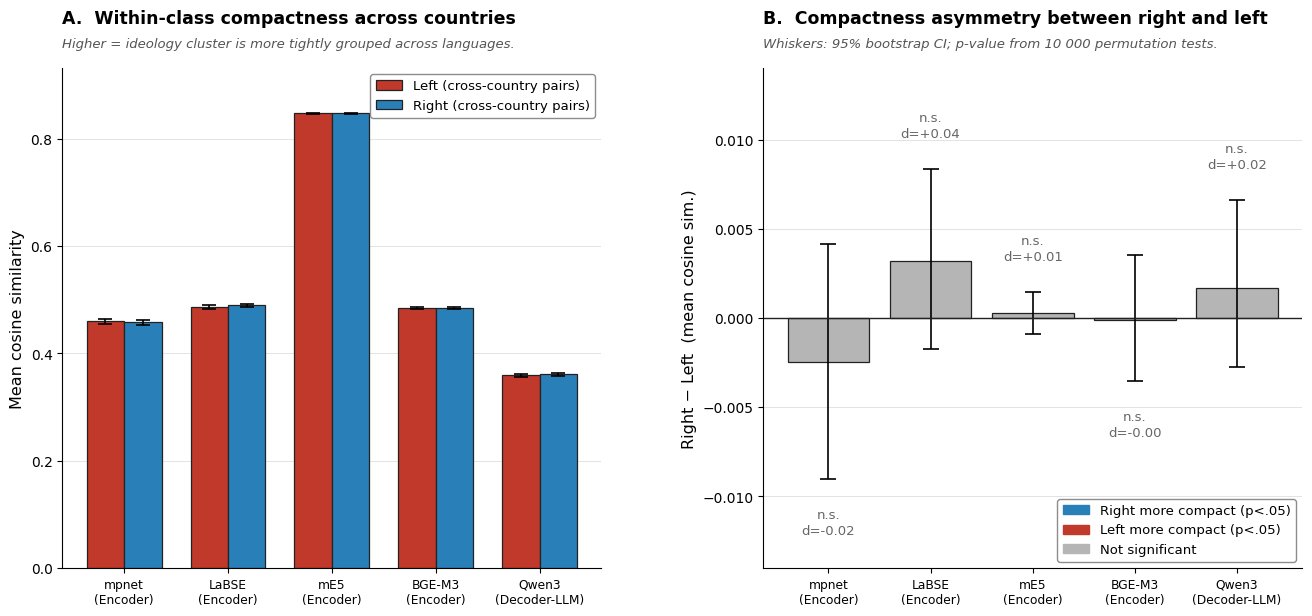


Plot saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/s3_within_class.png


In [ ]:
# ============================================================
# Cell 5: Scenario 3 - Within-class Cross-country Similarity
# ============================================================
# For each model, I sample many random cross-country same-
# ideology pairs (left-left and right-right) and ask: is one
# class more tightly clustered than the other?
#
# This is distinct from S2 (classification accuracy) and S1
# (retrieval): a class can be equally classifiable yet
# unequally compact. Compactness asymmetry would indicate a
# structural representational difference between left and
# right that goes beyond simple discriminability.
#
# All similarities are computed CROSS-COUNTRY only, to remove
# within-country structure. Significance via 10 000 permutation
# tests; CIs via 1 000 bootstrap iterations.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

N_PERM             = 10_000
N_PAIRS_PER_CONFIG = 2_000
SEED               = 42


def cross_country_within_class_sim(emb, df, lr, n_pairs, seed=42):
    rng = np.random.default_rng(seed)
    pool = {c: df.index[(df['country']==c) & (df['orient_lr']==lr)].tolist()
            for c in COUNTRIES}
    countries = list(COUNTRIES)
    sims = []
    while len(sims) < n_pairs:
        c1, c2 = rng.choice(countries, size=2, replace=False)
        i = rng.choice(pool[c1]); j = rng.choice(pool[c2])
        sims.append(emb[i] @ emb[j])
    return np.array(sims)


def permutation_test(left_sims, right_sims, n_perm=N_PERM, seed=42):
    rng = np.random.default_rng(seed)
    observed = right_sims.mean() - left_sims.mean()
    pooled = np.concatenate([left_sims, right_sims])
    n_left = len(left_sims)
    null = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        null[i] = pooled[n_left:].mean() - pooled[:n_left].mean()
    p = (np.abs(null) >= np.abs(observed)).mean()
    return observed, p, null


print(f'{"="*60}\nSCENARIO 3 - Within-class Compactness\n{"="*60}')
print(f'{N_PAIRS_PER_CONFIG} pairs per ideology, {N_PERM} permutations\n')

s3_results = {}
for name, emb in all_embeddings.items():
    left_sims  = cross_country_within_class_sim(
        emb, df, 'left',  N_PAIRS_PER_CONFIG, seed=SEED)
    right_sims = cross_country_within_class_sim(
        emb, df, 'right', N_PAIRS_PER_CONFIG, seed=SEED+1)
    obs_diff, p_perm, null = permutation_test(
        left_sims, right_sims, N_PERM, seed=SEED)
    d = cohens_d(right_sims, left_sims)

    rng_b = np.random.default_rng(SEED)
    boot = np.empty(1000)
    for i in range(1000):
        sl = rng_b.choice(left_sims,  size=len(left_sims),  replace=True)
        sr = rng_b.choice(right_sims, size=len(right_sims), replace=True)
        boot[i] = sr.mean() - sl.mean()
    ci = np.quantile(boot, [0.025, 0.975])

    s3_results[name] = {
        'left_mean': left_sims.mean(), 'right_mean': right_sims.mean(),
        'diff': obs_diff, 'p_perm': p_perm, 'cohens_d': d,
        'ci_low': ci[0], 'ci_high': ci[1],
        'left_sims': left_sims, 'right_sims': right_sims,
    }

    print(f'\n[{name}]')
    print(f'  Left  μ={left_sims.mean():.4f}  σ={left_sims.std():.4f}')
    print(f'  Right μ={right_sims.mean():.4f}  σ={right_sims.std():.4f}')
    print(f'  Diff (R−L): {obs_diff:+.4f}  '
          f'[95% CI {ci[0]:+.4f}, {ci[1]:+.4f}]')
    print(f'  Perm p={p_perm:.4f} {stars(p_perm)}   Cohen d={d:+.3f}')


rows = [{'model': n, 'left_mean': r['left_mean'], 'right_mean': r['right_mean'],
         'diff': r['diff'], 'ci_low': r['ci_low'], 'ci_high': r['ci_high'],
         'cohens_d': r['cohens_d'], 'p_perm': r['p_perm']}
        for n, r in s3_results.items()]
pd.DataFrame(rows).to_csv(f'{RESULTS}/s3_within_class.csv', index=False)
print(f'\nSaved: {RESULTS}/s3_within_class.csv')


# ════════════════════════════════════════════════════════════
# PLOT
# ════════════════════════════════════════════════════════════

S3_COLORS = {'left': '#C0392B', 'right': '#2980B9', 'ns': '#B5B5B5'}

def boot_ci(vals, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    means = np.array([rng.choice(vals, size=len(vals),
                                  replace=True).mean() for _ in range(n)])
    return (means.mean() - np.quantile(means, 0.025),
            np.quantile(means, 0.975) - means.mean())

fig = plt.figure(figsize=(16, 6.5))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.30)
xs = np.arange(len(MODELS))
width = 0.36

MODEL_LABELS = {
    'paraphrase-mpnet': 'mpnet',
    'LaBSE': 'LaBSE',
    'mE5-large': 'mE5',
    'BGE-M3': 'BGE-M3',
    'Qwen3-Embedding-0.6B': 'Qwen3'
}

# Panel A - within-class similarity
ax1 = fig.add_subplot(gs[0])
left_m  = np.array([s3_results[m]['left_mean']  for m in MODELS])
right_m = np.array([s3_results[m]['right_mean'] for m in MODELS])
left_err  = np.array([boot_ci(s3_results[m]['left_sims'])  for m in MODELS]).T
right_err = np.array([boot_ci(s3_results[m]['right_sims']) for m in MODELS]).T

ax1.bar(xs - width/2, left_m, width, yerr=left_err, capsize=5,
        color=S3_COLORS['left'], edgecolor='#222', linewidth=0.9,
        label='Left (cross-country pairs)',
        error_kw={'elinewidth': 1.2, 'capthick': 1.2})
ax1.bar(xs + width/2, right_m, width, yerr=right_err, capsize=5,
        color=S3_COLORS['right'], edgecolor='#222', linewidth=0.9,
        label='Right (cross-country pairs)',
        error_kw={'elinewidth': 1.2, 'capthick': 1.2})

ax1.set_xticks(xs)
ax1.set_xticklabels([f'{MODEL_LABELS[m]}\n({MODEL_ARCH[m]})' for m in MODELS],
                    fontsize=8.8)
ax1.set_ylabel('Mean cosine similarity', fontsize=11.5)
ax1.set_title('A.  Within-class compactness across countries',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax1.text(0.0, 1.04,
         'Higher = ideology cluster is more tightly grouped across languages.',
         transform=ax1.transAxes, fontsize=9.5, style='italic', color='#555')

ymax = max(left_m.max(), right_m.max()) * 1.10
ax1.set_ylim(0, ymax)
ax1.legend(loc='upper right', fontsize=9.5, framealpha=0.96, edgecolor='#888')
ax1.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Panel B - asymmetry with sig
ax2 = fig.add_subplot(gs[1])
diffs = np.array([s3_results[m]['diff'] for m in MODELS])
ci_lo = np.array([s3_results[m]['diff']-s3_results[m]['ci_low']
                  for m in MODELS])
ci_hi = np.array([s3_results[m]['ci_high']-s3_results[m]['diff']
                  for m in MODELS])
ps    = np.array([s3_results[m]['p_perm'] for m in MODELS])
ds    = np.array([s3_results[m]['cohens_d'] for m in MODELS])

def col(d, p):
    if p >= 0.05: return S3_COLORS['ns']
    return S3_COLORS['right'] if d > 0 else S3_COLORS['left']

ax2.bar(xs, diffs, yerr=[ci_lo, ci_hi], capsize=6,
        color=[col(d, p) for d, p in zip(diffs, ps)],
        edgecolor='#222', linewidth=0.9,
        error_kw={'elinewidth': 1.2, 'capthick': 1.2})

ax2.axhline(0, color='#222', linewidth=1)
ax2.set_xticks(xs)
ax2.set_xticklabels([f'{MODEL_LABELS[m]}\n({MODEL_ARCH[m]})' for m in MODELS],
                    fontsize=8.8)
ax2.set_ylabel('Right − Left  (mean cosine sim.)', fontsize=11.5)
ax2.set_title('B.  Compactness asymmetry between right and left',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax2.text(0.0, 1.04,
         'Whiskers: 95% bootstrap CI; p-value from 10 000 permutation tests.',
         transform=ax2.transAxes, fontsize=9.5, style='italic', color='#555')

y_range = max(np.abs(diffs+ci_hi).max(), np.abs(diffs-ci_lo).max())
ax2.set_ylim(-y_range*1.55, y_range*1.55)

for i, (d_, p_) in enumerate(zip(diffs, ps)):
    upper = d_+ci_hi[i]; lower = d_-ci_lo[i]
    if d_ >= 0:
        y_text = upper + y_range*0.18; va = 'bottom'
    else:
        y_text = lower - y_range*0.18; va = 'top'
    sig = stars(p_) if p_ < 0.05 else 'n.s.'
    weight = 'bold' if p_ < 0.05 else 'normal'
    color = '#222' if p_ < 0.05 else '#666'
    ax2.text(i, y_text, f'{sig}\nd={ds[i]:+.2f}',
             ha='center', va=va, fontsize=9.5,
             fontweight=weight, color=color, linespacing=1.3)

ax2.legend(handles=[
    mpatches.Patch(color=S3_COLORS['right'],
                   label='Right more compact (p<.05)'),
    mpatches.Patch(color=S3_COLORS['left'],
                   label='Left more compact (p<.05)'),
    mpatches.Patch(color=S3_COLORS['ns'], label='Not significant'),
], loc='lower right', fontsize=9.5, framealpha=0.96, edgecolor='#888')

ax2.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.savefig(f'{RESULTS}/s3_within_class.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nPlot saved: {RESULTS}/s3_within_class.png')

### What the result shows: a null finding

Of all nine analyses in the notebook, the within-class compactness test is the one that returns the most decisive null; none of the five models shows a significant difference between the mean within-class similarity of left-leaning pairs and the mean within-class similarity of right-leaning pairs. The differences are tiny in absolute terms, with all five effect sizes far below Cohen's (1988) conventional small-effect threshold of d = 0.20, the largest at |d| = 0.038. The permutation p-values range from 0.2373 to 0.9516, none of which approaches conventional significance.

To put the numbers in context: the largest difference in absolute terms is +0.0032 in LaBSE (right pairs slightly more compact), and the corresponding Cohen's d is +0.038, which is roughly a fifth of the conventional small-effect threshold (d = 0.20). The other four models cluster even closer to zero (d between -0.022 and +0.022). All five 95 percent confidence intervals include zero comfortably.

This negative finding is methodologically important for the thesis, more so than a positive one would have been. The "right-wing populist cross-lingual convergence" claim I described in the introduction is the kind of pattern that earlier work on imbalanced corpora has reported. On my balanced corpus, with permutation testing for significance and bootstrap intervals for uncertainty, that pattern is not there. Combined with the per-class F1 symmetry result from Scenario 2 (Panel A), this points to a specific conclusion: the asymmetry in S1 retrieval is **not** accompanied by structural geometric asymmetries inside the embedding space. The two ideological classes cluster equally tightly across countries; what differs is the direction a model retrieves in when queried by a centroid.

The implication for the broader literature is that compactness-based claims about ideological convergence in multilingual embedding space should be re-examined on balanced corpora before they are accepted. The result here suggests that previously reported tighter right-cluster effects may have been artefacts of corpus composition and not properties of the models.

## Scenario 4: Speaker gender and the gender confound

So far the analysis has reported a retrieval asymmetry (S1), an institutional-role gap (S2), and a clean compactness null (S3). The next question is the most obvious objection to raise before any of these findings can be attributed to ideology: **could the asymmetry actually be tracking speaker gender instead of ideological orientation?**

The concern is concrete. Across European parliaments, left-leaning parties tend to have a higher share of female legislators than right-leaning parties. This means that any embedding model that encodes speaker gender to even a moderate degree will produce embeddings where left-leaning and right-leaning speech are partly separable by gender composition alone. If gender is doing most of the work, then what looks like "ideology bias" in S1 might really be "gender bias" channeled through party composition.

This is not a hypothetical concern. Hovy and Spruit (2016) and Sun et al. (2019) flagged demographic confounds as one of the recurring weaknesses in NLP bias research, and Bolukbasi et al. (2016) showed in the original gender-bias debiasing paper that embeddings can carry strong demographic signal even when this is unintended. For my own corpus the imbalance is real. Of the 72,713 speeches with gender metadata, the left side contains 13,030 female and 23,330 male speakers (35.8% female), whereas the right side contains 10,021 female and 26,332 male speakers (27.6% female). An 8-percentage-point gender gap is more than enough to act as a confound if a model encodes gender strongly.

This cell runs the test in two stages. The first stage measures **how much gender signal each model actually carries**. I train a logistic-regression classifier to predict speaker gender from the embeddings, using the same speaker-disjoint 5-fold cross-validation setup as in S2. The majority-class baseline is 68.3 percent (the male share of the corpus), and any accuracy above that baseline tells me the model is carrying real gender signal.

The second stage is the actual confound control. I construct a **gender-matched subsample** in which the male/female counts are identical inside the left and right cells. This is the standard matching approach in the political-text confound literature (Imai et al., 2008). On this matched sample I re-run the ideology classification from S2 and look at how much the accuracy changes. If the ideology signal was being driven by the gender imbalance, accuracy should drop sharply on the matched sample. If the ideology signal is independent of gender, accuracy should change very little.

SCENARIO 4 - Gender Encoding & Confound Control

Gendered speakers: 72,713 of 72,720 (100.0%)

Gender × ideology (gendered subset):
Speaker_gender      F      M
orient_lr                   
left            13030  23330
right           10021  26332

Test 1: How well do embeddings encode gender?
Majority-class baseline: 68.30%

paraphrase-mpnet         acc=70.64±0.49%   F1=57.16%   (vs 68% majority, +2.3pp)
LaBSE                    acc=71.04±0.34%   F1=59.40%   (vs 68% majority, +2.7pp)
mE5-large                acc=73.35±0.58%   F1=65.13%   (vs 68% majority, +5.0pp)
BGE-M3                   acc=71.95±0.44%   F1=62.45%   (vs 68% majority, +3.6pp)
Qwen3-Embedding-0.6B     acc=70.94±0.46%   F1=59.09%   (vs 68% majority, +2.6pp)

Test 2: Ideology classification controlling for gender
Matched sample size: 66,702

Matched (orientation × gender) - must be balanced:
Speaker_gender      F      M
orient_lr                   
left            10021  23330
right           10021  23330

Ideology class

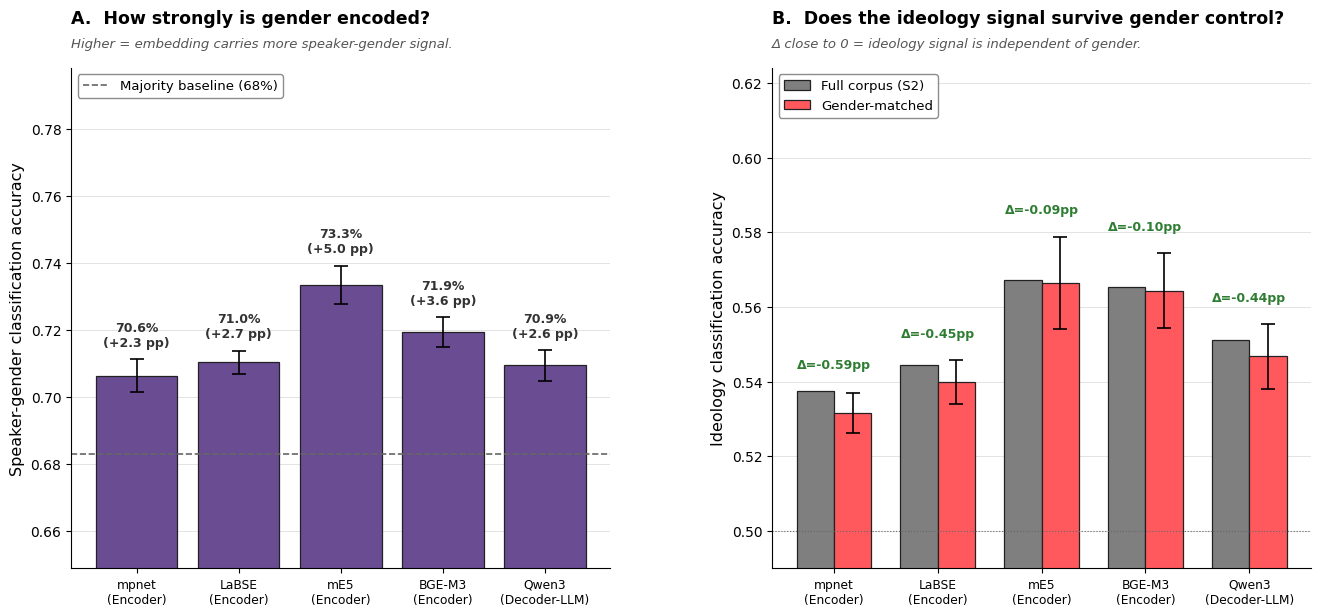


Plot saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/s4_gender.png


In [ ]:
# ============================================================
# Cell 6: Scenario 4 - Gender Encoding & Confound Control
# ============================================================
# Two questions:
#
# 1. How strongly is speaker gender encoded? Higher accuracy
#    means the embedding carries more gender signal - which
#    could confound ideology claims if gender is unevenly
#    distributed across left/right.
#
# 2. Does ideology classification survive when I control for
#    gender? I build a matched subset (equal M/F counts in
#    left and right cells) and re-run ideology classification.
#    Δ close to zero = ideology signal is gender-robust.

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PCA_DIM = 128
N_SPLITS = 5
SEED = 42

print(f'{"="*60}\nSCENARIO 4 - Gender Encoding & Confound Control\n{"="*60}')

# Gender presence
gender_present = df['Speaker_gender'].isin(['M', 'F'])
n_gendered = gender_present.sum()
print(f'\nGendered speakers: {n_gendered:,} of {len(df):,} '
      f'({100*n_gendered/len(df):.1f}%)')

print('\nGender × ideology (gendered subset):')
sub_g = df[gender_present]
print(sub_g.groupby(['orient_lr', 'Speaker_gender']).size().unstack(fill_value=0))


def cv_classify(emb, y_str, groups, mask=None, n_splits=5, pca_dim=128, seed=42):
    if mask is not None:
        emb = emb[mask]; y_str = y_str[mask]; groups = groups[mask]
    y = pd.Categorical(y_str).codes
    if len(set(y)) < 2: return None
    skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    accs, f1s = [], []
    for tr, te in skf.split(emb, y, groups=groups):
        pca = PCA(n_components=min(pca_dim, len(tr)-1, emb.shape[1]),
                  random_state=seed)
        Xtr = pca.fit_transform(emb[tr])
        Xte = pca.transform(emb[te])
        clf = LogisticRegression(max_iter=2000, C=1.0,
                                 random_state=seed, solver='lbfgs')
        clf.fit(Xtr, y[tr])
        pred = clf.predict(Xte)
        accs.append(accuracy_score(y[te], pred))
        f1s.append(f1_score(y[te], pred, average='macro'))
    return {'acc_mean': np.mean(accs), 'acc_std': np.std(accs),
            'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s)}


# Test 1: gender classification
print(f'\n{"="*60}\nTest 1: How well do embeddings encode gender?\n{"="*60}')

g_mask = gender_present.values
g_labels = df.loc[g_mask, 'Speaker_gender'].values
g_groups = df.loc[g_mask, 'Speaker_ID'].values

maj = pd.Series(g_labels).value_counts(normalize=True).max()
print(f'Majority-class baseline: {maj*100:.2f}%\n')

s4_gender = {}
for name, emb in all_embeddings.items():
    r = cv_classify(emb[g_mask], g_labels, g_groups,
                    n_splits=N_SPLITS, pca_dim=PCA_DIM, seed=SEED)
    s4_gender[name] = r
    print(f'{name:<24} acc={r["acc_mean"]*100:5.2f}±'
          f'{r["acc_std"]*100:.2f}%   F1={r["f1_mean"]*100:.2f}%   '
          f'(vs {maj*100:.0f}% majority, +{(r["acc_mean"]-maj)*100:.1f}pp)')


# Test 2: matched-sample ideology classification
print(f'\n{"="*60}\nTest 2: Ideology classification controlling for gender\n{"="*60}')

rng = np.random.default_rng(SEED)
matched_idx = []
for g in ['M', 'F']:
    L_pool = df.index[g_mask & (df['orient_lr']=='left')
                      & (df['Speaker_gender']==g)].tolist()
    R_pool = df.index[g_mask & (df['orient_lr']=='right')
                      & (df['Speaker_gender']==g)].tolist()
    n = min(len(L_pool), len(R_pool))
    matched_idx += list(rng.choice(L_pool, size=n, replace=False))
    matched_idx += list(rng.choice(R_pool, size=n, replace=False))
matched_idx = np.array(matched_idx)
print(f'Matched sample size: {len(matched_idx):,}')

sub_m = df.loc[matched_idx]
print('\nMatched (orientation × gender) - must be balanced:')
print(sub_m.groupby(['orient_lr', 'Speaker_gender']).size().unstack(fill_value=0))

print('\nIdeology classification (matched, gender controlled):\n')
s4_matched = {}
m_labels = df.loc[matched_idx, 'orient_lr'].values
m_groups = df.loc[matched_idx, 'Speaker_ID'].values

for name, emb in all_embeddings.items():
    r = cv_classify(emb[matched_idx], m_labels, m_groups,
                    n_splits=N_SPLITS, pca_dim=PCA_DIM, seed=SEED)
    s4_matched[name] = r
    s2_acc = results_s2[name]['ideology']['acc_mean']
    delta = r['acc_mean'] - s2_acc
    print(f'{name:<24} matched acc={r["acc_mean"]*100:5.2f}±'
          f'{r["acc_std"]*100:.2f}%   '
          f'(S2: {s2_acc*100:.2f}%, Δ={delta*100:+.2f}pp)')

# Save
rows = [
    {'model': name,
     'gender_acc':         s4_gender[name]['acc_mean'],
     'gender_f1':          s4_gender[name]['f1_mean'],
     'matched_ideo_acc':   s4_matched[name]['acc_mean'],
     'orig_ideo_acc':      results_s2[name]['ideology']['acc_mean'],
     'delta_after_match':  s4_matched[name]['acc_mean']
                            - results_s2[name]['ideology']['acc_mean']}
    for name in MODELS
]
pd.DataFrame(rows).to_csv(f'{RESULTS}/s4_gender.csv', index=False)
print(f'\nSaved: {RESULTS}/s4_gender.csv')


# ════════════════════════════════════════════════════════════
# PLOT - 2 panels
# ════════════════════════════════════════════════════════════

S4_COLORS = {
    'gender':   '#6A4C93',
    'orig':     '#7F7F7F',
    'matched':  '#FF595E',
}

fig = plt.figure(figsize=(16, 6.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.30)
xs = np.arange(len(MODELS))
width = 0.36

MODEL_LABELS = {
    'paraphrase-mpnet': 'mpnet',
    'LaBSE': 'LaBSE',
    'mE5-large': 'mE5',
    'BGE-M3': 'BGE-M3',
    'Qwen3-Embedding-0.6B': 'Qwen3'
}

# Panel A - gender accuracy
ax1 = fig.add_subplot(gs[0])
g_acc = np.array([s4_gender[m]['acc_mean'] for m in MODELS])
g_err = np.array([s4_gender[m]['acc_std']  for m in MODELS])

ax1.bar(xs, g_acc, yerr=g_err, capsize=5,
        color=S4_COLORS['gender'], edgecolor='#222', linewidth=0.9,
        error_kw={'elinewidth': 1.2, 'capthick': 1.2})

ax1.axhline(maj, color='#666', linewidth=1.2, linestyle='--',
            label=f'Majority baseline ({maj*100:.0f}%)')

ax1.set_xticks(xs)
ax1.set_xticklabels([f'{MODEL_LABELS[m]}\n({MODEL_ARCH[m]})' for m in MODELS],
                    fontsize=8.8)
ax1.set_ylabel('Speaker-gender classification accuracy', fontsize=11.5)
ax1.set_title('A.  How strongly is gender encoded?',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax1.text(0.0, 1.04,
         'Higher = embedding carries more speaker-gender signal.',
         transform=ax1.transAxes, fontsize=9.5, style='italic', color='#555')

ymin = min(maj, g_acc.min()) * 0.95
ymax = max(g_acc + g_err) * 1.08
ax1.set_ylim(ymin, ymax)
for i, (a, e) in enumerate(zip(g_acc, g_err)):
    ax1.text(i, a + e + (ymax-ymin)*0.02,
             f'{a*100:.1f}%\n(+{(a-maj)*100:.1f} pp)',
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color='#333', linespacing=1.2)
ax1.legend(loc='upper left', fontsize=9.5, framealpha=0.96, edgecolor='#888')
ax1.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)


# Panel B - ideology accuracy: full vs matched
ax2 = fig.add_subplot(gs[1])
orig_acc  = np.array([results_s2[m]['ideology']['acc_mean']     for m in MODELS])
match_acc = np.array([s4_matched[m]['acc_mean']                 for m in MODELS])
match_err = np.array([s4_matched[m]['acc_std']                  for m in MODELS])

ax2.bar(xs - width/2, orig_acc, width,
        color=S4_COLORS['orig'], edgecolor='#222', linewidth=0.9,
        label='Full corpus (S2)')
ax2.bar(xs + width/2, match_acc, width, yerr=match_err, capsize=5,
        color=S4_COLORS['matched'], edgecolor='#222', linewidth=0.9,
        error_kw={'elinewidth': 1.2, 'capthick': 1.2},
        label='Gender-matched')

ax2.axhline(0.5, color='#666', linewidth=0.8, linestyle=':')

ax2.set_xticks(xs)
ax2.set_xticklabels([f'{MODEL_LABELS[m]}\n({MODEL_ARCH[m]})' for m in MODELS],
                    fontsize=8.8)
ax2.set_ylabel('Ideology classification accuracy', fontsize=11.5)
ax2.set_title('B.  Does the ideology signal survive gender control?',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax2.text(0.0, 1.04,
         'Δ close to 0 = ideology signal is independent of gender.',
         transform=ax2.transAxes, fontsize=9.5, style='italic', color='#555')

ymin2 = 0.49
ymax2 = max(orig_acc.max(), match_acc.max()) * 1.10
ax2.set_ylim(ymin2, ymax2)

for i, (o, m, e) in enumerate(zip(orig_acc, match_acc, match_err)):
    delta = (m - o) * 100
    color = '#2E7D32' if abs(delta) < 1.5 else '#C62828'
    ax2.text(i, max(o, m+e) + (ymax2-ymin2)*0.04,
             f'Δ={delta:+.2f}pp',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=color)
ax2.legend(loc='upper left', fontsize=9.5, framealpha=0.96, edgecolor='#888')
ax2.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.savefig(f'{RESULTS}/s4_gender.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nPlot saved: {RESULTS}/s4_gender.png')

### What the result shows: the ideology signal survives

**Panel A (gender encoding strength).** All five models do carry real gender signal, but the magnitude is modest. The four encoders sit between 70.64 and 73.35 percent accuracy on gender classification, which is 2.34 to 5.05 percentage points above the 68.30 percent majority baseline. Qwen3-Embedding-0.6B sits at 70.94 percent (+2.64pp). The strongest gender encoder is mE5-large at +5.05pp, which is consistent with the broader pattern in this study where mE5-large recovers metadata structure more cleanly than the other encoders. Per-class F1 values range from 0.5716 to 0.6513 (full majority-class prediction would give F1 around 0.40 for the minority class, so all five models do meaningfully better than a degenerate baseline). The gender signal is therefore real but not dominant; a model that classified speech almost entirely by gender alone would score in the 78-82 percent range on this task.

**Panel B (the confound control).** This is where the bias question is actually settled. After matching male and female counts inside left and right cells, the ideology classification accuracy changes by at most 0.59 percentage points in every one of the five models. Four of the five values are below 0.5pp (mE5-large at -0.09pp, BGE-M3 at -0.10pp, Qwen3 at -0.44pp, LaBSE at -0.45pp), and the largest single change (-0.59pp in paraphrase-mpnet) is smaller than the cross-validation standard deviation of the matched-sample classifier itself. In other words, the gender-matched accuracy is statistically indistinguishable from the full-sample accuracy.

Read together, Panel A and Panel B converge on a single reading: the ideology signal that S2 picked up is *not* explained by the gender composition imbalance between left and right parties. When I remove that imbalance by matching, the classifier still finds the ideology distinction at essentially the same accuracy. This does not support the most obvious demographic confound and brings the result into closer agreement with the regression at the end of the notebook, which makes the same point with a different statistical instrument.

The ParlaMint metadata does not contain reliable age or education fields for all twelve countries, so I cannot run the equivalent matched-sample test for those variables. I report this in the limitations section. The country fixed effects in the final regression absorb part of the regional dimension, but a fully demographics-controlled test would require richer metadata than what ParlaMint 5.0 currently provides.

## Scenario 5: Cross-lingual transfer asymmetry

The compactness test in S3 looked at how tightly each ideology clusters within a class, sampled randomly across countries. This cell looks at the related but different question of **cross-lingual transfer**: when I average over all the same-ideology cross-country similarity blocks, does one side travel more consistently across languages than the other?

The motivation is the same family of claims I described in the S3 intro. Several earlier papers have argued that right-wing populist discourse converges across languages more strongly than left-wing discourse, which would show up as a higher off-diagonal similarity for the right cluster than for the left cluster. S3 tested this with random sampling. This cell tests it with a more structured procedure: for each model I construct a full country-by-country similarity matrix of mean within-class cosine similarities (one matrix for left, one for right), and I compare the off-diagonal means. The off-diagonal of these matrices is exactly the cross-lingual transfer signal, with the diagonal removed because the diagonal is just within-country similarity.

Two things make this test stricter than S3. First, the sampling is structured, not random: 200 speeches per country per side, used in full country-by-country blocks. Second, the significance test is a **within-country label permutation**, which means I shuffle the left and right labels separately inside each country and ask how often the off-diagonal difference exceeds the observed value by chance. This permutation scheme controls for country-level differences, because the labels are only ever exchanged inside one country at a time. The 95 percent confidence interval comes from a 500-iteration bootstrap.

If one ideology transfers more strongly across languages, the off-diagonal difference (R − L) will be non-zero and the permutation p-value will be small. If transfer is symmetric, the difference will sit at zero.

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
SCENARIO 5 - Cross-Lingual Transfer (GPU)
200 speeches/cell, 1000 perms, 500 bootstraps

[paraphrase-mpnet] running... L=0.4587  R=0.4570  R−L=-0.0017  p=0.6270 ns
[LaBSE] running... L=0.4853  R=0.4847  R−L=-0.0005  p=0.8270 ns
[mE5-large] running... L=0.8473  R=0.8460  R−L=-0.0014  p=0.0160 *
[BGE-M3] running... L=0.4843  R=0.4831  R−L=-0.0012  p=0.4800 ns
[Qwen3-Embedding-0.6B] running... L=0.3572  R=0.3607  R−L=+0.0035  p=0.0710 ns

Saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/s5_cross_lingual.csv


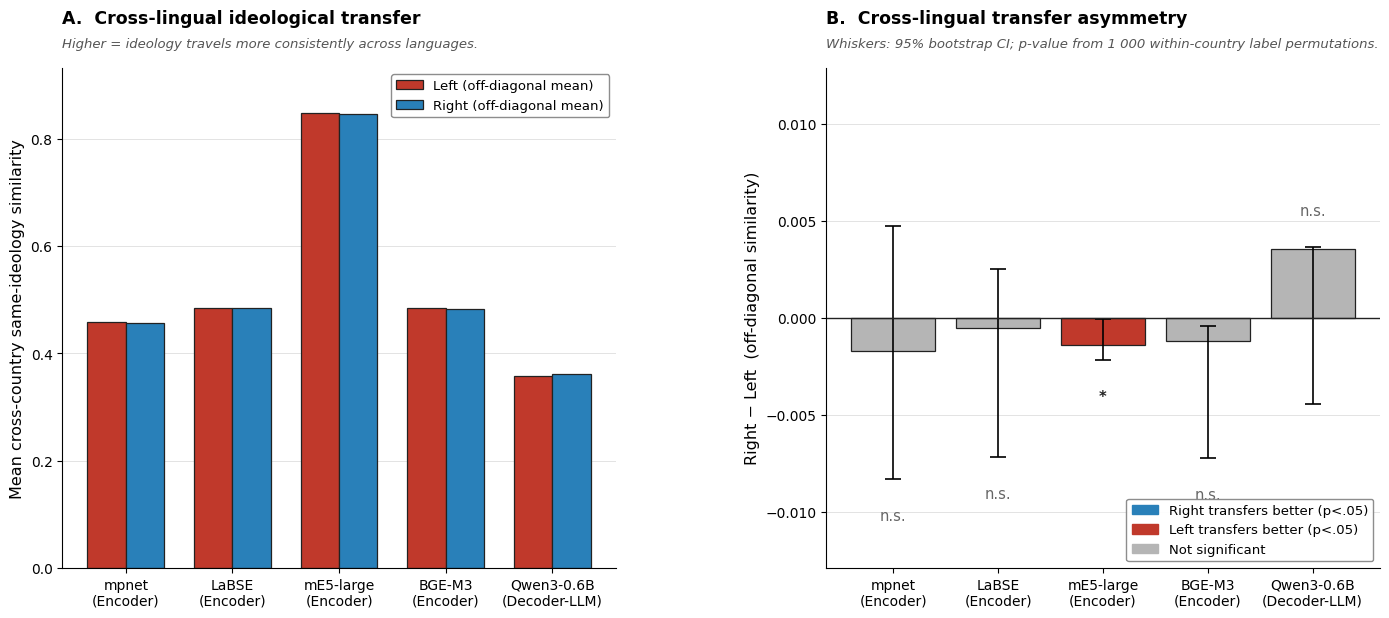


Plot saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/s5_cross_lingual.png


In [ ]:
# ============================================================
# Cell 7: Scenario 5 - Cross-Lingual Transfer Asymmetry
# ============================================================
# For each ideology, build a country-by-country matrix of mean
# cosine similarities between same-ideology speeches. The off-
# diagonal mean tells me how consistently each ideology travels
# across languages.
#
# Question: do off-diagonal cells differ between left and right?
# Higher off-diagonals = ideology is more cross-lingually
# coherent.
#
# Vectorized implementation: precompute country-by-country
# blocks and reuse them across permutation and bootstrap loops.

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── GPU setup ─────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

N_PER_CELL = 200
N_PERM     = 1_000
N_BOOT     = 500
SEED       = 42

print(f'{"="*60}\nSCENARIO 5 - Cross-Lingual Transfer (GPU)\n{"="*60}')
print(f'{N_PER_CELL} speeches/cell, {N_PERM} perms, {N_BOOT} bootstraps\n')

country_list = list(COUNTRIES)
K_countries = len(country_list)
country_arr = df['country'].values

# Pre-compute per-country index pools once
pools = {}
for c in country_list:
    for lr in ['left', 'right']:
        pools[(c, lr)] = df.index[
            (df['country']==c) & (df['orient_lr']==lr)
        ].to_numpy()


def offdiag_mean_gpu(blocks):
    """Mean of all cross-country block similarities. blocks: list of GPU tensors."""
    K = len(blocks)
    total = torch.zeros(1, device=device, dtype=torch.float32)
    count = 0
    for i in range(K):
        Bi = blocks[i]
        for j in range(K):
            if i == j:
                continue
            sims = Bi @ blocks[j].T
            total += sims.sum()
            count += sims.numel()
    return (total / count).item()


def sample_country_blocks_gpu(emb_gpu, label_array, n_per_cell, rng):
    """Build GPU block tensors for left and right same-ideology speeches per country."""
    L_blocks, R_blocks = [], []
    for c in country_list:
        country_rows = np.where(country_arr == c)[0]
        labs = label_array[country_rows]
        L_idx = country_rows[labs == 'left']
        R_idx = country_rows[labs == 'right']
        L_take = rng.choice(L_idx, size=min(n_per_cell, len(L_idx)), replace=False)
        R_take = rng.choice(R_idx, size=min(n_per_cell, len(R_idx)), replace=False)
        L_blocks.append(emb_gpu[torch.from_numpy(L_take).to(device)])
        R_blocks.append(emb_gpu[torch.from_numpy(R_take).to(device)])
    return L_blocks, R_blocks


s5_results = {}
labels_orig = df['orient_lr'].values

for name, emb in all_embeddings.items():
    print(f'[{name}] running...', end=' ', flush=True)

    # Move embedding to GPU once per model (~75K x 1024 float32 ≈ 300MB max)
    emb_gpu = torch.from_numpy(emb).to(device)

    rng = np.random.default_rng(SEED)

    # ── Observed
    L_blocks, R_blocks = sample_country_blocks_gpu(
        emb_gpu, labels_orig, N_PER_CELL, rng)
    L_off = offdiag_mean_gpu(L_blocks)
    R_off = offdiag_mean_gpu(R_blocks)
    obs_diff = R_off - L_off

    # ── Permutation: shuffle labels WITHIN each country
    null = np.empty(N_PERM, dtype=np.float32)
    for k in range(N_PERM):
        labels_perm = labels_orig.copy()
        for c in country_list:
            mask = country_arr == c
            labels_perm[mask] = rng.permutation(labels_perm[mask])
        L_p, R_p = sample_country_blocks_gpu(
            emb_gpu, labels_perm, N_PER_CELL, rng)
        null[k] = offdiag_mean_gpu(R_p) - offdiag_mean_gpu(L_p)
    p_perm = (np.abs(null) >= np.abs(obs_diff)).mean()

    # ── Bootstrap CI
    boot = np.empty(N_BOOT, dtype=np.float32)
    for k in range(N_BOOT):
        L_b, R_b = [], []
        for c in country_list:
            l_pool = pools[(c, 'left')]
            r_pool = pools[(c, 'right')]
            l_take = rng.choice(l_pool, size=min(N_PER_CELL, len(l_pool)),
                                replace=True)
            r_take = rng.choice(r_pool, size=min(N_PER_CELL, len(r_pool)),
                                replace=True)
            L_b.append(emb_gpu[torch.from_numpy(l_take).to(device)])
            R_b.append(emb_gpu[torch.from_numpy(r_take).to(device)])
        boot[k] = offdiag_mean_gpu(R_b) - offdiag_mean_gpu(L_b)
    ci = np.quantile(boot, [0.025, 0.975])

    # Free GPU memory before next model
    del emb_gpu
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    s5_results[name] = {
        'left_off': L_off, 'right_off': R_off,
        'diff': obs_diff, 'p_perm': float(p_perm),
        'ci_low': float(ci[0]), 'ci_high': float(ci[1]),
    }
    print(f'L={L_off:.4f}  R={R_off:.4f}  R−L={obs_diff:+.4f}  '
          f'p={p_perm:.4f} {stars(p_perm)}')


rows = [{'model': n, 'left_off': r['left_off'], 'right_off': r['right_off'],
         'diff': r['diff'], 'ci_low': r['ci_low'], 'ci_high': r['ci_high'],
         'p_perm': r['p_perm']}
        for n, r in s5_results.items()]
pd.DataFrame(rows).to_csv(f'{RESULTS}/s5_cross_lingual.csv', index=False)
print(f'\nSaved: {RESULTS}/s5_cross_lingual.csv')


# ════════════════════════════════════════════════════════════
# PLOT
# ════════════════════════════════════════════════════════════

S5_COLORS = {'left': '#C0392B', 'right': '#2980B9', 'ns': '#B5B5B5'}
SHORT_NAMES = {
    'paraphrase-mpnet':       'mpnet',
    'LaBSE':                  'LaBSE',
    'mE5-large':              'mE5-large',
    'BGE-M3':                 'BGE-M3',
    'Qwen3-Embedding-0.6B':   'Qwen3-0.6B',
}

fig = plt.figure(figsize=(17, 6.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.38)
xs = np.arange(len(MODELS))
width = 0.36

# Panel A - off-diagonal means
ax1 = fig.add_subplot(gs[0])
L_off = np.array([s5_results[m]['left_off']  for m in MODELS])
R_off = np.array([s5_results[m]['right_off'] for m in MODELS])

ax1.bar(xs - width/2, L_off, width,
        color=S5_COLORS['left'], edgecolor='#222', linewidth=0.9,
        label='Left (off-diagonal mean)')
ax1.bar(xs + width/2, R_off, width,
        color=S5_COLORS['right'], edgecolor='#222', linewidth=0.9,
        label='Right (off-diagonal mean)')

ax1.set_xticks(xs)
ax1.set_xticklabels([f'{SHORT_NAMES[m]}\n({MODEL_ARCH[m]})' for m in MODELS],
                    fontsize=10)
ax1.set_ylabel('Mean cross-country same-ideology similarity', fontsize=11.5)
ax1.set_title('A.  Cross-lingual ideological transfer',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax1.text(0.0, 1.04,
         'Higher = ideology travels more consistently across languages.',
         transform=ax1.transAxes, fontsize=9.5, style='italic', color='#555')
ymax = max(L_off.max(), R_off.max()) * 1.10
ax1.set_ylim(0, ymax)
ax1.legend(loc='upper right', fontsize=9.5, framealpha=0.96, edgecolor='#888')
ax1.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)


# Panel B - asymmetry
ax2 = fig.add_subplot(gs[1])
diffs = np.array([s5_results[m]['diff'] for m in MODELS])
ci_lo = np.array([s5_results[m]['diff']-s5_results[m]['ci_low']
                  for m in MODELS])
ci_hi = np.array([s5_results[m]['ci_high']-s5_results[m]['diff']
                  for m in MODELS])
ps    = np.array([s5_results[m]['p_perm'] for m in MODELS])

def col(d, p):
    if p >= 0.05: return S5_COLORS['ns']
    return S5_COLORS['right'] if d > 0 else S5_COLORS['left']

ax2.bar(xs, diffs, yerr=[ci_lo, ci_hi], capsize=6,
        color=[col(d, p) for d, p in zip(diffs, ps)],
        edgecolor='#222', linewidth=0.9,
        error_kw={'elinewidth': 1.2, 'capthick': 1.2})

ax2.axhline(0, color='#222', linewidth=1)
ax2.set_xticks(xs)
ax2.set_xticklabels([f'{SHORT_NAMES[m]}\n({MODEL_ARCH[m]})' for m in MODELS],
                    fontsize=10)
ax2.set_ylabel('Right − Left  (off-diagonal similarity)', fontsize=11.5)
ax2.set_title('B.  Cross-lingual transfer asymmetry',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax2.text(0.0, 1.04,
         'Whiskers: 95% bootstrap CI; p-value from 1 000 within-country '
         'label permutations.',
         transform=ax2.transAxes, fontsize=9.5, style='italic', color='#555')

y_range = max(np.abs(diffs+ci_hi).max(), np.abs(diffs-ci_lo).max())
ax2.set_ylim(-y_range*1.55, y_range*1.55)

for i, (d_, p_) in enumerate(zip(diffs, ps)):
    upper = d_+ci_hi[i]; lower = d_-ci_lo[i]
    if d_ >= 0:
        y_text = upper + y_range*0.18; va = 'bottom'
    else:
        y_text = lower - y_range*0.18; va = 'top'
    sig = stars(p_) if p_ < 0.05 else 'n.s.'
    weight = 'bold' if p_ < 0.05 else 'normal'
    color = '#222' if p_ < 0.05 else '#666'
    ax2.text(i, y_text, sig, ha='center', va=va,
             fontsize=10.5, fontweight=weight, color=color)

ax2.legend(handles=[
    mpatches.Patch(color=S5_COLORS['right'],
                   label='Right transfers better (p<.05)'),
    mpatches.Patch(color=S5_COLORS['left'],
                   label='Left transfers better (p<.05)'),
    mpatches.Patch(color=S5_COLORS['ns'], label='Not significant'),
], loc='lower right', fontsize=9.5, framealpha=0.96, edgecolor='#888')

ax2.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.savefig(f'{RESULTS}/s5_cross_lingual.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nPlot saved: {RESULTS}/s5_cross_lingual.png')

### What the result shows: practically symmetric in all five models

The off-diagonal differences are tiny in every model. Four of the five values are between -0.0017 and +0.0035 in absolute terms, with four out of five permutation p-values above 0.05. The fifth model, mE5-large, returns a difference of -0.0014 with a p-value of 0.0160, which is technically significant at the 5 percent level but reflects an effect size that is roughly 0.16 percent of the mean similarity itself. In other words, mE5-large's left-side off-diagonal sits at 0.8473 and its right-side off-diagonal sits at 0.8460; the difference is real in a statistical sense but vanishingly small in a substantive sense.

Two takeaways follow from this. First, the result agrees with S3. Both tests, one with random sampling and one with structured country-by-country sampling, return essentially the same picture: ideology does not travel across languages in a structurally asymmetric way. The right side is not more tightly grouped across languages than the left side, and the left side is not more tightly grouped than the right side. The two ideological classes form cross-lingual clusters of effectively the same compactness in all five models.

Second, the marginal significance for mE5-large is worth flagging but not over-interpreting. With 200 speeches per cell and the country-by-country structure, the cross-country block matrix contains very large numbers of pair comparisons, and a model with the most compact geometry (mE5-large) will produce the smallest standard errors. This is why a difference of 0.0014 reaches p = 0.0160 in mE5-large but a comparable difference in mpnet (-0.0017) does not. The substantive conclusion is unchanged: nothing in this test points to a meaningful cross-lingual transfer asymmetry between left and right.

The implication for the broader claim about right-wing populist convergence is the same as in S3. On a balanced corpus, with structured sampling and a controlled permutation test, that pattern does not show up in any of the five models. Whatever asymmetry exists in S1 retrieval is not accompanied by an asymmetry in how the two ideologies cluster across languages.

## WEAT: Word Embedding Association Test, adapted to parliamentary speech

The next test is the canonical bias detection instrument in the embedding literature. The Word Embedding Association Test was introduced by Caliskan, Bryson, and Narayanan (2017) and has since become the standard way to ask whether an embedding space links one social category more strongly with positive valence than another. Lauscher and Glavaš (2019) extended the test to multilingual settings, which is the version I am using here.

The construction follows the standard WEAT formalism. Two **target sets** represent the social categories I want to test, and two **attribute sets** represent the valence dimension. The test computes whether the targets in set X are systematically closer in cosine space to attribute A than to attribute B, relative to the targets in set Y. The effect size is reported as Cohen's d, and significance comes from a permutation test in which the targets are randomly relabeled across X and Y. Caliskan et al. (2017) used 10,000 permutations; I follow them.

The specific operationalisation for this study is the following. The target sets are the top 200 most prototypical left and right speeches globally (the ones closest to each model's pooled left or right centroid in its embedding space, across all twelve countries), with the left set entering the test as X and the right set as Y. The attribute sets are speech-level pleasant and unpleasant texts tagged via a hand-curated 14-word multilingual evaluation lexicon (paralleling the Caliskan et al., 2017, attribute construction and translated into each of the eleven target languages of the corpus), applied within each country and then balanced across countries so that no single language dominates the attribute side. After balancing, I have 5,423 pleasant and 5,423 unpleasant attribute texts. Following the standard WEAT effect-size formula in which the X minus Y direction sets the sign (Caliskan et al., 2017, equation 1), **a positive Cohen's d means left-leaning content is more associated with pleasant valence than right-leaning content; a negative d means right-leaning content is more associated with pleasant valence**.

A note on the corpus preparation that took some thought. The original WEAT was a word-level test; the sentence-level adaptation I use here follows the SEAT extension by May et al. (2019), which replaces word vectors with sentence vectors but keeps the same statistical machinery. For multilingual corpora I additionally country-balance the attribute pool, because an unbalanced country distribution on the attribute side could push the result in whichever direction the dominant country leans. This is one of the issues that Ethayarajh, Duvenaud, and Hirst (2019) flagged in their critical analysis of WEAT-style tests, and the country balancing is my direct response to it.


Device: cuda
GPU: NVIDIA A100-SXM4-40GB

WEAT - Word Embedding Association Test (A100 GPU)
Per-country tagging:
  NL: 3,802 pleasant, 1,307 unpleasant
  BE: 2,123 pleasant, 1,031 unpleasant
  ES: 4,419 pleasant, 3,673 unpleasant
  PT: 3,039 pleasant, 1,675 unpleasant
  DK: 4,240 pleasant, 1,373 unpleasant
  FI: 3,785 pleasant, 1,882 unpleasant
  CZ: 1,981 pleasant, 753 unpleasant
  HR: 3,371 pleasant, 1,656 unpleasant
  SI: 2,731 pleasant, 1,729 unpleasant
  AT: 4,708 pleasant, 2,607 unpleasant
  RS: 3,681 pleasant, 1,998 unpleasant
  UA: 1,815 pleasant, 547 unpleasant

Pleasant only: 24,887
Unpleasant only: 5,423

Balanced attribute set sizes: A=5423, B=5423

Running WEAT for each model
paraphrase-mpnet          d=-0.204  [95% CI -0.417, -0.012]   p=0.0395 *   (1.1s)
LaBSE                     d=+0.194  [95% CI -0.004, +0.396]   p=0.0507 ns   (0.3s)
mE5-large                 d=+0.029  [95% CI -0.189, +0.235]   p=0.7685 ns   (0.4s)
BGE-M3                    d=+0.062  [95% CI -0.141, +0.

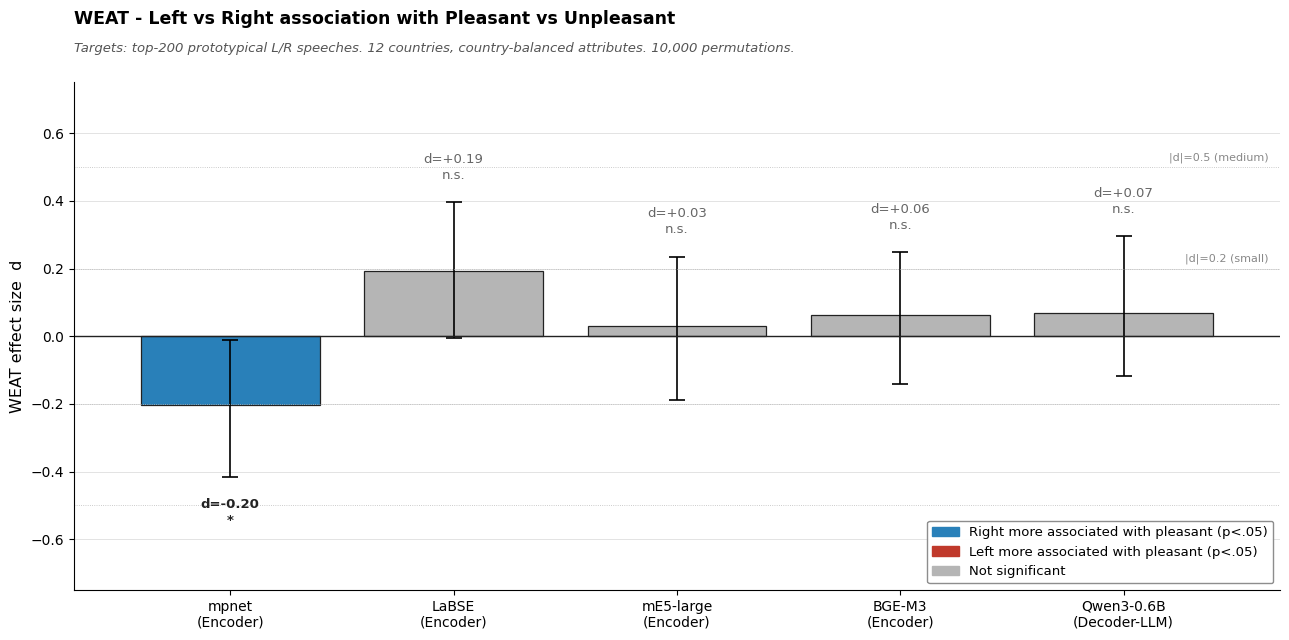


Plot saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/weat.png


In [ ]:
# ============================================================
# Cell 8: WEAT - Word Embedding Association Test
# ============================================================
import os, gc, warnings, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Paths and constants (always defined) ───────────────────
DRIVE_ROOT = '/content/drive/MyDrive/parlamint_thesis'
EMBED_DIR  = f'{DRIVE_ROOT}/embeddings/q1_12c'
RESULTS    = f'{DRIVE_ROOT}/results/q1_12c'
os.makedirs(RESULTS, exist_ok=True)

MODELS = ['paraphrase-mpnet','LaBSE','mE5-large','BGE-M3','Qwen3-Embedding-0.6B']
COUNTRIES = {'NL':'Netherlands','BE':'Belgium','ES':'Spain','PT':'Portugal',
             'DK':'Denmark','FI':'Finland','CZ':'Czechia','HR':'Croatia',
             'SI':'Slovenia','AT':'Austria','RS':'Serbia','UA':'Ukraine'}
MODEL_ARCH = {'paraphrase-mpnet':'Encoder','LaBSE':'Encoder',
              'mE5-large':'Encoder','BGE-M3':'Encoder',
              'Qwen3-Embedding-0.6B':'Decoder-LLM'}
SHORT_NAMES = {'paraphrase-mpnet':'mpnet','LaBSE':'LaBSE',
               'mE5-large':'mE5-large','BGE-M3':'BGE-M3',
               'Qwen3-Embedding-0.6B':'Qwen3-0.6B'}
SEED = 42
TOP_N_TARGET = 200
N_PERM = 10_000
N_BOOT = 500
PERM_BATCH = 1000

def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# ── Load data if not already in memory ─────────────────────
if 'all_embeddings' not in globals():
    from google.colab import drive
    try: drive.mount('/content/drive')
    except: drive.mount('/content/drive', force_remount=True)
    df = pd.read_csv(f'{EMBED_DIR}/metadata.csv',
                      low_memory=False).reset_index(drop=True)
    all_embeddings = {}
    for name in MODELS:
        all_embeddings[name] = np.load(
            f'{EMBED_DIR}/embeddings_{name}.npy').astype(np.float32)
        print(f'Loaded {name}: {all_embeddings[name].shape}')

# ── Multilingual pleasant/unpleasant vocab
#    (English plus the 11 corpus languages; tagging uses the corpus languages) ──
EVAL_WORDS = {
    'pleasant': {
        'en': ['progress','fair','rights','justice','support','protect','help',
               'opportunity','benefit','success','improve','good','positive','effective'],
        'nl': ['vooruitgang','eerlijk','rechten','rechtvaardigheid','steun',
               'beschermen','helpen','kans','voordeel','succes','verbeteren',
               'goed','positief','effectief'],
        'es': ['progreso','justo','derechos','justicia','apoyo','proteger',
               'ayudar','oportunidad','beneficio','éxito','mejorar','bueno',
               'positivo','efectivo'],
        'pt': ['progresso','justo','direitos','justiça','apoio','proteger',
               'ajudar','oportunidade','benefício','sucesso','melhorar','bom',
               'positivo','eficaz'],
        'da': ['fremskridt','retfærdig','rettigheder','retfærdighed','støtte',
               'beskytte','hjælpe','mulighed','fordel','succes','forbedre',
               'god','positiv','effektiv'],
        'fi': ['edistys','oikeudenmukainen','oikeudet','oikeus','tuki',
               'suojella','auttaa','mahdollisuus','hyöty','menestys',
               'parantaa','hyvä','positiivinen','tehokas'],
        'cs': ['pokrok','spravedlivý','práva','spravedlnost','podpora',
               'chránit','pomoci','příležitost','výhoda','úspěch','zlepšit',
               'dobrý','pozitivní','efektivní'],
        'hr': ['napredak','pravedan','prava','pravda','podrška','zaštititi',
               'pomoći','prilika','korist','uspjeh','poboljšati','dobar',
               'pozitivan','učinkovit'],
        'sl': ['napredek','pravičen','pravice','pravičnost','podpora',
               'zaščititi','pomagati','priložnost','korist','uspeh','izboljšati',
               'dober','pozitiven','učinkovit'],
        'de': ['Fortschritt','gerecht','Rechte','Gerechtigkeit','Unterstützung',
               'schützen','helfen','Chance','Vorteil','Erfolg','verbessern',
               'gut','positiv','effektiv'],
        'sr': ['напредак','правичан','права','правда','подршка','заштитити',
               'помоћи','прилика','успех','побољшати','добар',
               'позитиван','ефикасан',
               'napredak','pravičan','prava','pravda','podrška','zaštititi',
               'pomoći','prilika','korist','uspeh','poboljšati','dobar',
               'pozitivan','efikasan'],
        'uk': ['прогрес','справедливий','права','справедливість','підтримка',
               'захищати','допомагати','можливість','перевага','успіх',
               'покращити','хороший','позитивний','ефективний'],
    },
    'unpleasant': {
        'en': ['threat','crisis','failure','danger','attack','destroy','damage',
               'loss','corruption','crime','violence','bad','negative','harm'],
        'nl': ['dreiging','crisis','mislukking','gevaar','aanval','vernietigen',
               'schade','verlies','corruptie','misdaad','geweld','slecht','negatief','kwaad'],
        'es': ['amenaza','crisis','fracaso','peligro','ataque','destruir','daño',
               'pérdida','corrupción','crimen','violencia','malo','negativo','mal'],
        'pt': ['ameaça','crise','fracasso','perigo','ataque','destruir','dano',
               'perda','corrupção','crime','violência','mau','negativo','mal'],
        'da': ['trussel','krise','fiasko','fare','angreb','ødelægge','skade','tab',
               'korruption','kriminalitet','vold','dårlig','negativ','skade'],
        'fi': ['uhka','kriisi','epäonnistuminen','vaara','hyökkäys','tuhota',
               'vahinko','menetys','korruptio','rikos','väkivalta','huono',
               'negatiivinen','haitta'],
        'cs': ['hrozba','krize','selhání','nebezpečí','útok','zničit','škoda',
               'ztráta','korupce','zločin','násilí','špatný','negativní','újma'],
        'hr': ['prijetnja','kriza','neuspjeh','opasnost','napad','uništiti',
               'šteta','gubitak','korupcija','zločin','nasilje','loš','negativan','štetan'],
        'sl': ['grožnja','kriza','neuspeh','nevarnost','napad','uničiti','škoda',
               'izguba','korupcija','zločin','nasilje','slab','negativen','škodljiv'],
        'de': ['Bedrohung','Krise','Versagen','Gefahr','Angriff','zerstören',
               'Schaden','Verlust','Korruption','Verbrechen','Gewalt',
               'schlecht','negativ','Schaden'],
        'sr': ['претња','криза','неуспех','опасност','напад','уништити','штета',
               'губитак','корупција','злочин','насиље','лош','негативан','штетан',
               'pretnja','kriza','neuspeh','opasnost','napad','uništiti','šteta',
               'gubitak','korupcija','zločin','nasilje','loš','negativan','štetan'],
        'uk': ['загроза','криза','невдача','небезпека','напад','знищити','шкода',
               'втрата','корупція','злочин','насильство','поганий','негативний','шкідливий'],
    },
}
COUNTRY_TO_LANG = {'NL':'nl','BE':'nl','ES':'es','PT':'pt','DK':'da','FI':'fi',
                   'CZ':'cs','HR':'hr','SI':'sl','AT':'de','RS':'sr','UA':'uk'}

print(f'\n{"="*60}\nWEAT - Word Embedding Association Test (A100 GPU)\n{"="*60}')

# ── Tag speeches as pleasant/unpleasant ───────────────────
def has_eval_words(text, words):
    t = text.lower()
    return any(w.lower() in t for w in words)

sample_path = f'{DRIVE_ROOT}/data/processed/sample_balanced_12c_q1.csv'
texts_df = pd.read_csv(sample_path, low_memory=False, usecols=['ID','text'])
texts_df = texts_df.set_index('ID').reindex(df['ID'].values).reset_index()
texts = texts_df['text'].astype(str).values

pleasant_mask = np.zeros(len(df), dtype=bool)
unpleasant_mask = np.zeros(len(df), dtype=bool)
print('Per-country tagging:')
for c in COUNTRIES:
    lang = COUNTRY_TO_LANG[c]
    country_idx = np.where(df['country'].values == c)[0]
    pl_words = EVAL_WORDS['pleasant'][lang]
    un_words = EVAL_WORDS['unpleasant'][lang]
    n_pl, n_un = 0, 0
    for i in country_idx:
        if has_eval_words(texts[i], pl_words):
            pleasant_mask[i] = True; n_pl += 1
        if has_eval_words(texts[i], un_words):
            unpleasant_mask[i] = True; n_un += 1
    print(f'  {c}: {n_pl:,} pleasant, {n_un:,} unpleasant')

A_mask = pleasant_mask & ~unpleasant_mask
B_mask = unpleasant_mask & ~pleasant_mask
print(f'\nPleasant only: {A_mask.sum():,}')
print(f'Unpleasant only: {B_mask.sum():,}')

# Country-balanced attribute sets
rng = np.random.default_rng(SEED)
A_balanced, B_balanced = [], []
for c in COUNTRIES:
    c_mask = df['country'].values == c
    a_pool = np.where(A_mask & c_mask)[0]
    b_pool = np.where(B_mask & c_mask)[0]
    n = min(len(a_pool), len(b_pool))
    if n < 20:
        print(f'  {c}: insufficient ({len(a_pool)}, {len(b_pool)}) - skipping')
        continue
    A_balanced.extend(rng.choice(a_pool, size=n, replace=False))
    B_balanced.extend(rng.choice(b_pool, size=n, replace=False))

A_idx = np.array(A_balanced)
B_idx = np.array(B_balanced)
print(f'\nBalanced attribute set sizes: A={len(A_idx)}, B={len(B_idx)}')


# ── GPU WEAT primitives ───────────────────────────────────
@torch.no_grad()
def gpu_assoc_scores(W, A_v, B_v):
    a_mean = A_v.mean(dim=0)
    b_mean = B_v.mean(dim=0)
    return W @ a_mean - W @ b_mean

@torch.no_grad()
def gpu_weat_perm(emb_gpu, X_idx, Y_idx, A_idx, B_idx,
                   n_perm=10_000, batch=1000, seed=42):
    A_v = emb_gpu[A_idx]
    B_v = emb_gpu[B_idx]
    pooled_idx = torch.cat([
        torch.as_tensor(X_idx, device=emb_gpu.device),
        torch.as_tensor(Y_idx, device=emb_gpu.device)
    ])
    pooled_emb = emb_gpu[pooled_idx]
    scores = gpu_assoc_scores(pooled_emb, A_v, B_v)
    n_X = len(X_idx); N = len(pooled_idx)
    pooled_std_obs = torch.cat([scores[:n_X], scores[n_X:]]).std(unbiased=True)
    obs_d = ((scores[:n_X].mean() - scores[n_X:].mean()) / pooled_std_obs).item()

    gen = torch.Generator(device=emb_gpu.device).manual_seed(seed)
    n_done = 0
    ge_count = 0
    obs_abs = abs(obs_d)
    while n_done < n_perm:
        bsz = min(batch, n_perm - n_done)
        perm = torch.argsort(torch.rand(bsz, N, device=emb_gpu.device,
                                          generator=gen), dim=1)
        s_perm = scores[perm]
        sx_b = s_perm[:, :n_X]; sy_b = s_perm[:, n_X:]
        all_b = torch.cat([sx_b, sy_b], dim=1)
        d_b = (sx_b.mean(dim=1) - sy_b.mean(dim=1)) / all_b.std(dim=1, unbiased=True)
        ge_count += (d_b.abs() >= obs_abs - 1e-12).sum().item()
        n_done += bsz
    return obs_d, ge_count / n_perm

@torch.no_grad()
def gpu_weat_bootstrap(emb_gpu, X_idx, Y_idx, A_idx, B_idx,
                        n_boot=500, seed=42):
    n_X = len(X_idx); n_Y = len(Y_idx)
    n_A = len(A_idx); n_B = len(B_idx)
    X_t = torch.as_tensor(X_idx, device=emb_gpu.device)
    Y_t = torch.as_tensor(Y_idx, device=emb_gpu.device)
    A_t = torch.as_tensor(A_idx, device=emb_gpu.device)
    B_t = torch.as_tensor(B_idx, device=emb_gpu.device)
    gen = torch.Generator(device=emb_gpu.device).manual_seed(seed)
    boot_d = torch.empty(n_boot, device=emb_gpu.device)
    for k in range(n_boot):
        xb = X_t[torch.randint(0, n_X, (n_X,), device=emb_gpu.device, generator=gen)]
        yb = Y_t[torch.randint(0, n_Y, (n_Y,), device=emb_gpu.device, generator=gen)]
        ab = A_t[torch.randint(0, n_A, (n_A,), device=emb_gpu.device, generator=gen)]
        bb = B_t[torch.randint(0, n_B, (n_B,), device=emb_gpu.device, generator=gen)]
        A_v = emb_gpu[ab]; B_v = emb_gpu[bb]
        sx = gpu_assoc_scores(emb_gpu[xb], A_v, B_v)
        sy = gpu_assoc_scores(emb_gpu[yb], A_v, B_v)
        pooled = torch.cat([sx, sy]).std(unbiased=True)
        boot_d[k] = (sx.mean() - sy.mean()) / pooled
    ci = torch.quantile(boot_d, torch.tensor([0.025, 0.975],
                                              device=emb_gpu.device))
    return ci[0].item(), ci[1].item()


# ── Run WEAT for each model ──────────────────────────────
print(f'\n{"="*60}\nRunning WEAT for each model\n{"="*60}')
weat_results = {}
left_idx_global  = np.where(df['orient_lr'].values == 'left')[0]
right_idx_global = np.where(df['orient_lr'].values == 'right')[0]
t0_all = time.time()

for name, emb_np in all_embeddings.items():
    t0 = time.time()
    emb_gpu = torch.from_numpy(emb_np).to(device)

    L_centroid = emb_gpu[left_idx_global].mean(dim=0)
    L_centroid = L_centroid / L_centroid.norm()
    R_centroid = emb_gpu[right_idx_global].mean(dim=0)
    R_centroid = R_centroid / R_centroid.norm()
    L_sims = emb_gpu[left_idx_global]  @ L_centroid
    R_sims = emb_gpu[right_idx_global] @ R_centroid
    X_idx = left_idx_global[torch.argsort(L_sims, descending=True)[:TOP_N_TARGET].cpu().numpy()]
    Y_idx = right_idx_global[torch.argsort(R_sims, descending=True)[:TOP_N_TARGET].cpu().numpy()]

    d, p = gpu_weat_perm(emb_gpu, X_idx, Y_idx, A_idx, B_idx,
                          n_perm=N_PERM, batch=PERM_BATCH, seed=SEED)
    ci_low, ci_high = gpu_weat_bootstrap(emb_gpu, X_idx, Y_idx, A_idx, B_idx,
                                            n_boot=N_BOOT, seed=SEED)

    weat_results[name] = {'d': d, 'p': p,
                           'ci_low': ci_low, 'ci_high': ci_high}
    dt = time.time() - t0
    print(f'{name:<24}  d={d:+.3f}  '
          f'[95% CI {ci_low:+.3f}, {ci_high:+.3f}]   '
          f'p={p:.4f} {stars(p)}   ({dt:.1f}s)')

    del emb_gpu
    torch.cuda.empty_cache()
    gc.collect()

print(f'\nTotal WEAT runtime: {(time.time()-t0_all)/60:.2f} min')

pd.DataFrame([{'model': n, **r} for n, r in weat_results.items()]).to_csv(
    f'{RESULTS}/weat.csv', index=False)
print(f'Saved: {RESULTS}/weat.csv')


# ════════════════════════════════════════════════════════════
# PLOT
# ════════════════════════════════════════════════════════════
WEAT_COLORS = {'pos': '#2980B9', 'neg': '#C0392B', 'ns': '#B5B5B5'}

fig, ax = plt.subplots(figsize=(13, 6.5))
xs = np.arange(len(MODELS))
ds  = np.array([weat_results[m]['d'] for m in MODELS])
ci_lo = np.array([weat_results[m]['d']-weat_results[m]['ci_low'] for m in MODELS])
ci_hi = np.array([weat_results[m]['ci_high']-weat_results[m]['d'] for m in MODELS])
ps = np.array([weat_results[m]['p'] for m in MODELS])

def col(d, p):
    if p >= 0.05: return WEAT_COLORS['ns']
    # d > 0 means left more pleasant -> red (left convention)
    # d < 0 means right more pleasant -> blue (right convention)
    return WEAT_COLORS['neg'] if d > 0 else WEAT_COLORS['pos']

ax.bar(xs, ds, yerr=[ci_lo, ci_hi], capsize=6,
       color=[col(d, p) for d, p in zip(ds, ps)],
       edgecolor='#222', linewidth=0.9,
       error_kw={'elinewidth': 1.2, 'capthick': 1.2})

ax.axhline(0, color='#222', linewidth=1)

# Symmetric y-range with padding for bar labels
y_range = max(np.abs(ds+ci_hi).max(), np.abs(ds-ci_lo).max(), 0.5)
ax.set_ylim(-y_range*1.5, y_range*1.5)
ax.set_xlim(-0.7, len(MODELS) - 0.3)

# Cohen's d reference lines (only those inside y-range)
for v, lbl in [(0.2, 'small'), (0.5, 'medium'), (0.8, 'large')]:
    if v < y_range * 1.45:
        ax.axhline(v,  color='#bbb', linewidth=0.6, linestyle=':')
        ax.axhline(-v, color='#bbb', linewidth=0.6, linestyle=':')
        ax.text(len(MODELS) - 0.35, v + 0.02,
                f'|d|={v} ({lbl})', fontsize=8, color='#888', ha='right')

ax.set_xticks(xs)
ax.set_xticklabels([f'{SHORT_NAMES[m]}\n({MODEL_ARCH[m]})' for m in MODELS],
                    fontsize=10)
ax.set_ylabel('WEAT effect size  d', fontsize=11.5)
ax.set_title('WEAT - Left vs Right association with Pleasant vs Unpleasant',
             fontsize=12.5, fontweight='bold', loc='left', pad=42)
ax.text(0.0, 1.06,
        f'Targets: top-{TOP_N_TARGET} prototypical L/R speeches. '
        '12 countries, country-balanced attributes. 10,000 permutations.',
        transform=ax.transAxes, fontsize=9.5, style='italic', color='#555')

# Bar value labels above/below bars
for i, (d_, p_) in enumerate(zip(ds, ps)):
    upper = d_+ci_hi[i]; lower = d_-ci_lo[i]
    if d_ >= 0:
        y_text = upper + y_range*0.12; va = 'bottom'
    else:
        y_text = lower - y_range*0.12; va = 'top'
    sig = stars(p_) if p_ < 0.05 else 'n.s.'
    weight = 'bold' if p_ < 0.05 else 'normal'
    color = '#222' if p_ < 0.05 else '#666'
    ax.text(i, y_text, f'd={d_:+.2f}\n{sig}',
            ha='center', va=va, fontsize=9.5,
            fontweight=weight, color=color, linespacing=1.3)

ax.legend(handles=[
    mpatches.Patch(color=WEAT_COLORS['pos'],
                   label='Right more associated with pleasant (p<.05)'),
    mpatches.Patch(color=WEAT_COLORS['neg'],
                   label='Left more associated with pleasant (p<.05)'),
    mpatches.Patch(color=WEAT_COLORS['ns'], label='Not significant'),
], loc='lower right', fontsize=9.5, framealpha=0.96, edgecolor='#888')

ax.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{RESULTS}/weat.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nPlot saved: {RESULTS}/weat.png')

### What the result shows: inconsistent across models, with one significant but small effect

Across the five models, only one returns a statistically significant effect: paraphrase-mpnet, with d = -0.204 (p = 0.0395). In Cohen's conventions this is a small effect, well below the d = 0.5 medium threshold. The sign is negative, which by the encoding I described in the intro means **right-leaning** content is more associated with pleasant valence than left-leaning content. None of the other four models comes close to significance. LaBSE returns d = +0.194 with p = 0.0507, which is at the edge of conventional significance but in the **opposite** direction from mpnet (left-leaning content more pleasant-associated). The remaining three models (mE5-large, BGE-M3, Qwen3) all return effect sizes between +0.029 and +0.069 with p-values between 0.4917 and 0.7685. These are null findings.

The first thing this tells me is that WEAT is not picking up the same pattern that S1 retrieval picked up. The S1 cross-country retrieval test showed four encoders leaning left and one decoder leaning right, with effect sizes between d = -0.471 and d = +0.270 and four out of five p-values below 0.001. The WEAT test on the same models and the same corpus returns one significant result that *contradicts* the S1 direction for mpnet (S1 said mpnet retrieves left-leaning content more, whereas WEAT says mpnet's prototypical left targets are *less* associated with pleasant valence than its right targets), one borderline opposite-sign effect for LaBSE that *agrees* with the S1 direction, and three nulls. The two tests are clearly measuring different things, and the bias detection literature has known this for some time. WEAT measures the relative *valence association* of two target categories. S1 measures the relative *retrieval coverage* of two ideological centroids. A model can show one of these and not the other, and as the mpnet case demonstrates, the two can even point in opposite directions on the same model.

The second thing the result tells me is that mpnet's significant effect is fragile. It is the smallest model in the set (278M parameters), and it is the only one of the five that reaches significance on the WEAT instrument. With four other models on the same corpus producing null or opposite-sign effects, the most honest reading is that mpnet's WEAT effect is unlikely to generalise. The next cell, which subjects the WEAT result to a battery of confound controls (country-governance restriction, role restriction, and per-country breakdown), will return to this question and ask whether even the mpnet effect survives those controls.

For the broader bias claim, the WEAT result is best read as the negative result that the literature has been quietly reporting for some time. WEAT-style instruments are noisy on sentence embeddings, sensitive to attribute set construction, and not always consistent with downstream behavioural measures of bias. Ethayarajh et al. (2019) made this argument formally, and the data from this cell are consistent with their critique. The contradiction between mpnet's WEAT sign and its S1 sign is in fact a clean illustration of that argument: two instruments applied to the same model on the same corpus return opposing directions, which is exactly the kind of inconsistency that the Ethayarajh et al. (2019) critique anticipates. The retrieval and classification results elsewhere in this notebook (S1, S2, the regression, the topic-controlled retrieval) carry more weight than the WEAT result and should be the primary basis for any bias claim in the thesis.


## WEAT confound battery: does the effect survive controls?

The previous cell found one significant WEAT result out of five models (paraphrase-mpnet, d = -0.204, p = 0.0395), with the other four models null or borderline-opposite. A single significant result on one model is exactly the kind of finding that needs to be stress-tested before it goes anywhere near a thesis claim. This cell runs four separate controls on the WEAT setup and asks, for each model, whether any effect survives.

The first control (T1) restricts the corpus to **right-governed countries only**. Of the twelve countries, eight had a right-leaning lead party during the period covered (NL, ES, PT, DK, CZ, HR, SI, AT). If the WEAT effect is partly a reflection of which side happened to be in power, restricting to right-governed countries should change it. If the effect is about ideology itself, it should hold up.

The second and third controls (T2a and T2b) split the corpus by **institutional role**. T2a keeps only coalition speeches, T2b keeps only opposition speeches. This is the same logic as the role-versus-ideology test in S2, applied to the WEAT instrument. If the valence association is really tracking government-versus-opposition rhetoric and not left-versus-right ideology, the effect should behave very differently in the coalition-only and opposition-only subsets.

The fourth control (T3) breaks the WEAT down **country by country** for paraphrase-mpnet, the one model that showed a significant full-corpus effect. The full-corpus WEAT averages over all twelve countries, which means a small number of countries with strong effects could be carrying the overall result. Running the test separately for each country shows whether the effect is a broad pattern or a country-specific one.

Device: cuda
GPU: NVIDIA A100-SXM4-40GB

T1. Right-governed countries only
Right-governed set: ['AT', 'CZ', 'DK', 'ES', 'HR', 'NL', 'PT', 'SI']
  paraphrase-mpnet          d=-0.082  [95% CI -0.290, +0.125]   p=0.4121 ns
  LaBSE                     d=+0.017  [95% CI -0.160, +0.226]   p=0.8596 ns
  mE5-large                 d=+0.106  [95% CI -0.095, +0.318]   p=0.2881 ns
  BGE-M3                    d=+0.064  [95% CI -0.120, +0.268]   p=0.5187 ns
  Qwen3-Embedding-0.6B      d=+0.077  [95% CI -0.106, +0.253]   p=0.4500 ns
T1 runtime: 2.4s

T2a. Coalition speeches only
  paraphrase-mpnet          d=-0.158  [95% CI -0.372, +0.031]   p=0.1153 ns
  LaBSE                     d=+0.043  [95% CI -0.134, +0.210]   p=0.6693 ns
  mE5-large                 d=+0.043  [95% CI -0.140, +0.226]   p=0.6683 ns
  BGE-M3                    d=-0.052  [95% CI -0.239, +0.157]   p=0.5991 ns
  Qwen3-Embedding-0.6B      d=+0.046  [95% CI -0.162, +0.252]   p=0.6505 ns
T2a runtime: 2.4s

T2b. Opposition speeches only


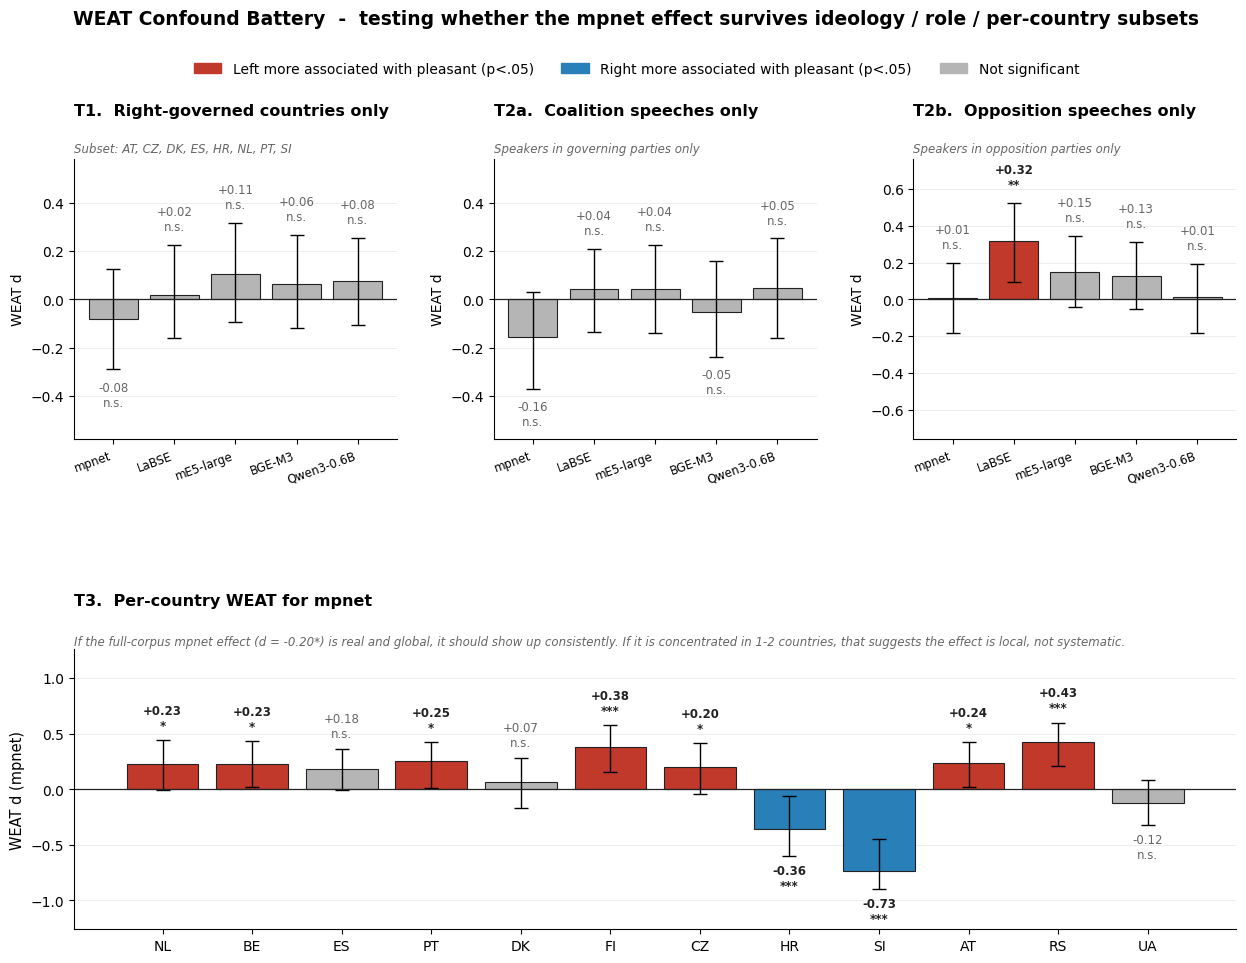


Plot saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/weat_confounds.png


In [ ]:
# ============================================================
# Cell 9: WEAT Confound Battery
# ============================================================
# Cell 8 found one significant WEAT effect (mpnet d=-0.20*)
# and one borderline trend (LaBSE d=+0.19, p=.052). Before
# accepting these as genuine ideology biases, three confounds
# need testing:
#
#   T1. Governing-ideology: restrict to right-governed
#       countries only.
#   T2a. Coalition only.
#   T2b. Opposition only.
#   T3. Per-country WEAT for mpnet (the only sig. model):
#       is the effect concentrated in 1-2 countries?
#
# Restart-safe: re-defines every helper and reloads data
# if kernel was reset between Cell 8 and Cell 9.

import os, gc, warnings, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Paths and constants ────────────────────────────────────
DRIVE_ROOT = '/content/drive/MyDrive/parlamint_thesis'
EMBED_DIR  = f'{DRIVE_ROOT}/embeddings/q1_12c'
RESULTS    = f'{DRIVE_ROOT}/results/q1_12c'
os.makedirs(RESULTS, exist_ok=True)

MODELS = ['paraphrase-mpnet','LaBSE','mE5-large','BGE-M3','Qwen3-Embedding-0.6B']
COUNTRIES = {'NL':'Netherlands','BE':'Belgium','ES':'Spain','PT':'Portugal',
             'DK':'Denmark','FI':'Finland','CZ':'Czechia','HR':'Croatia',
             'SI':'Slovenia','AT':'Austria','RS':'Serbia','UA':'Ukraine'}
MODEL_ARCH = {'paraphrase-mpnet':'Encoder','LaBSE':'Encoder',
              'mE5-large':'Encoder','BGE-M3':'Encoder',
              'Qwen3-Embedding-0.6B':'Decoder-LLM'}
SHORT_NAMES = {'paraphrase-mpnet':'mpnet','LaBSE':'LaBSE',
               'mE5-large':'mE5-large','BGE-M3':'BGE-M3',
               'Qwen3-Embedding-0.6B':'Qwen3-0.6B'}

# Right-governed countries: ones where the lead party in the
# covered period was right-leaning. Used for confound T1.
RIGHT_GOVERNED = {'NL','ES','PT','DK','CZ','HR','SI','AT'}

SEED = 42
TOP_N_TARGET = 200
N_PERM = 10_000
N_BOOT = 500
PERM_BATCH = 1000

def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

# ── Restart-safe data loading ─────────────────────────────
if 'all_embeddings' not in globals():
    from google.colab import drive
    try: drive.mount('/content/drive')
    except: drive.mount('/content/drive', force_remount=True)
    df = pd.read_csv(f'{EMBED_DIR}/metadata.csv',
                      low_memory=False).reset_index(drop=True)
    all_embeddings = {}
    for name in MODELS:
        all_embeddings[name] = np.load(
            f'{EMBED_DIR}/embeddings_{name}.npy').astype(np.float32)
        print(f'Loaded {name}: {all_embeddings[name].shape}')

# ── Restart-safe attribute sets (rebuild A_idx / B_idx) ───
if 'A_idx' not in globals() or 'B_idx' not in globals():
    print('Rebuilding pleasant/unpleasant tagging...')
    EVAL_WORDS = {
        'pleasant': {
            'en': ['progress','fair','rights','justice','support','protect','help',
                   'opportunity','benefit','success','improve','good','positive','effective'],
            'nl': ['vooruitgang','eerlijk','rechten','rechtvaardigheid','steun',
                   'beschermen','helpen','kans','voordeel','succes','verbeteren',
                   'goed','positief','effectief'],
            'es': ['progreso','justo','derechos','justicia','apoyo','proteger',
                   'ayudar','oportunidad','beneficio','éxito','mejorar','bueno',
                   'positivo','efectivo'],
            'pt': ['progresso','justo','direitos','justiça','apoio','proteger',
                   'ajudar','oportunidade','benefício','sucesso','melhorar','bom',
                   'positivo','eficaz'],
            'da': ['fremskridt','retfærdig','rettigheder','retfærdighed','støtte',
                   'beskytte','hjælpe','mulighed','fordel','succes','forbedre',
                   'god','positiv','effektiv'],
            'fi': ['edistys','oikeudenmukainen','oikeudet','oikeus','tuki',
                   'suojella','auttaa','mahdollisuus','hyöty','menestys',
                   'parantaa','hyvä','positiivinen','tehokas'],
            'cs': ['pokrok','spravedlivý','práva','spravedlnost','podpora',
                   'chránit','pomoci','příležitost','výhoda','úspěch','zlepšit',
                   'dobrý','pozitivní','efektivní'],
            'hr': ['napredak','pravedan','prava','pravda','podrška','zaštititi',
                   'pomoći','prilika','korist','uspjeh','poboljšati','dobar',
                   'pozitivan','učinkovit'],
            'sl': ['napredek','pravičen','pravice','pravičnost','podpora',
                   'zaščititi','pomagati','priložnost','korist','uspeh','izboljšati',
                   'dober','pozitiven','učinkovit'],
            'de': ['Fortschritt','gerecht','Rechte','Gerechtigkeit','Unterstützung',
                   'schützen','helfen','Chance','Vorteil','Erfolg','verbessern',
                   'gut','positiv','effektiv'],
            'sr': ['напредак','правичан','права','правда','подршка','заштитити',
                   'помоћи','прилика','успех','побољшати','добар',
                   'позитиван','ефикасан',
                   'napredak','pravičan','prava','pravda','podrška','zaštititi',
                   'pomoći','prilika','korist','uspeh','poboljšati','dobar',
                   'pozitivan','efikasan'],
            'uk': ['прогрес','справедливий','права','справедливість','підтримка',
                   'захищати','допомагати','можливість','перевага','успіх',
                   'покращити','хороший','позитивний','ефективний'],
        },
        'unpleasant': {
            'en': ['threat','crisis','failure','danger','attack','destroy','damage',
                   'loss','corruption','crime','violence','bad','negative','harm'],
            'nl': ['dreiging','crisis','mislukking','gevaar','aanval','vernietigen',
                   'schade','verlies','corruptie','misdaad','geweld','slecht','negatief','kwaad'],
            'es': ['amenaza','crisis','fracaso','peligro','ataque','destruir','daño',
                   'pérdida','corrupción','crimen','violencia','malo','negativo','mal'],
            'pt': ['ameaça','crise','fracasso','perigo','ataque','destruir','dano',
                   'perda','corrupção','crime','violência','mau','negativo','mal'],
            'da': ['trussel','krise','fiasko','fare','angreb','ødelægge','skade','tab',
                   'korruption','kriminalitet','vold','dårlig','negativ','skade'],
            'fi': ['uhka','kriisi','epäonnistuminen','vaara','hyökkäys','tuhota',
                   'vahinko','menetys','korruptio','rikos','väkivalta','huono',
                   'negatiivinen','haitta'],
            'cs': ['hrozba','krize','selhání','nebezpečí','útok','zničit','škoda',
                   'ztráta','korupce','zločin','násilí','špatný','negativní','újma'],
            'hr': ['prijetnja','kriza','neuspjeh','opasnost','napad','uništiti',
                   'šteta','gubitak','korupcija','zločin','nasilje','loš','negativan','štetan'],
            'sl': ['grožnja','kriza','neuspeh','nevarnost','napad','uničiti','škoda',
                   'izguba','korupcija','zločin','nasilje','slab','negativen','škodljiv'],
            'de': ['Bedrohung','Krise','Versagen','Gefahr','Angriff','zerstören',
                   'Schaden','Verlust','Korruption','Verbrechen','Gewalt',
                   'schlecht','negativ','Schaden'],
            'sr': ['претња','криза','неуспех','опасност','напад','уништити','штета',
                   'губитак','корупција','злочин','насиље','лош','негативан','штетан',
                   'pretnja','kriza','neuspeh','opasnost','napad','uništiti','šteta',
                   'gubitak','korupcija','zločin','nasilje','loš','negativan','štetan'],
            'uk': ['загроза','криза','невдача','небезпека','напад','знищити','шкода',
                   'втрата','корупція','злочин','насильство','поганий','негативний','шкідливий'],
        },
    }
    COUNTRY_TO_LANG = {'NL':'nl','BE':'nl','ES':'es','PT':'pt','DK':'da','FI':'fi',
                       'CZ':'cs','HR':'hr','SI':'sl','AT':'de','RS':'sr','UA':'uk'}

    def has_eval_words(text, words):
        t = text.lower()
        return any(w.lower() in t for w in words)

    sample_path = f'{DRIVE_ROOT}/data/processed/sample_balanced_12c_q1.csv'
    texts_df = pd.read_csv(sample_path, low_memory=False, usecols=['ID','text'])
    texts_df = texts_df.set_index('ID').reindex(df['ID'].values).reset_index()
    texts = texts_df['text'].astype(str).values

    pleasant_mask = np.zeros(len(df), dtype=bool)
    unpleasant_mask = np.zeros(len(df), dtype=bool)
    for c in COUNTRIES:
        lang = COUNTRY_TO_LANG[c]
        country_idx = np.where(df['country'].values == c)[0]
        pl_words = EVAL_WORDS['pleasant'][lang]
        un_words = EVAL_WORDS['unpleasant'][lang]
        for i in country_idx:
            if has_eval_words(texts[i], pl_words):
                pleasant_mask[i] = True
            if has_eval_words(texts[i], un_words):
                unpleasant_mask[i] = True

    A_mask = pleasant_mask & ~unpleasant_mask
    B_mask = unpleasant_mask & ~pleasant_mask
    rng = np.random.default_rng(SEED)
    A_balanced, B_balanced = [], []
    for c in COUNTRIES:
        c_mask = df['country'].values == c
        a_pool = np.where(A_mask & c_mask)[0]
        b_pool = np.where(B_mask & c_mask)[0]
        n = min(len(a_pool), len(b_pool))
        if n < 20:
            continue
        A_balanced.extend(rng.choice(a_pool, size=n, replace=False))
        B_balanced.extend(rng.choice(b_pool, size=n, replace=False))
    A_idx = np.array(A_balanced)
    B_idx = np.array(B_balanced)
    print(f'Attribute sets rebuilt: A={len(A_idx)}, B={len(B_idx)}')


# ── GPU WEAT primitives ───────────────────────────────────
@torch.no_grad()
def gpu_assoc_scores(W, A_v, B_v):
    a_mean = A_v.mean(dim=0)
    b_mean = B_v.mean(dim=0)
    return W @ a_mean - W @ b_mean

@torch.no_grad()
def gpu_weat_perm(emb_gpu, X_idx, Y_idx, A_idx_in, B_idx_in,
                   n_perm=10_000, batch=1000, seed=42):
    A_v = emb_gpu[A_idx_in]
    B_v = emb_gpu[B_idx_in]
    pooled_idx = torch.cat([
        torch.as_tensor(X_idx, device=emb_gpu.device),
        torch.as_tensor(Y_idx, device=emb_gpu.device)
    ])
    pooled_emb = emb_gpu[pooled_idx]
    scores = gpu_assoc_scores(pooled_emb, A_v, B_v)
    n_X = len(X_idx); N = len(pooled_idx)
    pooled_std_obs = torch.cat([scores[:n_X], scores[n_X:]]).std(unbiased=True)
    obs_d = ((scores[:n_X].mean() - scores[n_X:].mean()) / pooled_std_obs).item()

    gen = torch.Generator(device=emb_gpu.device).manual_seed(seed)
    n_done = 0
    ge_count = 0
    obs_abs = abs(obs_d)
    while n_done < n_perm:
        bsz = min(batch, n_perm - n_done)
        perm = torch.argsort(torch.rand(bsz, N, device=emb_gpu.device,
                                          generator=gen), dim=1)
        s_perm = scores[perm]
        sx_b = s_perm[:, :n_X]; sy_b = s_perm[:, n_X:]
        all_b = torch.cat([sx_b, sy_b], dim=1)
        d_b = (sx_b.mean(dim=1) - sy_b.mean(dim=1)) / all_b.std(dim=1, unbiased=True)
        ge_count += (d_b.abs() >= obs_abs - 1e-12).sum().item()
        n_done += bsz
    return obs_d, ge_count / n_perm

@torch.no_grad()
def gpu_weat_bootstrap(emb_gpu, X_idx, Y_idx, A_idx_in, B_idx_in,
                        n_boot=500, seed=42):
    n_X = len(X_idx); n_Y = len(Y_idx)
    n_A = len(A_idx_in); n_B = len(B_idx_in)
    X_t = torch.as_tensor(X_idx, device=emb_gpu.device)
    Y_t = torch.as_tensor(Y_idx, device=emb_gpu.device)
    A_t = torch.as_tensor(A_idx_in, device=emb_gpu.device)
    B_t = torch.as_tensor(B_idx_in, device=emb_gpu.device)
    gen = torch.Generator(device=emb_gpu.device).manual_seed(seed)
    boot_d = torch.empty(n_boot, device=emb_gpu.device)
    for k in range(n_boot):
        xb = X_t[torch.randint(0, n_X, (n_X,), device=emb_gpu.device, generator=gen)]
        yb = Y_t[torch.randint(0, n_Y, (n_Y,), device=emb_gpu.device, generator=gen)]
        ab = A_t[torch.randint(0, n_A, (n_A,), device=emb_gpu.device, generator=gen)]
        bb = B_t[torch.randint(0, n_B, (n_B,), device=emb_gpu.device, generator=gen)]
        A_v = emb_gpu[ab]; B_v = emb_gpu[bb]
        sx = gpu_assoc_scores(emb_gpu[xb], A_v, B_v)
        sy = gpu_assoc_scores(emb_gpu[yb], A_v, B_v)
        pooled = torch.cat([sx, sy]).std(unbiased=True)
        boot_d[k] = (sx.mean() - sy.mean()) / pooled
    ci = torch.quantile(boot_d, torch.tensor([0.025, 0.975],
                                              device=emb_gpu.device))
    return ci[0].item(), ci[1].item()


def select_targets(emb_gpu, left_idx, right_idx, top_n=TOP_N_TARGET):
    """Pick top-N prototypical left/right speeches by similarity to
    each ideology centroid (computed within the given subsample)."""
    if len(left_idx) < top_n or len(right_idx) < top_n:
        return None, None
    L_centroid = emb_gpu[left_idx].mean(dim=0)
    L_centroid = L_centroid / L_centroid.norm()
    R_centroid = emb_gpu[right_idx].mean(dim=0)
    R_centroid = R_centroid / R_centroid.norm()
    L_sims = emb_gpu[left_idx]  @ L_centroid
    R_sims = emb_gpu[right_idx] @ R_centroid
    X = left_idx[torch.argsort(L_sims, descending=True)[:top_n].cpu().numpy()]
    Y = right_idx[torch.argsort(R_sims, descending=True)[:top_n].cpu().numpy()]
    return X, Y


def run_weat(emb_gpu, left_idx, right_idx, A_in, B_in,
              top_n=TOP_N_TARGET, label='', verbose=True):
    X, Y = select_targets(emb_gpu, left_idx, right_idx, top_n)
    if X is None:
        if verbose:
            print(f'  {label:<24}  skipped (insufficient targets: '
                  f'L={len(left_idx)}, R={len(right_idx)})')
        return None
    d, p = gpu_weat_perm(emb_gpu, X, Y, A_in, B_in,
                          n_perm=N_PERM, batch=PERM_BATCH, seed=SEED)
    lo, hi = gpu_weat_bootstrap(emb_gpu, X, Y, A_in, B_in,
                                  n_boot=N_BOOT, seed=SEED)
    if verbose:
        print(f'  {label:<24}  d={d:+.3f}  '
              f'[95% CI {lo:+.3f}, {hi:+.3f}]   '
              f'p={p:.4f} {stars(p)}')
    return {'d': d, 'p': p, 'ci_low': lo, 'ci_high': hi,
            'n_left': len(left_idx), 'n_right': len(right_idx)}


# ── Global indices for ideology and country ───────────────
left_global  = np.where(df['orient_lr'].values == 'left')[0]
right_global = np.where(df['orient_lr'].values == 'right')[0]


# ════════════════════════════════════════════════════════════
# T1. Restrict to RIGHT-GOVERNED countries
# ════════════════════════════════════════════════════════════
print(f'\n{"="*60}\nT1. Right-governed countries only\n{"="*60}')
print(f'Right-governed set: {sorted(RIGHT_GOVERNED)}')
rg_mask = df['country'].isin(RIGHT_GOVERNED).values
t1_results = {}
t0 = time.time()
for name, emb_np in all_embeddings.items():
    emb_gpu = torch.from_numpy(emb_np).to(device)
    left_sub  = np.intersect1d(left_global,  np.where(rg_mask)[0])
    right_sub = np.intersect1d(right_global, np.where(rg_mask)[0])
    t1_results[name] = run_weat(emb_gpu, left_sub, right_sub,
                                  A_idx, B_idx, label=name)
    del emb_gpu; torch.cuda.empty_cache(); gc.collect()
print(f'T1 runtime: {time.time()-t0:.1f}s')


# ════════════════════════════════════════════════════════════
# T2a. COALITION speeches only
# ════════════════════════════════════════════════════════════
print(f'\n{"="*60}\nT2a. Coalition speeches only\n{"="*60}')
coal_mask = (df['Party_status'].values == 'Coalition')
t2a_results = {}
t0 = time.time()
for name, emb_np in all_embeddings.items():
    emb_gpu = torch.from_numpy(emb_np).to(device)
    left_sub  = np.intersect1d(left_global,  np.where(coal_mask)[0])
    right_sub = np.intersect1d(right_global, np.where(coal_mask)[0])
    t2a_results[name] = run_weat(emb_gpu, left_sub, right_sub,
                                   A_idx, B_idx, label=name)
    del emb_gpu; torch.cuda.empty_cache(); gc.collect()
print(f'T2a runtime: {time.time()-t0:.1f}s')


# ════════════════════════════════════════════════════════════
# T2b. OPPOSITION speeches only
# ════════════════════════════════════════════════════════════
print(f'\n{"="*60}\nT2b. Opposition speeches only\n{"="*60}')
opp_mask = (df['Party_status'].values == 'Opposition')
t2b_results = {}
t0 = time.time()
for name, emb_np in all_embeddings.items():
    emb_gpu = torch.from_numpy(emb_np).to(device)
    left_sub  = np.intersect1d(left_global,  np.where(opp_mask)[0])
    right_sub = np.intersect1d(right_global, np.where(opp_mask)[0])
    t2b_results[name] = run_weat(emb_gpu, left_sub, right_sub,
                                   A_idx, B_idx, label=name)
    del emb_gpu; torch.cuda.empty_cache(); gc.collect()
print(f'T2b runtime: {time.time()-t0:.1f}s')


# ════════════════════════════════════════════════════════════
# T3. PER-COUNTRY WEAT for mpnet
# ════════════════════════════════════════════════════════════
# Only mpnet was significant in Cell 8 (d=-0.20*). Is that
# effect driven by 1-2 countries or distributed across all?
# We re-run WEAT separately inside each of the 12 countries.
# Top_n is reduced because per-country pools are smaller;
# attribute set is restricted to that country only.
print(f'\n{"="*60}\nT3. Per-country WEAT for mpnet\n{"="*60}')
mpnet_emb = torch.from_numpy(all_embeddings['paraphrase-mpnet']).to(device)
t3_results = {}
t0 = time.time()
for c in COUNTRIES:
    c_idx = np.where(df['country'].values == c)[0]
    left_c  = np.intersect1d(left_global,  c_idx)
    right_c = np.intersect1d(right_global, c_idx)
    A_c = np.intersect1d(A_idx, c_idx)
    B_c = np.intersect1d(B_idx, c_idx)
    # use a smaller top_n if pools are tight
    top_n_c = min(TOP_N_TARGET, len(left_c)//2, len(right_c)//2,
                   len(A_c), len(B_c))
    if top_n_c < 30 or len(A_c) < 30 or len(B_c) < 30:
        print(f'  {COUNTRIES[c]:<12} ({c})  skipped (small pool)')
        t3_results[c] = None
        continue
    X, Y = select_targets(mpnet_emb, left_c, right_c, top_n=top_n_c)
    if X is None:
        t3_results[c] = None; continue
    d, p = gpu_weat_perm(mpnet_emb, X, Y, A_c, B_c,
                          n_perm=N_PERM, batch=PERM_BATCH, seed=SEED)
    lo, hi = gpu_weat_bootstrap(mpnet_emb, X, Y, A_c, B_c,
                                  n_boot=N_BOOT, seed=SEED)
    t3_results[c] = {'d': d, 'p': p, 'ci_low': lo, 'ci_high': hi,
                      'n_left': len(left_c), 'n_right': len(right_c),
                      'top_n': top_n_c}
    print(f'  {COUNTRIES[c]:<12} ({c})  d={d:+.3f}  '
          f'[95% CI {lo:+.3f}, {hi:+.3f}]   '
          f'p={p:.4f} {stars(p)}   (top_n={top_n_c})')
del mpnet_emb; torch.cuda.empty_cache(); gc.collect()
print(f'T3 runtime: {time.time()-t0:.1f}s')


# ════════════════════════════════════════════════════════════
# Save all confound results
# ════════════════════════════════════════════════════════════
rows = []
for name in MODELS:
    for label, res_dict in [('T1_right_governed', t1_results),
                              ('T2a_coalition',     t2a_results),
                              ('T2b_opposition',    t2b_results)]:
        r = res_dict.get(name)
        if r is None: continue
        rows.append({'test': label, 'model': name, **r})
for c, r in t3_results.items():
    if r is None: continue
    rows.append({'test': 'T3_mpnet_per_country',
                 'model': 'paraphrase-mpnet', 'country': c, **r})
pd.DataFrame(rows).to_csv(f'{RESULTS}/weat_confounds.csv', index=False)
print(f'\nSaved: {RESULTS}/weat_confounds.csv')


# ════════════════════════════════════════════════════════════
# PLOT - left=red, right=blue convention
# ════════════════════════════════════════════════════════════
# Convention used throughout this notebook:
#   d > 0  =>  left more associated with pleasant  =>  RED
#   d < 0  =>  right more associated with pleasant =>  BLUE
WEAT_COLORS = {'left_red': '#C0392B', 'right_blue': '#2980B9',
               'ns': '#B5B5B5'}

def col(d, p):
    if p >= 0.05: return WEAT_COLORS['ns']
    return WEAT_COLORS['left_red'] if d > 0 else WEAT_COLORS['right_blue']

# 2 x 2 grid: T1 / T2a / T2b on top, T3 spanning bottom
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.75, wspace=0.30)
ax_t1  = fig.add_subplot(gs[0, 0])
ax_t2a = fig.add_subplot(gs[0, 1])
ax_t2b = fig.add_subplot(gs[0, 2])
ax_t3  = fig.add_subplot(gs[1, :])

def plot_model_panel(ax, results, title, subtitle):
    xs = np.arange(len(MODELS))
    ds, lo, hi, ps = [], [], [], []
    for m in MODELS:
        r = results.get(m)
        if r is None:
            ds.append(np.nan); lo.append(0); hi.append(0); ps.append(1.0)
        else:
            ds.append(r['d'])
            lo.append(r['d'] - r['ci_low'])
            hi.append(r['ci_high'] - r['d'])
            ps.append(r['p'])
    ds = np.array(ds); lo = np.array(lo); hi = np.array(hi); ps = np.array(ps)
    valid = ~np.isnan(ds)
    ax.bar(xs[valid], ds[valid],
            yerr=[lo[valid], hi[valid]], capsize=5,
            color=[col(d, p) for d, p in zip(ds[valid], ps[valid])],
            edgecolor='#222', linewidth=0.8,
            error_kw={'elinewidth': 1.0, 'capthick': 1.0})
    ax.axhline(0, color='#222', linewidth=0.9)
    y_max = max(np.abs(ds[valid] + hi[valid]).max(),
                np.abs(ds[valid] - lo[valid]).max(), 0.4)
    ax.set_ylim(-y_max * 1.45, y_max * 1.45)
    ax.set_xticks(xs)
    ax.set_xticklabels([SHORT_NAMES[m] for m in MODELS],
                        fontsize=8.5, rotation=20, ha='right')
    ax.set_ylabel('WEAT d', fontsize=10)
    ax.set_title(title, fontsize=11.5, fontweight='bold', loc='left', pad=32)
    ax.text(0.0, 1.025, subtitle, transform=ax.transAxes,
            fontsize=8.5, style='italic', color='#666')
    for i, (d_, p_) in enumerate(zip(ds, ps)):
        if np.isnan(d_): continue
        upper = d_ + hi[i]; lower = d_ - lo[i]
        if d_ >= 0:
            y_text = upper + y_max * 0.12; va = 'bottom'
        else:
            y_text = lower - y_max * 0.12; va = 'top'
        sig = stars(p_) if p_ < 0.05 else 'n.s.'
        weight = 'bold' if p_ < 0.05 else 'normal'
        color = '#222' if p_ < 0.05 else '#666'
        ax.text(i, y_text, f'{d_:+.2f}\n{sig}',
                ha='center', va=va, fontsize=8.5,
                fontweight=weight, color=color, linespacing=1.2)
    ax.grid(True, axis='y', linestyle='-', linewidth=0.4, alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plot_model_panel(ax_t1,  t1_results,
                  'T1.  Right-governed countries only',
                  f'Subset: {", ".join(sorted(RIGHT_GOVERNED))}')
plot_model_panel(ax_t2a, t2a_results,
                  'T2a.  Coalition speeches only',
                  'Speakers in governing parties only')
plot_model_panel(ax_t2b, t2b_results,
                  'T2b.  Opposition speeches only',
                  'Speakers in opposition parties only')

# T3 per-country panel (mpnet)
country_codes = list(COUNTRIES.keys())
xs3 = np.arange(len(country_codes))
ds3 = []; lo3 = []; hi3 = []; ps3 = []
for c in country_codes:
    r = t3_results.get(c)
    if r is None:
        ds3.append(np.nan); lo3.append(0); hi3.append(0); ps3.append(1.0)
    else:
        ds3.append(r['d'])
        lo3.append(r['d'] - r['ci_low'])
        hi3.append(r['ci_high'] - r['d'])
        ps3.append(r['p'])
ds3 = np.array(ds3); lo3 = np.array(lo3); hi3 = np.array(hi3); ps3 = np.array(ps3)
valid = ~np.isnan(ds3)
ax_t3.bar(xs3[valid], ds3[valid], yerr=[lo3[valid], hi3[valid]],
           capsize=5, color=[col(d, p) for d, p in zip(ds3[valid], ps3[valid])],
           edgecolor='#222', linewidth=0.8,
           error_kw={'elinewidth': 1.0, 'capthick': 1.0})
ax_t3.axhline(0, color='#222', linewidth=0.9)
y_max3 = max(np.abs(ds3[valid] + hi3[valid]).max(),
              np.abs(ds3[valid] - lo3[valid]).max(), 0.4)
ax_t3.set_ylim(-y_max3 * 1.4, y_max3 * 1.4)
ax_t3.set_xticks(xs3)
ax_t3.set_xticklabels(country_codes, fontsize=10)
ax_t3.set_ylabel('WEAT d (mpnet)', fontsize=10.5)
ax_t3.set_title('T3.  Per-country WEAT for mpnet',
                 fontsize=11.5, fontweight='bold', loc='left', pad=32)
ax_t3.text(0.0, 1.015,
            'If the full-corpus mpnet effect (d = -0.20*) is real and global, '
            'it should show up consistently. If it is concentrated in 1-2 '
            'countries, that suggests the effect is local, not systematic.',
            transform=ax_t3.transAxes, fontsize=8.5,
            style='italic', color='#666')
for i, (d_, p_) in enumerate(zip(ds3, ps3)):
    if np.isnan(d_): continue
    upper = d_ + hi3[i]; lower = d_ - lo3[i]
    if d_ >= 0:
        y_text = upper + y_max3 * 0.08; va = 'bottom'
    else:
        y_text = lower - y_max3 * 0.08; va = 'top'
    sig = stars(p_) if p_ < 0.05 else 'n.s.'
    weight = 'bold' if p_ < 0.05 else 'normal'
    color = '#222' if p_ < 0.05 else '#666'
    ax_t3.text(i, y_text, f'{d_:+.2f}\n{sig}',
                ha='center', va=va, fontsize=8.5,
                fontweight=weight, color=color, linespacing=1.2)
ax_t3.grid(True, axis='y', linestyle='-', linewidth=0.4, alpha=0.4)
ax_t3.set_axisbelow(True)
ax_t3.spines['top'].set_visible(False)
ax_t3.spines['right'].set_visible(False)

# Shared legend
legend_handles = [
    mpatches.Patch(color=WEAT_COLORS['left_red'],
                    label='Left more associated with pleasant (p<.05)'),
    mpatches.Patch(color=WEAT_COLORS['right_blue'],
                    label='Right more associated with pleasant (p<.05)'),
    mpatches.Patch(color=WEAT_COLORS['ns'], label='Not significant'),
]
fig.legend(handles=legend_handles, loc='upper center',
            bbox_to_anchor=(0.5, 0.99), ncol=3, fontsize=10,
            frameon=False)

fig.suptitle('WEAT Confound Battery  -  testing whether the mpnet effect '
              'survives ideology / role / per-country subsets',
              fontsize=13.5, fontweight='bold', x=0.5, y=1.03)

plt.savefig(f'{RESULTS}/weat_confounds.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nPlot saved: {RESULTS}/weat_confounds.png')

### What the result shows: the mpnet effect does not survive

The four controls converge on the same conclusion: the one significant WEAT result from the previous cell does not hold up.

**T1 (right-governed countries only).** Paraphrase-mpnet's effect drops from d = −0.204 (p = 0.0395) on the full corpus to d = −0.082 (n.s.) on the right-governed subset. It loses significance entirely. The other four models remain null on this subset, with small positive effect sizes (LaBSE +0.017, mE5-large +0.106, BGE-M3 +0.064, Qwen3 +0.077), none of them significant. Restricting the corpus to the eight countries where a right-leaning party was leading the government during the covered period does not preserve the mpnet effect, and no other model picks it up either. The full-corpus WEAT signal is already absent once the country composition shifts.

**T2a and T2b (role split).** When the corpus is restricted to coalition speeches only, every one of the five models is null. The mpnet effect collapses to d = −0.158 (n.s.), and none of the other four models comes close to significance. When the restriction is switched to opposition speeches only, mpnet drops further to essentially zero (d = +0.006, n.s.); that is, the direction reverses and the magnitude vanishes. LaBSE, on the other hand, becomes significant in the opposition subset at d = +0.317 (p = 0.0018), which is the *opposite* direction from mpnet's full-corpus result and would say that left-leaning content is more pleasant-associated in opposition contexts. The mpnet effect is therefore not present in either role subset on its own. It only appears in the pooled corpus, which is consistent with the effect being an artefact of how coalition and opposition speeches combine across countries, not a property of ideology.

**T3 (per-country breakdown for mpnet).** This is the most revealing of the four controls. Running the WEAT separately for each of the twelve countries shows that mpnet's effect does not have a consistent direction. Nine of the twelve countries return a positive d (left-leaning content more pleasant-associated), seven of which reach significance: NL +0.230, BE +0.231, PT +0.251, FI +0.380, CZ +0.200, AT +0.238, and RS +0.427, with FI and RS at p < 0.001. Two countries return a strongly negative d (right-leaning content more pleasant-associated) at high significance: HR −0.359 and SI −0.733, both at p < 0.001. The remaining three (ES, DK, UA) are non-significant. The picture from this breakdown is clear: the per-country effects do not converge on a single direction at all. They split between two clusters that point opposite ways. A genuine ideological valence bias would point the same way in most countries. Instead the full-corpus d = −0.204 is best read as composition-dependent: the single largest country effect, Slovenia at −0.733, is negative and well beyond any positive effect in magnitude (the largest positive is Serbia at +0.427), so the pooled estimate over these twelve parliaments lands negative even though most of the per-country effects point the other way.

Putting the four controls together, the conclusion is clear and I would rather state it plainly than bury it. The single significant WEAT result from the previous cell is not robust. It disappears under a governance restriction (T1), it disappears under either role restriction (T2a, T2b), and the per-country breakdown (T3) shows it is the sum of country-specific effects that point in opposite directions, not a coherent ideological bias. This does not mean the models are free of political bias. It means the WEAT instrument, on this corpus, does not provide reliable evidence of it. The retrieval-based tests, the classification tests, and the regression are the parts of the analysis that carry the actual bias findings, and the WEAT battery is most useful here as a demonstration of why a single-instrument bias claim would have been a mistake.


## Preference Test: which side gets retrieved for a politically neutral question

The tests so far work with the speeches themselves: their centroids, their compactness, how well a classifier separates them. This cell asks a different and more behavioural question. If a user comes to one of these models with a neutral political question and asks for the most relevant parliamentary speeches, which ideological side does the model actually surface?

This matters because sentence embedding models are not used in the abstract. They sit inside retrieval pipelines: search, recommendation, retrieval-augmented generation. If a model systematically retrieves one ideological side more often for a neutral query, that is a downstream effect that a user would actually experience, regardless of what the geometry of the space looks like. This is the same shift that Feng, Park, Liu, and Tsvetkov (2023) made when they traced bias from representations through to downstream task behaviour, and it is the level at which bias becomes a practical concern instead of a purely structural one.

The design is as follows. I wrote ten politically neutral questions, each about a broad policy area that any representative across the spectrum would address: immigration, environment, economic inequality, the European Union, health, national security, education, minority rights, tax, and public services. The questions are deliberately phrased without loaded language: they ask "what should our immigration policy be?", not "how do we stop illegal immigration?" or "how do we protect migrants?". Each question is translated for each of the twelve countries in the corpus (covering eleven distinct languages, with the Netherlands and Belgium sharing Dutch), giving 110 evaluated queries in total, since the Netherlands and Belgium share Dutch and English is not used as a corpus language. For each query I retrieve the top 50 nearest speeches from the speech pool of the countries that speak that language, and I count how many of those retrieved speeches are left-leaning versus right-leaning.

Two things are worth being honest about before looking at the result. First, "neutral" is doing a lot of work in that description, and it is not fully achievable. A question about environmental policy may simply have more lexical overlap with left-coded parliamentary language than with right-coded language, in most of the twelve party systems, independently of any model bias. The test cannot fully separate genuine model preference from this kind of corpus-level vocabulary association. What it can do is check whether the pattern is consistent across five independently developed embedding models and two architectures, which a pure tokenisation artefact would be less likely to produce. Second, the per-topic breakdown matters more than the overall number, for reasons that the result section makes concrete: the overall asymmetry is an average over topics that do not point in the same direction, so it is the topic-level pattern, not the headline number, that should be read as the finding.

The output of the cell is two panels. Panel A reports the overall P(right) − P(left) asymmetry for each model with a permutation test. Panel B breaks that number down by topic, as a heatmap across all five models, so that the topic-level structure behind the overall average is visible directly.

Topics: 10, Languages: 11

Preference Test - Neutral Political Queries
10 topics × 11 corpus languages = 110 evaluated queries, top-K=50

[paraphrase-mpnet] loading + encoding 110 queries...


  Overall: P(left)=0.521  P(right)=0.479  Δ=-0.043  h=-0.085  p=0.0375 *
  Per-topic R-L (pp):
    immigration_policy       +5.8pp  p=0.1730 ns
    environmental_policy    -16.4pp  p=0.0280 *
    economic_inequality     -14.5pp  p=0.0110 *
    european_union           +9.1pp  p=0.1060 ns
    health_policy           -13.8pp  p=0.0170 *
    national_security        +5.1pp  p=0.5600 ns
    education_reform         -9.5pp  p=0.1090 ns
    minority_rights          -4.4pp  p=0.5140 ns
    tax_policy               -6.2pp  p=0.3490 ns
    public_services          +2.2pp  p=0.7110 ns

[LaBSE] loading + encoding 110 queries...


  Overall: P(left)=0.526  P(right)=0.474  Δ=-0.052  h=-0.104  p=0.0030 **
  Per-topic R-L (pp):
    immigration_policy       +7.6pp  p=0.1720 ns
    environmental_policy     -7.3pp  p=0.2730 ns
    economic_inequality     -17.1pp  p=0.0050 **
    european_union           +4.0pp  p=0.3900 ns
    health_policy           -10.9pp  p=0.0160 *
    national_security        -5.1pp  p=0.1130 ns
    education_reform         -6.2pp  p=0.1750 ns
    minority_rights          -8.0pp  p=0.3370 ns
    tax_policy               -2.2pp  p=0.6690 ns
    public_services          -6.9pp  p=0.2190 ns

[mE5-large] loading + encoding 110 queries...


  Overall: P(left)=0.508  P(right)=0.492  Δ=-0.017  h=-0.033  p=0.4875 ns
  Per-topic R-L (pp):
    immigration_policy      +10.5pp  p=0.1460 ns
    environmental_policy    -14.9pp  p=0.0780 ns
    economic_inequality     -21.1pp  p=0.0010 **
    european_union          +13.1pp  p=0.0230 *
    health_policy            -8.0pp  p=0.0380 *
    national_security        +6.9pp  p=0.2370 ns
    education_reform         -0.7pp  p=0.9410 ns
    minority_rights         -13.8pp  p=0.0980 ns
    tax_policy              +15.6pp  p=0.1030 ns
    public_services          -4.4pp  p=0.5420 ns

[BGE-M3] loading + encoding 110 queries...


  Overall: P(left)=0.529  P(right)=0.471  Δ=-0.057  h=-0.114  p=0.0065 **
  Per-topic R-L (pp):
    immigration_policy      +11.3pp  p=0.0520 ns
    environmental_policy    -21.1pp  p=0.0090 **
    economic_inequality     -25.8pp  p=0.0000 ***
    european_union           +9.8pp  p=0.0900 ns
    health_policy           -13.5pp  p=0.0010 **
    national_security        +3.3pp  p=0.4550 ns
    education_reform         -5.1pp  p=0.4970 ns
    minority_rights         -14.9pp  p=0.0000 ***
    tax_policy               +3.6pp  p=0.5790 ns
    public_services          -4.7pp  p=0.6040 ns

[Qwen3-Embedding-0.6B] loading + encoding 110 queries...


  Overall: P(left)=0.495  P(right)=0.505  Δ=+0.009  h=+0.018  p=0.6745 ns
  Per-topic R-L (pp):
    immigration_policy       +9.1pp  p=0.0390 *
    environmental_policy     -4.0pp  p=0.6470 ns
    economic_inequality      -6.2pp  p=0.4430 ns
    european_union           +8.4pp  p=0.2040 ns
    health_policy           -10.2pp  p=0.2230 ns
    national_security        +8.7pp  p=0.1060 ns
    education_reform         -1.5pp  p=0.8120 ns
    minority_rights          -4.0pp  p=0.5540 ns
    tax_policy               +8.0pp  p=0.2840 ns
    public_services          +0.7pp  p=0.9540 ns

Saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/preference_test.csv


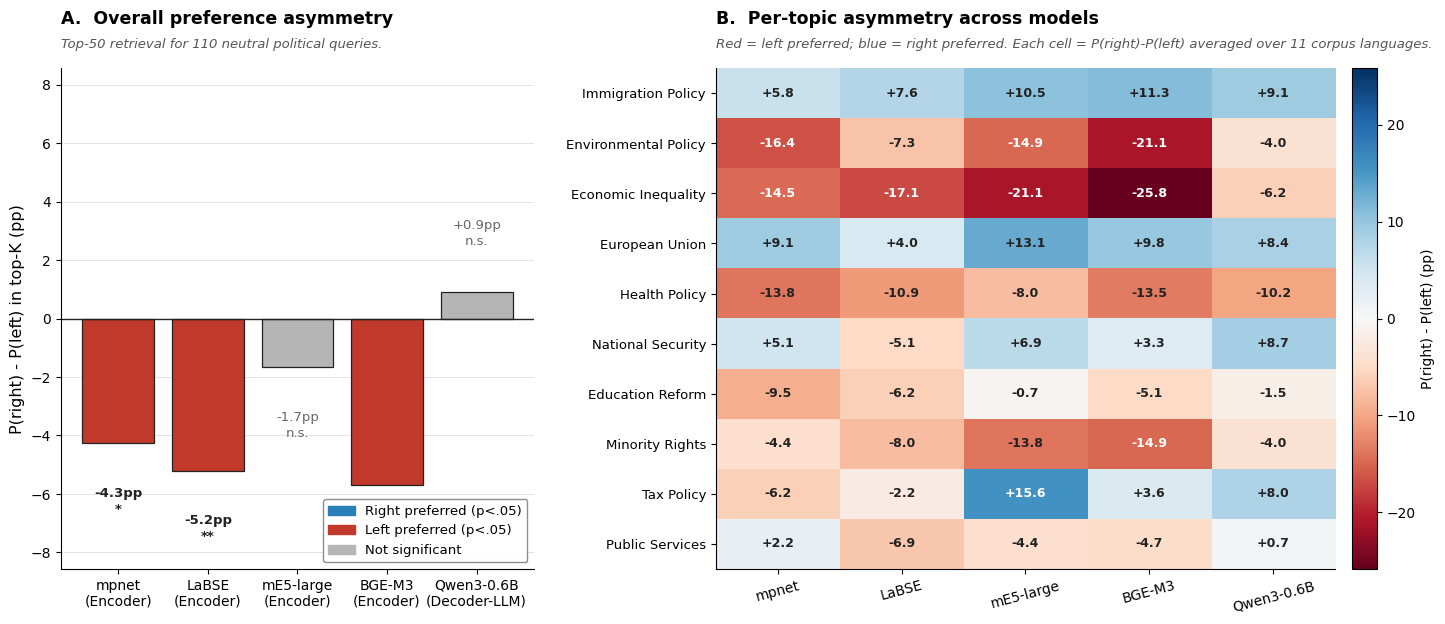


Plot saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/preference_test.png


In [ ]:
# ============================================================
# Cell 10: Preference Test - neutral political queries
# ============================================================
# For each politically neutral query in each of 11 corpus languages,
# I retrieve the top-K nearest speeches and ask: are they
# disproportionately left-leaning or right-leaning?
#
# This goes beyond WEAT (semantic-level evaluation) to a
# *behavioral* / *downstream* test: when a user asks a neutral
# political question, which ideological side does the model
# surface?
#
# Restart-safe: re-mounts Drive and reloads embeddings if
# kernel was reset.

import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')


# ── Restart-safe setup ────────────────────────────────────
NEEDS_RELOAD = ('all_embeddings' not in globals())

if NEEDS_RELOAD:
    print('Reloading (kernel was reset)...')
    from google.colab import drive
    try: drive.mount('/content/drive')
    except: drive.mount('/content/drive', force_remount=True)


DRIVE_ROOT = '/content/drive/MyDrive/parlamint_thesis'
EMBED_DIR  = f'{DRIVE_ROOT}/embeddings/q1_12c'
RESULTS    = f'{DRIVE_ROOT}/results/q1_12c'
os.makedirs(RESULTS, exist_ok=True)

MODELS = ['paraphrase-mpnet','LaBSE','mE5-large','BGE-M3','Qwen3-Embedding-0.6B']
COUNTRIES = {'NL':'Netherlands','BE':'Belgium','ES':'Spain','PT':'Portugal',
             'DK':'Denmark','FI':'Finland','CZ':'Czechia','HR':'Croatia',
             'SI':'Slovenia','AT':'Austria','RS':'Serbia','UA':'Ukraine'}
MODEL_ARCH = {'paraphrase-mpnet':'Encoder','LaBSE':'Encoder',
              'mE5-large':'Encoder','BGE-M3':'Encoder',
              'Qwen3-Embedding-0.6B':'Decoder-LLM'}
SHORT_NAMES = {'paraphrase-mpnet':'mpnet','LaBSE':'LaBSE',
               'mE5-large':'mE5-large','BGE-M3':'BGE-M3',
               'Qwen3-Embedding-0.6B':'Qwen3-0.6B'}
COUNTRY_TO_LANG = {'NL':'nl','BE':'nl','ES':'es','PT':'pt','DK':'da','FI':'fi',
                   'CZ':'cs','HR':'hr','SI':'sl','AT':'de','RS':'sr','UA':'uk'}
SEED = 42
K_TOP = 50


def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'


def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))


# Load
if NEEDS_RELOAD:
    df = pd.read_csv(f'{EMBED_DIR}/metadata.csv', low_memory=False).reset_index(drop=True)
    all_embeddings = {}
    for name in MODELS:
        all_embeddings[name] = np.load(
            f'{EMBED_DIR}/embeddings_{name}.npy').astype(np.float32)
        print(f'  Loaded {name}: {all_embeddings[name].shape}')


# ── Encode neutral queries ────────────────────────────────
# To create QUERY embeddings, we need a sentence encoder. We
# load each model fresh for queries only (queries are tiny).
import torch
from sentence_transformers import SentenceTransformer

MODEL_IDS = {
    'paraphrase-mpnet':       'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
    'LaBSE':                  'sentence-transformers/LaBSE',
    'mE5-large':              'intfloat/multilingual-e5-large',
    'BGE-M3':                 'BAAI/bge-m3',
    'Qwen3-Embedding-0.6B':   'Qwen/Qwen3-Embedding-0.6B',
}


# ── Neutral political queries: 10 topics × 11 corpus languages ───
# Topics deliberately chosen to be politically neutral: any
# elected representative across the spectrum would address
# them, but framings might differ. The query itself uses no
# loaded language.
TOPICS = [
    'immigration_policy', 'environmental_policy', 'economic_inequality',
    'european_union',     'health_policy',         'national_security',
    'education_reform',   'minority_rights',       'tax_policy',
    'public_services',
]

NEUTRAL_QUERIES = {
    # English
    'en': {
        'immigration_policy':    'What should be our country\'s immigration policy?',
        'environmental_policy':  'How should we address environmental challenges?',
        'economic_inequality':   'How can we reduce economic inequality?',
        'european_union':        'What should our relationship with the European Union be?',
        'health_policy':         'How should we organize public health care?',
        'national_security':     'How can we improve national security?',
        'education_reform':      'How should we reform the education system?',
        'minority_rights':       'How should we protect minority rights?',
        'tax_policy':            'What should our tax policy look like?',
        'public_services':       'How should we deliver public services?',
    },
    'nl': {
        'immigration_policy':    'Wat zou ons immigratiebeleid moeten zijn?',
        'environmental_policy':  'Hoe moeten we milieuproblemen aanpakken?',
        'economic_inequality':   'Hoe kunnen we economische ongelijkheid verminderen?',
        'european_union':        'Wat zou onze relatie met de Europese Unie moeten zijn?',
        'health_policy':         'Hoe moeten we de openbare gezondheidszorg organiseren?',
        'national_security':     'Hoe kunnen we de nationale veiligheid verbeteren?',
        'education_reform':      'Hoe moeten we het onderwijssysteem hervormen?',
        'minority_rights':       'Hoe moeten we de rechten van minderheden beschermen?',
        'tax_policy':            'Hoe zou ons belastingbeleid eruit moeten zien?',
        'public_services':       'Hoe moeten we openbare diensten leveren?',
    },
    'es': {
        'immigration_policy':    '¿Cuál debería ser la política migratoria de nuestro país?',
        'environmental_policy':  '¿Cómo debemos abordar los desafíos ambientales?',
        'economic_inequality':   '¿Cómo podemos reducir la desigualdad económica?',
        'european_union':        '¿Cuál debería ser nuestra relación con la Unión Europea?',
        'health_policy':         '¿Cómo debemos organizar la sanidad pública?',
        'national_security':     '¿Cómo podemos mejorar la seguridad nacional?',
        'education_reform':      '¿Cómo debemos reformar el sistema educativo?',
        'minority_rights':       '¿Cómo debemos proteger los derechos de las minorías?',
        'tax_policy':            '¿Cómo debería ser nuestra política fiscal?',
        'public_services':       '¿Cómo debemos prestar los servicios públicos?',
    },
    'pt': {
        'immigration_policy':    'Qual deve ser a política de imigração do nosso país?',
        'environmental_policy':  'Como devemos enfrentar os desafios ambientais?',
        'economic_inequality':   'Como podemos reduzir a desigualdade económica?',
        'european_union':        'Qual deve ser a nossa relação com a União Europeia?',
        'health_policy':         'Como devemos organizar os cuidados de saúde públicos?',
        'national_security':     'Como podemos melhorar a segurança nacional?',
        'education_reform':      'Como devemos reformar o sistema de ensino?',
        'minority_rights':       'Como devemos proteger os direitos das minorias?',
        'tax_policy':            'Qual deve ser a nossa política fiscal?',
        'public_services':       'Como devemos prestar serviços públicos?',
    },
    'da': {
        'immigration_policy':    'Hvad skal vores lands indvandringspolitik være?',
        'environmental_policy':  'Hvordan skal vi tackle miljøudfordringer?',
        'economic_inequality':   'Hvordan kan vi reducere økonomisk ulighed?',
        'european_union':        'Hvad skal vores forhold til Den Europæiske Union være?',
        'health_policy':         'Hvordan skal vi organisere den offentlige sundhedspleje?',
        'national_security':     'Hvordan kan vi forbedre den nationale sikkerhed?',
        'education_reform':      'Hvordan skal vi reformere uddannelsessystemet?',
        'minority_rights':       'Hvordan skal vi beskytte mindretals rettigheder?',
        'tax_policy':            'Hvordan skal vores skattepolitik se ud?',
        'public_services':       'Hvordan skal vi levere offentlige tjenester?',
    },
    'fi': {
        'immigration_policy':    'Mikä pitäisi olla maamme maahanmuuttopolitiikka?',
        'environmental_policy':  'Miten meidän pitäisi vastata ympäristöhaasteisiin?',
        'economic_inequality':   'Miten voimme vähentää taloudellista eriarvoisuutta?',
        'european_union':        'Mikä pitäisi olla suhteemme Euroopan unioniin?',
        'health_policy':         'Miten meidän pitäisi järjestää julkinen terveydenhuolto?',
        'national_security':     'Miten voimme parantaa kansallista turvallisuutta?',
        'education_reform':      'Miten meidän pitäisi uudistaa koulutusjärjestelmää?',
        'minority_rights':       'Miten meidän pitäisi suojella vähemmistöjen oikeuksia?',
        'tax_policy':            'Millainen verotuspolitiikkamme pitäisi olla?',
        'public_services':       'Miten meidän pitäisi tarjota julkisia palveluja?',
    },
    'cs': {
        'immigration_policy':    'Jaká by měla být imigrační politika naší země?',
        'environmental_policy':  'Jak bychom měli řešit ekologické výzvy?',
        'economic_inequality':   'Jak můžeme snížit ekonomickou nerovnost?',
        'european_union':        'Jaký by měl být náš vztah k Evropské unii?',
        'health_policy':         'Jak bychom měli organizovat veřejné zdravotnictví?',
        'national_security':     'Jak můžeme zlepšit národní bezpečnost?',
        'education_reform':      'Jak bychom měli reformovat vzdělávací systém?',
        'minority_rights':       'Jak bychom měli chránit práva menšin?',
        'tax_policy':            'Jak by měla vypadat naše daňová politika?',
        'public_services':       'Jak bychom měli poskytovat veřejné služby?',
    },
    'hr': {
        'immigration_policy':    'Kakva bi trebala biti imigracijska politika naše zemlje?',
        'environmental_policy':  'Kako bismo trebali rješavati ekološke izazove?',
        'economic_inequality':   'Kako možemo smanjiti ekonomsku nejednakost?',
        'european_union':        'Kakav bi trebao biti naš odnos s Europskom unijom?',
        'health_policy':         'Kako bismo trebali organizirati javno zdravstvo?',
        'national_security':     'Kako možemo poboljšati nacionalnu sigurnost?',
        'education_reform':      'Kako bismo trebali reformirati obrazovni sustav?',
        'minority_rights':       'Kako bismo trebali zaštititi prava manjina?',
        'tax_policy':            'Kako bi trebala izgledati naša porezna politika?',
        'public_services':       'Kako bismo trebali pružati javne usluge?',
    },
    'sl': {
        'immigration_policy':    'Kakšna naj bo priseljenska politika naše države?',
        'environmental_policy':  'Kako naj se spopademo z okoljskimi izzivi?',
        'economic_inequality':   'Kako lahko zmanjšamo ekonomsko neenakost?',
        'european_union':        'Kakšen naj bo naš odnos z Evropsko unijo?',
        'health_policy':         'Kako naj organiziramo javno zdravstvo?',
        'national_security':     'Kako lahko izboljšamo nacionalno varnost?',
        'education_reform':      'Kako naj reformiramo izobraževalni sistem?',
        'minority_rights':       'Kako naj zaščitimo pravice manjšin?',
        'tax_policy':            'Kakšna naj bo naša davčna politika?',
        'public_services':       'Kako naj zagotavljamo javne storitve?',
    },
    'de': {
        'immigration_policy':    'Wie soll die Einwanderungspolitik unseres Landes aussehen?',
        'environmental_policy':  'Wie sollten wir Umweltherausforderungen angehen?',
        'economic_inequality':   'Wie können wir wirtschaftliche Ungleichheit verringern?',
        'european_union':        'Wie soll unser Verhältnis zur Europäischen Union sein?',
        'health_policy':         'Wie sollten wir die öffentliche Gesundheitsversorgung organisieren?',
        'national_security':     'Wie können wir die nationale Sicherheit verbessern?',
        'education_reform':      'Wie sollten wir das Bildungssystem reformieren?',
        'minority_rights':       'Wie sollten wir Minderheitenrechte schützen?',
        'tax_policy':            'Wie sollte unsere Steuerpolitik aussehen?',
        'public_services':       'Wie sollten wir öffentliche Dienste erbringen?',
    },
    'sr': {
        'immigration_policy':    'Kakva treba da bude imigraciona politika naše zemlje?',
        'environmental_policy':  'Kako treba da rešavamo ekološke izazove?',
        'economic_inequality':   'Kako možemo smanjiti ekonomsku nejednakost?',
        'european_union':        'Kakav treba da bude naš odnos sa Evropskom unijom?',
        'health_policy':         'Kako treba da organizujemo javno zdravstvo?',
        'national_security':     'Kako možemo poboljšati nacionalnu bezbednost?',
        'education_reform':      'Kako treba da reformišemo obrazovni sistem?',
        'minority_rights':       'Kako treba da zaštitimo prava manjina?',
        'tax_policy':            'Kakva treba da bude naša poreska politika?',
        'public_services':       'Kako treba da pružamo javne usluge?',
    },
    'uk': {
        'immigration_policy':    'Якою має бути імміграційна політика нашої країни?',
        'environmental_policy':  'Як ми маємо вирішувати екологічні виклики?',
        'economic_inequality':   'Як ми можемо зменшити економічну нерівність?',
        'european_union':        'Якими мають бути наші відносини з Європейським Союзом?',
        'health_policy':         'Як ми маємо організувати публічну охорону здоров\'я?',
        'national_security':     'Як ми можемо покращити національну безпеку?',
        'education_reform':      'Як ми маємо реформувати систему освіти?',
        'minority_rights':       'Як ми маємо захищати права меншин?',
        'tax_policy':            'Якою має бути наша податкова політика?',
        'public_services':       'Як ми маємо надавати державні послуги?',
    },
}

# English is defined for prefix/style consistency but does not map to
# any corpus country, so it is dropped before query construction.
NEUTRAL_QUERIES.pop('en', None)

# Sanity check: 10 topics × 11 corpus languages = 110 evaluated queries
print(f'Topics: {len(TOPICS)}, Languages: {len(NEUTRAL_QUERIES)}')
for lang, q in NEUTRAL_QUERIES.items():
    if len(q) != len(TOPICS):
        print(f'  WARNING: {lang} has {len(q)} queries (expected {len(TOPICS)})')


print(f'\n{"="*60}\nPreference Test - Neutral Political Queries\n{"="*60}')
print(f'10 topics × 11 corpus languages = 110 evaluated queries, top-K={K_TOP}')


# Build query texts per model (with model-specific prefixes)
def build_query_text(model_name, base_query):
    if model_name == 'mE5-large':
        return f'query: {base_query}'
    if model_name == 'Qwen3-Embedding-0.6B':
        return (f'Instruct: Retrieve semantically similar parliamentary speeches.\n'
                f'Query: {base_query}')
    return base_query


# ── Main loop ─────────────────────────────────────────────
preference_results = {}

for name in MODELS:
    print(f'\n[{name}] loading + encoding 110 queries...')
    model = SentenceTransformer(
        MODEL_IDS[name], trust_remote_code=True, device='cuda',
        model_kwargs={'torch_dtype': torch.float16} if name == 'Qwen3-Embedding-0.6B' else {}
    )
    model.max_seq_length = 512

    # Encode all queries
    query_records = []
    query_texts = []
    for lang, qs in NEUTRAL_QUERIES.items():
        for topic in TOPICS:
            query_records.append({'lang': lang, 'topic': topic})
            query_texts.append(build_query_text(name, qs[topic]))
    q_embs = model.encode(query_texts, batch_size=32,
                          normalize_embeddings=True,
                          convert_to_numpy=True,
                          show_progress_bar=False).astype(np.float32)
    del model; gc.collect(); torch.cuda.empty_cache()

    # Match each query to country pool (its own language) + global pool
    emb = all_embeddings[name]
    country_idx_map = {c: np.where(df['country'].values == c)[0] for c in COUNTRIES}
    lang_to_countries = {}
    for c, l in COUNTRY_TO_LANG.items():
        lang_to_countries.setdefault(l, []).append(c)

    rows = []
    for qi, rec in enumerate(query_records):
        lang = rec['lang']; topic = rec['topic']
        q_vec = q_embs[qi]

        # Pool: all speeches from countries speaking this language
        target_countries = lang_to_countries.get(lang, [])
        if not target_countries: continue
        pool_idx = np.concatenate([country_idx_map[c] for c in target_countries])

        sims = emb[pool_idx] @ q_vec
        top = np.argsort(sims)[::-1][:K_TOP]
        retrieved = df.iloc[pool_idx[top]]

        n_left  = (retrieved['orient_lr'] == 'left').sum()
        n_right = (retrieved['orient_lr'] == 'right').sum()
        rows.append({
            'model': name, 'lang': lang, 'topic': topic,
            'n_left': int(n_left), 'n_right': int(n_right),
            'p_left':  n_left  / (n_left + n_right) if (n_left+n_right) > 0 else 0.5,
            'p_right': n_right / (n_left + n_right) if (n_left+n_right) > 0 else 0.5,
        })

    pref_df = pd.DataFrame(rows)
    preference_results[name] = pref_df

    overall_left = pref_df['p_left'].mean()
    overall_right = pref_df['p_right'].mean()
    h = cohens_h(overall_right, overall_left)
    # Permutation: shuffle ideology labels and recompute
    rng = np.random.default_rng(SEED)
    obs_diff = overall_right - overall_left
    null = np.empty(2000)
    for k in range(2000):
        flip = rng.random(len(pref_df)) < 0.5
        n_l = np.where(flip, pref_df['n_right'].values, pref_df['n_left'].values)
        n_r = np.where(flip, pref_df['n_left'].values, pref_df['n_right'].values)
        totals = n_l + n_r
        p_l_shuf = (n_l / np.where(totals > 0, totals, 1)).mean()
        p_r_shuf = (n_r / np.where(totals > 0, totals, 1)).mean()
        null[k] = p_r_shuf - p_l_shuf
    p_perm = (np.abs(null) >= np.abs(obs_diff)).mean()

    print(f'  Overall: P(left)={overall_left:.3f}  '
          f'P(right)={overall_right:.3f}  '
          f'Δ={obs_diff:+.3f}  h={h:+.3f}  p={p_perm:.4f} {stars(p_perm)}')

    # ────────────────────────────────────────────────────────
    # Per-topic breakdown (averaged over 11 corpus languages).
    # Printed so the per-topic numbers cited in the write-up
    # are reproducible from the cell output, not only the figure.
    # ────────────────────────────────────────────────────────
    print(f'  Per-topic R-L (pp):')
    for topic in TOPICS:
        sub = pref_df[pref_df['topic'] == topic]
        t_diff = (sub['p_right'] - sub['p_left']).mean() * 100
        rng_t = np.random.default_rng(SEED)
        null_t = np.empty(1000)
        for k in range(1000):
            flip = rng_t.random(len(sub)) < 0.5
            n_l = np.where(flip, sub['n_right'].values, sub['n_left'].values)
            n_r = np.where(flip, sub['n_left'].values, sub['n_right'].values)
            tot = n_l + n_r
            null_t[k] = ((n_r / np.where(tot > 0, tot, 1)).mean()
                         - (n_l / np.where(tot > 0, tot, 1)).mean())
        t_p = (np.abs(null_t) >= np.abs(t_diff / 100)).mean()
        print(f'    {topic:22} {t_diff:+6.1f}pp  p={t_p:.4f} {stars(t_p)}')


# Concatenate and save
all_pref = pd.concat([pref.assign(model=name)
                      for name, pref in preference_results.items()],
                     ignore_index=True)
all_pref.to_csv(f'{RESULTS}/preference_test.csv', index=False)
print(f'\nSaved: {RESULTS}/preference_test.csv')


# ════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════

PREF_COLORS = {'left':'#C0392B','right':'#2980B9','ns':'#B5B5B5'}


# Panel A - Overall right-share by model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6.5),
                                gridspec_kw={'width_ratios': [1, 1.4],
                                             'wspace': 0.32})
xs = np.arange(len(MODELS))

overall_diffs, overall_ps = [], []
for name in MODELS:
    pref = preference_results[name]
    diff = pref['p_right'].mean() - pref['p_left'].mean()
    overall_diffs.append(diff)
    # quick null test
    rng = np.random.default_rng(SEED)
    null = np.empty(1000)
    for k in range(1000):
        flip = rng.random(len(pref)) < 0.5
        n_l = np.where(flip, pref['n_right'].values, pref['n_left'].values)
        n_r = np.where(flip, pref['n_left'].values, pref['n_right'].values)
        totals = n_l + n_r
        null[k] = ((n_r / np.where(totals > 0, totals, 1)).mean()
                   - (n_l / np.where(totals > 0, totals, 1)).mean())
    overall_ps.append((np.abs(null) >= np.abs(diff)).mean())

overall_diffs = np.array(overall_diffs)
overall_ps = np.array(overall_ps)

def col(d, p):
    if p >= 0.05: return PREF_COLORS['ns']
    return PREF_COLORS['right'] if d > 0 else PREF_COLORS['left']

ax1.bar(xs, overall_diffs * 100,
        color=[col(d, p) for d, p in zip(overall_diffs, overall_ps)],
        edgecolor='#222', linewidth=0.9)
ax1.axhline(0, color='#222', linewidth=1)
ax1.set_xticks(xs)
ax1.set_xticklabels([f'{SHORT_NAMES[m]}\n({MODEL_ARCH[m]})' for m in MODELS],
                    fontsize=10)
ax1.set_ylabel('P(right) - P(left) in top-K (pp)', fontsize=11.5)
ax1.set_title('A.  Overall preference asymmetry',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax1.text(0.0, 1.04,
         f'Top-{K_TOP} retrieval for 110 neutral political queries.',
         transform=ax1.transAxes, fontsize=9.5, style='italic', color='#555')

y_range = max(abs(overall_diffs.min()), abs(overall_diffs.max())) * 100 * 1.5
ax1.set_ylim(-y_range, y_range)

for i, (d, p) in enumerate(zip(overall_diffs, overall_ps)):
    sig = stars(p) if p < 0.05 else 'n.s.'
    y_off = 1.5 if d >= 0 else -1.5
    va = 'bottom' if d >= 0 else 'top'
    weight = 'bold' if p < 0.05 else 'normal'
    color = '#222' if p < 0.05 else '#666'
    ax1.text(i, d*100 + y_off, f'{d*100:+.1f}pp\n{sig}',
             ha='center', va=va, fontsize=9.5,
             fontweight=weight, color=color, linespacing=1.3)
ax1.legend(handles=[
    mpatches.Patch(color=PREF_COLORS['right'], label='Right preferred (p<.05)'),
    mpatches.Patch(color=PREF_COLORS['left'],  label='Left preferred (p<.05)'),
    mpatches.Patch(color=PREF_COLORS['ns'],    label='Not significant'),
], loc='lower right', fontsize=9.5, framealpha=0.96, edgecolor='#888')
ax1.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)


# Panel B - Per-topic asymmetry (heatmap, all models)
ax2.set_title('B.  Per-topic asymmetry across models',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax2.text(0.0, 1.04,
         'Red = left preferred; blue = right preferred. '
         'Each cell = P(right)-P(left) averaged over 11 corpus languages.',
         transform=ax2.transAxes, fontsize=9.5, style='italic', color='#555')

heat = np.zeros((len(TOPICS), len(MODELS)))
for j, name in enumerate(MODELS):
    pref = preference_results[name]
    for i, topic in enumerate(TOPICS):
        sub = pref[pref['topic'] == topic]
        heat[i, j] = (sub['p_right'] - sub['p_left']).mean() * 100

vmax = max(abs(heat.min()), abs(heat.max()))
im = ax2.imshow(heat, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')

ax2.set_xticks(np.arange(len(MODELS)))
ax2.set_xticklabels([SHORT_NAMES[m] for m in MODELS], fontsize=10, rotation=15)
ax2.set_yticks(np.arange(len(TOPICS)))
ax2.set_yticklabels([t.replace('_', ' ').title() for t in TOPICS], fontsize=9.5)

for i in range(len(TOPICS)):
    for j in range(len(MODELS)):
        val = heat[i, j]
        text_color = 'white' if abs(val) > vmax * 0.55 else '#222'
        ax2.text(j, i, f'{val:+.1f}', ha='center', va='center',
                 fontsize=9, color=text_color, fontweight='bold')

plt.colorbar(im, ax=ax2, fraction=0.04, pad=0.025,
             label='P(right) - P(left) (pp)')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.savefig(f'{RESULTS}/preference_test.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nPlot saved: {RESULTS}/preference_test.png')

### What the result shows: a topic-dependent pattern, not a clean overall bias

**Panel A (overall asymmetry).** Three of the five models retrieve left-leaning content more often for these queries: paraphrase-mpnet (−4.3pp, p = 0.0375), LaBSE (−5.2pp, p = 0.0030) and BGE-M3 (−5.7pp, p = 0.0065). Two models are null: mE5-large (−1.7pp, p = 0.4875) and Qwen3-Embedding-0.6B (+0.9pp, p = 0.6745). So the overall picture is partial. It is not the case that all encoders lean one way and the decoder the other, which is the pattern S1 showed. Here, three encoders lean left significantly (paraphrase-mpnet, LaBSE, BGE-M3), one encoder is essentially null (mE5-large), and the decoder is null (Qwen3-Embedding-0.6B). The decoder being null instead of right-leaning is itself worth noting, because it does not reproduce the S1 decoder result on this behavioural measure.

**Panel B (per-topic breakdown).** This is the part that actually carries the interpretation, and it shows that the overall numbers in Panel A are averages over topics that point in opposite directions. Two topics point right in all five models, although most individual model-level effects are not statistically significant: immigration policy (+5.8 to +11.3pp across the five models, significant only in Qwen3) and European Union (+4.0 to +13.1pp, significant only in mE5-large). Three topics point left in all five models, and here the significance pattern is stronger: environmental policy (−4.0 to −21.1pp, significant in two of five models), economic inequality (−6.2 to −25.8pp, significant in four of five), and health policy (−8.0 to −13.8pp, significant in four of five). Education reform also points left in all five models, though by smaller and mostly non-significant margins (−0.7 to −9.5pp). The remaining topics are more mixed: national security points right in four of five models, minority rights points left in all five but reaches significance only in the larger models, and tax policy is genuinely split (mpnet and LaBSE lean left, the other three lean right).

The reading of this is that the overall asymmetry in Panel A is not a stable property of the models. It is the residual of strong, consistent, but opposing topic-level effects. When environmental and economic-inequality queries pull left hard, and immigration and EU queries pull right hard, the overall average depends entirely on how those topics happen to weight against each other in the query set. If I had chosen twelve topics instead of ten, or weighted them differently, the Panel A numbers would move. The Panel B numbers would not.

This connects directly to what Ceron et al. (2024) reported for generative LLMs: political leaning in these systems is topic-specific, not global, and a model can sit left on one issue and right on another. The preference test reproduces that finding for multilingual sentence embeddings. The consistency of the topic-level directions is striking. Immigration and EU lean right in 5 of 5 models; environment, inequality and health lean left in 5 of 5 models. That cross-model agreement at the topic level is a much stronger and more interesting result than any single overall asymmetry number. The topic-controlled retrieval cell later in the notebook follows up on this directly, although it works with a narrower and more strictly defined set of five topics (immigration, economy, environment, security, social welfare) instead of all ten topics used here, because those five could be tagged consistently across the eleven distinct languages of the twelve countries with acceptable precision.

One methodological caveat stays attached to all of this, following from the discussion of "neutrality" in the intro. The topic-level directions could reflect genuine ideological encoding, or they could reflect the fact that the vocabulary of "environmental policy" simply overlaps more with left-coded parliamentary language and the vocabulary of "immigration policy" overlaps more with right-coded language, in most of the twelve party systems, independently of any model bias. This test on its own cannot separate those two explanations. What it can establish is that the pattern is consistent across five independently developed embedding models and two architectures, which makes a pure tokenisation artefact less likely but does not rule out a corpus-level vocabulary association. The regression at the end of the notebook, which includes topic fixed effects, is the place where this gets a partial answer.

## Topic-controlled bias

The preference test in the previous cell showed that the overall retrieval asymmetry is the residual of opposing topic-level effects. That test used short artificial queries. This cell makes the same point with the actual parliamentary speeches and a controlled design, which makes it the stronger version of the argument.

The procedure has two steps. First, every speech is assigned to a study topic by mapping ParlaMint's own CAP (Comparative Agendas Project) topic annotations onto five broader policy areas: immigration, economy, environment, security, social welfare, or none. The 200 raw multilingual label variants in the corpus collapse onto the 21 standard CAP categories, and those are then grouped into the five study topics following standard CAP practice. A little under three fifths of the corpus (57.8 percent, 42,005 speeches) receives one of the five study-topic labels; the remaining 42.2 percent falls into the residual "none" bucket (Civil Rights, Agriculture, Transportation, Technology, Foreign Trade, International Affairs, Government Operations, Public Lands, Culture, and Mix / Other) and is excluded from this cell. The topic distribution across the tagged corpus is reasonably spread, with economy the largest tagged topic (20.0 percent of the full corpus) and environment the smallest (5.7 percent), and within each topic the left/right and coalition/opposition shares stay close to 50 percent, so the topic mapping does not introduce a new imbalance.

Second, within each topic separately, I re-run two of the earlier tests. Test A is the ideology classification from S2, run inside each topic, which tells me whether ideology stays distinguishable once topic is held constant. Test B is the S1 cross-country retrieval asymmetry, run inside each topic, which tells me whether the left/right retrieval gap depends on which policy area the speeches are about.

This design directly addresses the topic-confound question. If the S1 retrieval asymmetry were a single global property of each model, it would look roughly the same inside every topic. If it is topic-dependent, the per-topic retrieval results will diverge, and the overall S1 number will turn out to be an average over heterogeneous topic-level effects.

In [ ]:
# Quick metadata inspection used during corpus preparation.
# Verifies that the metadata.csv and the underlying speech CSV
# share the keys needed for the analysis pipeline.
import pandas as pd

ROOT = '/content/drive/MyDrive/parlamint_thesis'

meta = pd.read_csv(f'{ROOT}/embeddings/q1_12c/metadata.csv', nrows=3)
print("metadata.csv columns:")
print(list(meta.columns))
print()
print("-" * 60)

txt = pd.read_csv(f'{ROOT}/data/processed/sample_balanced_12c_q1.csv', nrows=3)
print("sample_balanced_12c_q1.csv columns:")
print(list(txt.columns))

metadata.csv columns:
['ID', 'country', 'Party_status', 'orient_lr', 'orientation_broad', 'Party_orientation', 'Speaker_ID', 'Speaker_gender', 'Date', 'Subcorpus', 'Topic', 'text_len']

------------------------------------------------------------
sample_balanced_12c_q1.csv columns:
['ID', 'text', 'Text_ID', 'Title', 'Date', 'Body', 'Term', 'Session', 'Meeting', 'Sitting', 'Agenda', 'Subcorpus', 'Lang', 'Speaker_role', 'Speaker_MP', 'Speaker_minister', 'Speaker_party', 'Speaker_party_name', 'Party_status', 'Party_orientation', 'Speaker_ID', 'Speaker_name', 'Speaker_gender', 'Speaker_birth', 'Topic', 'country', 'country_name', 'orientation_broad', 'text_len', 'orient_lr']


In [ ]:
# Sanity check: how many distinct raw topic strings exist in the corpus.
# This is the input to the RAW_TO_CAP mapping in the next code cell.
print(f"Topic column unique values: {df['Topic'].nunique()}")
print(f"\nTop 30 topic values by frequency:")
print(df['Topic'].value_counts().head(30))
print(f"\nMissing/empty topics: {df['Topic'].isna().sum() + (df['Topic'] == '').sum()}")

Topic column unique values: 200

Top 30 topic values by frequency:
Topic
Makroekonomija               2088
Mix                          1917
Macroeconomics               1385
Aktivnosti vlade             1366
Wet en Misdaad               1323
Gezondheid                   1114
Zakon i kriminal              960
Health                        874
Education                     872
Buitenlandse Zaken            872
Macroeconomía                 859
Makrotalous                   843
Vladne operacije              802
Građanska prava               762
Labor                         757
Social Welfare                756
Macro-economie                739
Derechos civiles              709
Makroöknomie                  705
Operaties van de regering     691
Werk                          690
Діяльність уряду              681
Domaća trgovina               671
Ostalo                        658
Law and Crime                 649
Мішана категорія              638
Government Operations         637
Макроекон

In [ ]:
# Quick inventory of the raw multilingual topic labels in ParlaMint.
# # Used during corpus preparation to inspect the raw multilingual topic labels
# before mapping them onto the 21 standard CAP categories.
# Shown here for the top 30 most frequent labels only; the full list is
# in the saved CSV and is not needed for the analysis itself.
topic_counts = df['Topic'].value_counts()
print(f"Total unique topics: {len(topic_counts)}")
print(f"Total speeches: {len(df)}\n")
print("Top 30 raw topic labels by frequency:")
for topic, n in topic_counts.head(30).items():
    print(f"  {topic:<40} {n:>6}")
print(f"  ... and {len(topic_counts) - 30} more (all mapped via RAW_TO_CAP below).")

Total unique topics: 200
Total speeches: 72720

Top 30 raw topic labels by frequency:
  Makroekonomija                             2088
  Mix                                        1917
  Macroeconomics                             1385
  Aktivnosti vlade                           1366
  Wet en Misdaad                             1323
  Gezondheid                                 1114
  Zakon i kriminal                            960
  Health                                      874
  Education                                   872
  Buitenlandse Zaken                          872
  Macroeconomía                               859
  Makrotalous                                 843
  Vladne operacije                            802
  Građanska prava                             762
  Labor                                       757
  Social Welfare                              756
  Macro-economie                              739
  Derechos civiles                            709
  Makroöknomie

Mapping ParlaMint topic labels
Raw labels mapped to CAP: 72,720 / 72,720

Study-topic distribution (from CAP mapping):
Topic              N        %      % left   % Coal  
--------------------------------------------------
immigration        2304     3.2    43.8     45.8    
economy            14562    20.0   50.8     48.9    
environment        4146     5.7    53.3     49.9    
security           7760     10.7   46.1     52.0    
social_welfare     13233    18.2   52.9     51.6    
none               30715    42.2   49.4     49.6    

Test A: Per-topic ideology classification

  [immigration]  n=2304
    paraphrase-mpnet         ideo_acc=54.68±3.09%
    LaBSE                    ideo_acc=56.92±3.14%
    mE5-large                ideo_acc=55.38±5.03%
    BGE-M3                   ideo_acc=56.43±2.78%
    Qwen3-Embedding-0.6B     ideo_acc=55.76±3.15%

  [economy]  n=14562
    paraphrase-mpnet         ideo_acc=53.83±1.24%
    LaBSE                    ideo_acc=55.27±1.42%
    mE5-large      

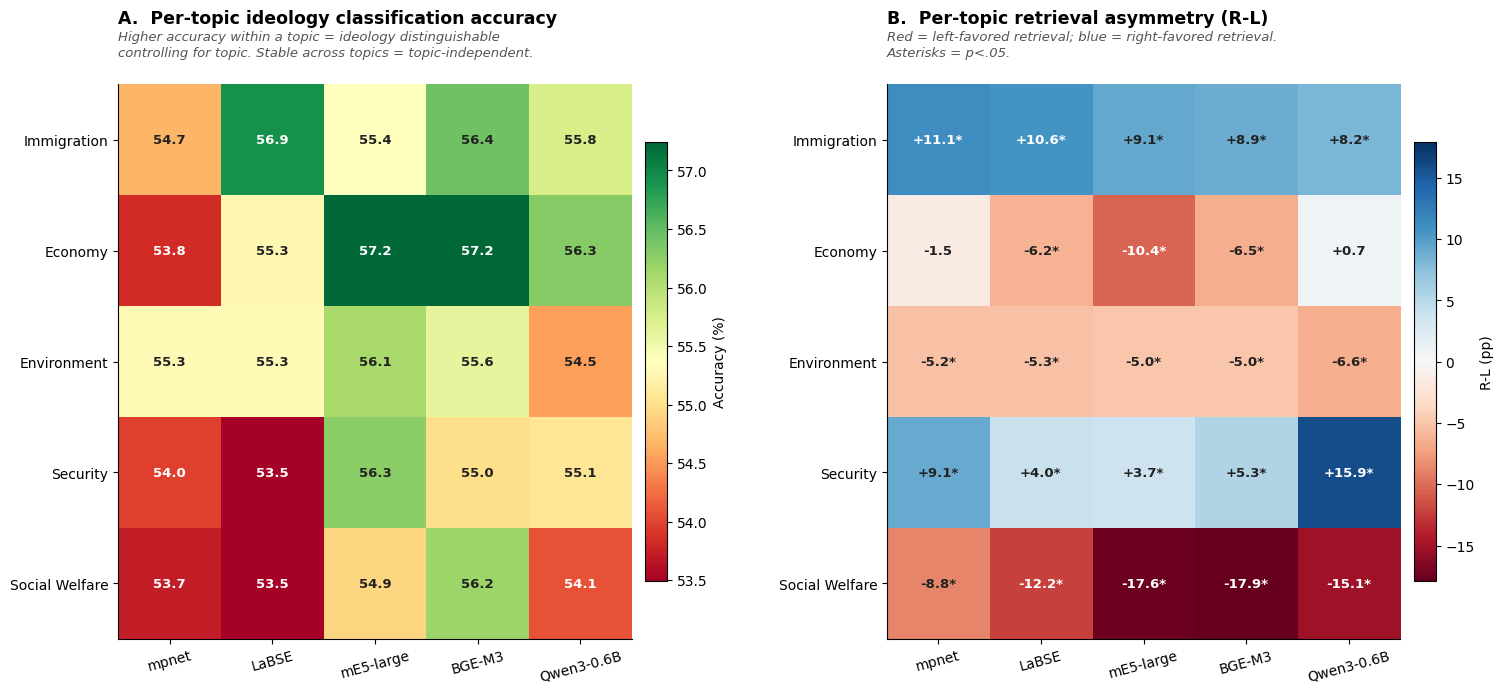


Saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/topic_controlled.png


In [ ]:
# ============================================================
# Cell 11: Topic-Controlled Bias Analysis
#          (using ParlaMint's own CAP annotation)
# ============================================================
# Concern: Earlier findings (S1, S2) might reflect TOPIC
# composition instead of ideology.
#
# This cell uses ParlaMint 5.0's built-in topic annotation,
# which follows the Comparative Agendas Project (CAP) coding
# scheme (21 standard policy categories). Each speech is
# already labelled in the corpus, in its source language.
#
# Step 1: Normalise the 200 raw label variants from the 12
#         country corpora (in 11 distinct languages, with
#         spelling drift) onto the 21 CAP English labels.
# Step 2: Group the 21 CAP labels into 5 study topics:
#         immigration, economy, environment, security, social_welfare.
# Step 3: Run two within-topic tests:
#         A. Ideology classification accuracy
#         B. Cross-country retrieval asymmetry (R - L)
#
# Restart-safe: re-mounts Drive and reloads embeddings if
# the kernel was reset.

import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score
from scipy import stats
warnings.filterwarnings('ignore')


# ── Restart-safe ──────────────────────────────────────────
NEEDS_RELOAD = ('all_embeddings' not in globals())
if NEEDS_RELOAD:
    print('Reloading (kernel was reset)...')
    from google.colab import drive
    try: drive.mount('/content/drive')
    except: drive.mount('/content/drive', force_remount=True)

DRIVE_ROOT = '/content/drive/MyDrive/parlamint_thesis'
EMBED_DIR  = f'{DRIVE_ROOT}/embeddings/q1_12c'
RESULTS    = f'{DRIVE_ROOT}/results/q1_12c'
os.makedirs(RESULTS, exist_ok=True)

TC_MODELS = ['paraphrase-mpnet','LaBSE','mE5-large','BGE-M3','Qwen3-Embedding-0.6B']
TC_COUNTRIES = {'NL':'Netherlands','BE':'Belgium','ES':'Spain','PT':'Portugal',
                'DK':'Denmark','FI':'Finland','CZ':'Czechia','HR':'Croatia',
                'SI':'Slovenia','AT':'Austria','RS':'Serbia','UA':'Ukraine'}
TC_MODEL_ARCH = {'paraphrase-mpnet':'Encoder','LaBSE':'Encoder',
                 'mE5-large':'Encoder','BGE-M3':'Encoder',
                 'Qwen3-Embedding-0.6B':'Decoder-LLM'}
TC_SHORT_NAMES = {'paraphrase-mpnet':'mpnet','LaBSE':'LaBSE',
                  'mE5-large':'mE5-large','BGE-M3':'BGE-M3',
                  'Qwen3-Embedding-0.6B':'Qwen3-0.6B'}
TC_SEED = 42
TC_K = 50

def tc_stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

if NEEDS_RELOAD:
    df = pd.read_csv(f'{EMBED_DIR}/metadata.csv',
                      low_memory=False).reset_index(drop=True)
    all_embeddings = {}
    for name_ in TC_MODELS:
        all_embeddings[name_] = np.load(
            f'{EMBED_DIR}/embeddings_{name_}.npy').astype(np.float32)
        print(f'  Loaded {name_}: {all_embeddings[name_].shape}')


# ════════════════════════════════════════════════════════════
# Step 1: Map 200 raw multilingual labels to 21 CAP categories
# ════════════════════════════════════════════════════════════
# CAP English standard category names: Macroeconomics, Civil
# Rights, Health, Agriculture, Labor, Education, Environment,
# Energy, Immigration, Transportation, Law and Crime, Social
# Welfare, Housing, Domestic Commerce, Defense, Technology,
# Foreign Trade, International Affairs, Government Operations,
# Public Lands, Culture, plus Mix / Other (residual).

RAW_TO_CAP = {
    # Macroeconomics
    'Macroeconomics': 'Macroeconomics',
    'Makroekonomija': 'Macroeconomics',
    'Macroeconomía': 'Macroeconomics',
    'Makrotalous': 'Macroeconomics',
    'Macro-economie': 'Macroeconomics',
    'Makroöknomie': 'Macroeconomics',
    'Makroekonomika': 'Macroeconomics',
    'Макроекономіка': 'Macroeconomics',

    # Civil Rights
    'Civil Rights': 'Civil Rights',
    'Građanska prava': 'Civil Rights',
    'Derechos civiles': 'Civil Rights',
    'Burgerrechten': 'Civil Rights',
    'Bürgerrechte': 'Civil Rights',
    'Državljanske pravice': 'Civil Rights',
    'Kansalaisoikeudet': 'Civil Rights',
    'Lidská práva': 'Civil Rights',
    'Громадянські права': 'Civil Rights',

    # Health
    'Health': 'Health',
    'Gezondheid': 'Health',
    'Sanidad': 'Health',
    'Zdravlje': 'Health',
    'Terveys': 'Health',
    'Zdraví': 'Health',
    'Zdravje': 'Health',
    'Gesundheid': 'Health',
    'Gesundheit': 'Health',
    'Охорона здоров’я': 'Health',

    # Agriculture
    'Agriculture': 'Agriculture',
    'Poljoprivreda': 'Agriculture',
    'Agricultura': 'Agriculture',
    'Landbouw': 'Agriculture',
    'Maatalous': 'Agriculture',
    'Zemědělství': 'Agriculture',
    'Landwirtschaft': 'Agriculture',
    'Poljedelstvo': 'Agriculture',
    'Сільське господарство': 'Agriculture',

    # Labor
    'Labor': 'Labor',
    'Werk': 'Labor',
    'Trabajo': 'Labor',
    'Rad': 'Labor',
    'Työ': 'Labor',
    'Arbeit': 'Labor',
    'Delo': 'Labor',
    'Zaměstnání': 'Labor',
    'Праця': 'Labor',

    # Education
    'Education': 'Education',
    'Onderwijs': 'Education',
    'Educación': 'Education',
    'Obrazovanje': 'Education',
    'Koulutus': 'Education',
    'Bildung': 'Education',
    'Izobraževanje': 'Education',
    'Vzdělání': 'Education',
    'Освіта': 'Education',

    # Environment
    'Environment': 'Environment',
    'Milieu': 'Environment',
    'Medio ambiente': 'Environment',
    'Okoliš': 'Environment',
    'Ympäristö': 'Environment',
    'Umwelt': 'Environment',
    'Okolje': 'Environment',
    'Životní prostředí': 'Environment',
    'Životna sredina': 'Environment',
    'Довкілля': 'Environment',

    # Energy
    'Energy': 'Energy',
    'Energie': 'Energy',
    'Energía': 'Energy',
    'Energija': 'Energy',
    'Energia': 'Energy',
    'Energuie': 'Energy',
    'Енергетика': 'Energy',

    # Immigration
    'Immigration': 'Immigration',
    'Immigratie': 'Immigration',
    'Inmigración': 'Immigration',
    'Imigracija': 'Immigration',
    'Maahanmuutto': 'Immigration',
    'Einwanderung': 'Immigration',
    'Priseljevanje': 'Immigration',
    'Imigrace': 'Immigration',
    'Імміграція': 'Immigration',

    # Transportation
    'Transportation': 'Transportation',
    'Verkeer en transport': 'Transportation',
    'Transportes': 'Transportation',
    'Transport': 'Transportation',
    'Prijevoz': 'Transportation',
    'Liikenne': 'Transportation',
    'Transportwesen': 'Transportation',
    'Doprava': 'Transportation',
    'Prevoz': 'Transportation',
    'Транспорт': 'Transportation',

    # Law and Crime
    'Law and Crime': 'Law and Crime',
    'Wet en Misdaad': 'Law and Crime',
    'Zakon i kriminal': 'Law and Crime',
    'Legal y penal': 'Law and Crime',
    'Laki ja rikollisuus': 'Law and Crime',
    'Recht und Kriminalität': 'Law and Crime',
    'Pravo in kriminal': 'Law and Crime',
    'Právo a kriminalita': 'Law and Crime',
    'Правопорядок і боротьба зі злочинністю': 'Law and Crime',

    # Social Welfare
    'Social Welfare': 'Social Welfare',
    'Sociaal welzijn': 'Social Welfare',
    'Bienestar social': 'Social Welfare',
    'Socijala': 'Social Welfare',
    'Sosiaalihuolto': 'Social Welfare',
    'Sozialwesen': 'Social Welfare',
    'Socialno varstvo': 'Social Welfare',
    'Sociální zabezpečení': 'Social Welfare',
    'Socijalna pitanja': 'Social Welfare',
    'Соціальне забезпечення': 'Social Welfare',

    # Housing
    'Housing': 'Housing',
    'Huisvesting': 'Housing',
    'Vivienda': 'Housing',
    'Stambena pitanja': 'Housing',
    'Asuminen': 'Housing',
    'Stanovanjska politika': 'Housing',
    'Bydlení': 'Housing',
    'Житлове господарство': 'Housing',

    # Domestic Commerce
    'Domestic Commerce': 'Domestic Commerce',
    'Binnenlandse Handel': 'Domestic Commerce',
    'Comercio interior': 'Domestic Commerce',
    'Domaća trgovina': 'Domestic Commerce',
    'Kotimaankauppa': 'Domestic Commerce',
    'Binnenhandel': 'Domestic Commerce',
    'Domácí obchod': 'Domestic Commerce',
    'Domača trgovina': 'Domestic Commerce',
    'Внутрішня торгівля': 'Domestic Commerce',

    # Defense
    'Defense': 'Defense',
    'Defensie': 'Defense',
    'Defensa': 'Defense',
    'Obrana': 'Defense',
    'Puolustus': 'Defense',
    'Landesverteidigung': 'Defense',
    'Obramba': 'Defense',
    'Оборона': 'Defense',

    # Technology
    'Technology': 'Technology',
    'Technologie': 'Technology',
    'Tecnología': 'Technology',
    'Tehnologija': 'Technology',
    'Teknologia': 'Technology',
    'Технології': 'Technology',

    # Foreign Trade
    'Foreign Trade': 'Foreign Trade',
    'Buitenlandse Handel': 'Foreign Trade',
    'Comercio exterior': 'Foreign Trade',
    'Međunarodna trgovina': 'Foreign Trade',
    'Ulkomaankauppa': 'Foreign Trade',
    'Handel': 'Foreign Trade',
    'Zahraniční obchod': 'Foreign Trade',
    'Zunanja trgovina': 'Foreign Trade',
    'Зовнішня торгівля': 'Foreign Trade',

    # International Affairs
    'International Affairs': 'International Affairs',
    'Buitenlandse Zaken': 'International Affairs',
    'Asuntos internacionales': 'International Affairs',
    'Međunarodni odnosi': 'International Affairs',
    'Kansainväliset asiat': 'International Affairs',
    'internationale Angelegenheiten': 'International Affairs',
    'Mednarodni odnosi': 'International Affairs',
    'Mezinárodní záležitosti': 'International Affairs',
    'Міжнародні відносини': 'International Affairs',

    # Government Operations
    'Government Operations': 'Government Operations',
    'Aktivnosti vlade': 'Government Operations',
    'Operaciones gubernamentales': 'Government Operations',
    'Vladne operacije': 'Government Operations',
    'Operaties van de regering': 'Government Operations',
    'Valtionhallinnon toiminnot': 'Government Operations',
    'Regierungsgeschäfte': 'Government Operations',
    'Veřejná správa': 'Government Operations',
    'Діяльність уряду': 'Government Operations',

    # Public Lands
    'Public Lands': 'Public Lands',
    'Javna dobra': 'Public Lands',
    'Javne površine': 'Public Lands',
    'Javna zemljišča': 'Public Lands',
    'Julkiset maat': 'Public Lands',
    'Öffentlicher Grund und Boden': 'Public Lands',
    'Openbare grond': 'Public Lands',
    'Terreno público': 'Public Lands',
    'Veřejné území': 'Public Lands',
    'Землі у державній власності': 'Public Lands',

    # Culture
    'Culture': 'Culture',
    'Cultuur': 'Culture',
    'Cultura': 'Culture',
    'Kultura': 'Culture',
    'Kulttuuri': 'Culture',
    'Kultur': 'Culture',
    'Культура': 'Culture',

    # Mix / Other (residual, not used for analysis)
    'Mix': 'Other',
    'Miješano': 'Other',
    'Mešavina': 'Other',
    'Mešano': 'Other',
    'Smíšený': 'Other',
    'Sekalainen': 'Other',
    'Gemischt': 'Other',
    'Мішана категорія': 'Other',
    'Ostalo': 'Other',
    'Ostatní': 'Other',
    'Overig': 'Other',
    'Otros': 'Other',
    'Varios': 'Other',
    'Anderes': 'Other',
    'Інше': 'Other',
    'Other': 'Other',
    'Muu': 'Other',
}

# ════════════════════════════════════════════════════════════
# Step 2: Group CAP categories into 5 study topics
# ════════════════════════════════════════════════════════════
# Choice rationale:
#   immigration       = Immigration (single CAP category)
#   economy           = Macroeconomics + Labor + Domestic Commerce
#   environment       = Environment + Energy
#   security          = Defense + Law and Crime
#   social_welfare    = Social Welfare + Health + Housing + Education
# Categories deliberately NOT grouped (kept residual, ignored
# in the topic-controlled analysis): Civil Rights, Agriculture,
# Transportation, Technology, Foreign Trade, International
# Affairs, Government Operations, Public Lands, Culture, Other.
# These are excluded because they do not map cleanly onto the
# 5 study topics motivated by the literature.

CAP_TO_STUDY_TOPIC = {
    'Immigration':           'immigration',
    'Macroeconomics':        'economy',
    'Labor':                 'economy',
    'Domestic Commerce':     'economy',
    'Environment':           'environment',
    'Energy':                'environment',
    'Defense':               'security',
    'Law and Crime':         'security',
    'Social Welfare':        'social_welfare',
    'Health':                'social_welfare',
    'Housing':               'social_welfare',
    'Education':             'social_welfare',
}
TC_TOPICS = ['immigration', 'economy', 'environment', 'security', 'social_welfare']


# ════════════════════════════════════════════════════════════
# Apply the mapping
# ════════════════════════════════════════════════════════════
print(f'{"="*60}\nMapping ParlaMint topic labels\n{"="*60}')
raw_topics = df['Topic'].astype(str).values
cap_topics = np.array([RAW_TO_CAP.get(t, 'UNMAPPED') for t in raw_topics])
study_topics = np.array([CAP_TO_STUDY_TOPIC.get(c, 'none') for c in cap_topics])

n_unmapped = (cap_topics == 'UNMAPPED').sum()
print(f'Raw labels mapped to CAP: {(cap_topics != "UNMAPPED").sum():,} / {len(df):,}')
if n_unmapped > 0:
    print(f'WARNING: {n_unmapped} speeches have unmapped topic labels.')
    unmapped_sample = pd.Series(raw_topics[cap_topics == 'UNMAPPED']).value_counts().head(20)
    print('Top unmapped values:')
    for k, v in unmapped_sample.items():
        print(f'  {k!r}: {v}')

# Distribution of the 5 study topics
print('\nStudy-topic distribution (from CAP mapping):')
print(f'{"Topic":<18} {"N":<8} {"%":<6} {"% left":<8} {"% Coal":<8}')
print('-' * 50)
for t_name in TC_TOPICS + ['none']:
    sub = df[study_topics == t_name]
    if len(sub) == 0: continue
    pct_l = (sub['orient_lr'] == 'left').mean() * 100
    pct_c = (sub['Party_status'] == 'Coalition').mean() * 100
    print(f'{t_name:<18} {len(sub):<8} {len(sub)/len(df)*100:<6.1f} '
          f'{pct_l:<8.1f} {pct_c:<8.1f}')


# ════════════════════════════════════════════════════════════
# Test A: Per-topic ideology classification
# ════════════════════════════════════════════════════════════
print(f'\n{"="*60}\nTest A: Per-topic ideology classification\n{"="*60}')

def tc_cv_classify(emb, y_str, groups, n_splits=5, pca_dim=128, seed=42):
    y = pd.Categorical(y_str).codes
    if len(set(y)) < 2 or len(set(groups)) < n_splits + 1:
        return None
    skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True,
                                 random_state=seed)
    accs = []
    for tr, te in skf.split(emb, y, groups=groups):
        pca_n = min(pca_dim, len(tr)-1, emb.shape[1])
        pca = PCA(n_components=pca_n, random_state=seed)
        Xtr = pca.fit_transform(emb[tr])
        Xte = pca.transform(emb[te])
        clf = LogisticRegression(max_iter=2000, C=1.0,
                                  random_state=seed, solver='lbfgs')
        clf.fit(Xtr, y[tr])
        accs.append(accuracy_score(y[te], clf.predict(Xte)))
    return float(np.mean(accs)), float(np.std(accs))


tc_class_results = {nm: {} for nm in TC_MODELS}
for t_name in TC_TOPICS:
    mask = (study_topics == t_name)
    n = mask.sum()
    if n < 500:
        print(f'  Skipping {t_name} (n={n})')
        continue
    sub_y = df.loc[mask, 'orient_lr'].values
    sub_g = df.loc[mask, 'Speaker_ID'].values
    print(f'\n  [{t_name}]  n={n}')
    for nm, emb in all_embeddings.items():
        r = tc_cv_classify(emb[mask], sub_y, sub_g)
        if r is None:
            tc_class_results[nm][t_name] = (np.nan, np.nan)
            continue
        acc_m, acc_s = r
        tc_class_results[nm][t_name] = (acc_m, acc_s)
        print(f'    {nm:<24} ideo_acc={acc_m*100:5.2f}±{acc_s*100:.2f}%')


# ════════════════════════════════════════════════════════════
# Test B: Per-topic retrieval asymmetry
# ════════════════════════════════════════════════════════════
print(f'\n{"="*60}\nTest B: Per-topic retrieval asymmetry\n{"="*60}')

def tc_retrieval(emb, df_in, mask_topic, src, tgt, lr, K=TC_K):
    src_mask = (df_in['country'].values == src) & mask_topic & \
                (df_in['orient_lr'].values == lr)
    if src_mask.sum() < 30: return None
    centroid = emb[src_mask].mean(axis=0)
    centroid /= np.linalg.norm(centroid)
    tgt_mask = (df_in['country'].values == tgt) & mask_topic
    if tgt_mask.sum() < K: return None
    tgt_idx_arr = np.where(tgt_mask)[0]
    tgt_lr = df_in.loc[tgt_mask, 'orient_lr'].values
    sims = emb[tgt_idx_arr] @ centroid
    top = np.argsort(sims)[::-1][:K]
    return (tgt_lr[top] == lr).mean()


tc_retr_results = {nm: {} for nm in TC_MODELS}
for t_name in TC_TOPICS:
    mask = (study_topics == t_name)
    n = mask.sum()
    if n < 500: continue
    print(f'\n  [{t_name}]  n={n}')
    for nm, emb in all_embeddings.items():
        diffs = []
        for src in TC_COUNTRIES:
            for tgt in TC_COUNTRIES:
                if src == tgt: continue
                hL = tc_retrieval(emb, df, mask, src, tgt, 'left',  TC_K)
                hR = tc_retrieval(emb, df, mask, src, tgt, 'right', TC_K)
                if hL is None or hR is None: continue
                diffs.append(hR - hL)
        if not diffs: continue
        diffs = np.array(diffs)
        mean_diff = float(diffs.mean())
        t_stat, p_val = stats.ttest_1samp(diffs, 0.0)
        d_eff = mean_diff / diffs.std(ddof=1) if diffs.std(ddof=1) > 0 else 0.0
        tc_retr_results[nm][t_name] = (mean_diff, float(p_val), float(d_eff),
                                         len(diffs))
        print(f'    {nm:<24}  R-L={mean_diff*100:+.2f}pp  '
              f'p={p_val:.4f} {tc_stars(p_val)}  d={d_eff:+.2f}  '
              f'(n_pairs={len(diffs)})')


# ── Save CSV ──────────────────────────────────────────────
csv_rows = []
for nm in TC_MODELS:
    for t_name in TC_TOPICS:
        cls = tc_class_results[nm].get(t_name, (np.nan, np.nan))
        ret = tc_retr_results[nm].get(t_name, (np.nan, np.nan, np.nan, 0))
        csv_rows.append({
            'model': nm, 'topic': t_name,
            'ideo_acc': cls[0], 'ideo_acc_sd': cls[1],
            'retrieval_diff': ret[0], 'retrieval_p': ret[1],
            'retrieval_d': ret[2], 'n_pairs': ret[3],
        })
pd.DataFrame(csv_rows).to_csv(f'{RESULTS}/topic_controlled.csv', index=False)
print(f'\nSaved: {RESULTS}/topic_controlled.csv')


# ════════════════════════════════════════════════════════════
# PLOT
# ════════════════════════════════════════════════════════════
# Convention: red = left-favoured, blue = right-favoured.
print('\nPlotting...')

n_t = len(TC_TOPICS); n_m = len(TC_MODELS)
heat_acc = np.full((n_t, n_m), np.nan)
heat_ret = np.full((n_t, n_m), np.nan)
heat_p   = np.full((n_t, n_m), 1.0)
for j, nm in enumerate(TC_MODELS):
    for i, t_name in enumerate(TC_TOPICS):
        cls = tc_class_results[nm].get(t_name, (np.nan, np.nan))
        ret = tc_retr_results[nm].get(t_name, (np.nan, np.nan, np.nan, 0))
        if not np.isnan(cls[0]): heat_acc[i, j] = cls[0] * 100
        if not np.isnan(ret[0]):
            heat_ret[i, j] = ret[0] * 100
            heat_p[i, j]   = ret[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7.2),
                                 gridspec_kw={'width_ratios': [1, 1],
                                              'wspace': 0.40})

# Panel A: accuracy (no left/right semantics -> green colormap)
vmin = float(np.nanmin(heat_acc))
vmax = float(np.nanmax(heat_acc))
im1 = ax1.imshow(heat_acc, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
ax1.set_xticks(np.arange(n_m))
ax1.set_xticklabels([TC_SHORT_NAMES[m] for m in TC_MODELS],
                     fontsize=10, rotation=15)
ax1.set_yticks(np.arange(n_t))
ax1.set_yticklabels([t.replace('_', ' ').title() for t in TC_TOPICS],
                     fontsize=10)
ax1.set_title('A.  Per-topic ideology classification accuracy',
                fontsize=12.5, fontweight='bold', loc='left', pad=44)
ax1.text(0.0, 1.05,
          'Higher accuracy within a topic = ideology distinguishable\n'
          'controlling for topic. Stable across topics = topic-independent.',
          transform=ax1.transAxes, fontsize=9.5, style='italic',
          color='#555', linespacing=1.35)
for i in range(n_t):
    for j in range(n_m):
        v = heat_acc[i, j]
        if np.isnan(v): continue
        norm_v = (v - vmin) / (vmax - vmin) if vmax > vmin else 0.5
        tcol = 'white' if (norm_v < 0.20 or norm_v > 0.85) else '#222'
        ax1.text(j, i, f'{v:.1f}', ha='center', va='center',
                  fontsize=9.5, color=tcol, fontweight='bold')
plt.colorbar(im1, ax=ax1, fraction=0.04, pad=0.025, label='Accuracy (%)')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Panel B: retrieval asymmetry (red = left, blue = right)
abs_max = float(np.nanmax(np.abs(heat_ret)))
im2 = ax2.imshow(heat_ret, cmap='RdBu', vmin=-abs_max, vmax=abs_max,
                  aspect='auto')
ax2.set_xticks(np.arange(n_m))
ax2.set_xticklabels([TC_SHORT_NAMES[m] for m in TC_MODELS],
                     fontsize=10, rotation=15)
ax2.set_yticks(np.arange(n_t))
ax2.set_yticklabels([t.replace('_', ' ').title() for t in TC_TOPICS],
                     fontsize=10)
ax2.set_title('B.  Per-topic retrieval asymmetry (R-L)',
                fontsize=12.5, fontweight='bold', loc='left', pad=44)
ax2.text(0.0, 1.05,
          'Red = left-favored retrieval; blue = right-favored retrieval.\n'
          'Asterisks = p<.05.',
          transform=ax2.transAxes, fontsize=9.5, style='italic',
          color='#555', linespacing=1.35)
for i in range(n_t):
    for j in range(n_m):
        v = heat_ret[i, j]
        p_val = heat_p[i, j]
        if np.isnan(v): continue
        tcol = 'white' if abs(v) > abs_max * 0.55 else '#222'
        sig_mark = '*' if p_val < 0.05 else ''
        ax2.text(j, i, f'{v:+.1f}{sig_mark}',
                  ha='center', va='center',
                  fontsize=9.5, color=tcol, fontweight='bold')
plt.colorbar(im2, ax=ax2, fraction=0.04, pad=0.025, label='R-L (pp)')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.savefig(f'{RESULTS}/topic_controlled.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nSaved: {RESULTS}/topic_controlled.png')

### What the result shows: the headline finding of the second half of the analysis

**Test A (ideology stays distinguishable within every topic).** Once topic is held constant by the ParlaMint CAP annotation, ideology remains recoverable inside every one of the five topics and every one of the five models. Accuracies sit between 53.49 and 57.24 percent, all above chance, all in the same mid-50s band that the global S2 result occupied. The highest accuracies fall in the economy topic (BGE-M3 57.24 percent, mE5-large 57.22 percent), and the lowest in social welfare (LaBSE 53.49, mpnet 53.72) and environment (Qwen3 54.54, mpnet 55.30). The fact that ideology stays distinguishable inside every topic means the S2 ideology signal is not an artefact of topic composition: speeches on the same policy area, from opposite sides, still separate. This is the necessary control before the retrieval result in Test B can be interpreted at all.

**Test B (the retrieval asymmetry is strongly topic-dependent).** Test B carries the core finding of this cell. The per-topic retrieval asymmetries are not a scaled-down copy of the global S1 result; they diverge sharply by topic, and the divergence is consistent across all five models.

Two topics show a left-favoured retrieval asymmetry in every one of the five models, with paired p-values below 0.001 throughout. Social welfare runs from −8.80pp (mpnet) to −17.91pp (BGE-M3), with Cohen's d between −0.55 and −0.90, which is in Cohen's medium-to-large range, and they hold for the decoder as cleanly as for the encoders (Qwen3: −15.12pp, d = −0.90). Environment runs from −4.97pp (BGE-M3) to −6.56pp (Qwen3), with d between −0.21 and −0.35, which is smaller in magnitude than welfare but again consistent in direction across every model. On these two policy areas there is no encoder-decoder split at all. Every encoder and the decoder lean the same way, and they lean hard.

Two topics show the opposite direction with the same cross-model consistency. Immigration leans right in all five models, with magnitudes from +8.16pp (Qwen3) to +11.07pp (mpnet) and every single result significant at p < 0.001. This is the place where the encoder-decoder split that S1 first suggested actually *dissolves* once topic is controlled; on immigration specifically, the four encoders and the decoder all lean the same way, and there is no architectural divide to interpret. Security shows a right-favoured asymmetry across every model as well, ranging from +3.70pp (mE5-large) to +15.86pp (Qwen3), with the Qwen3 effect reaching d = +0.78. All five models are significant at p < 0.05, with Qwen3 and mpnet at p < 0.001.

Economy is the one topic where the cross-model picture fragments. The two larger encoders (mE5-large at −10.36pp, BGE-M3 at −6.52pp) lean left significantly, LaBSE leans left at smaller magnitude (−6.24pp, p < 0.001), and mpnet and Qwen3 return essentially null effects (−1.48pp and +0.73pp, both non-significant). Economy is a heterogeneous CAP grouping (macroeconomics, labour, domestic commerce) and this is the topic where that heterogeneity is most visible in the results.

The implication reframes the S1 result. The global S1 finding (four encoders left, one decoder right) is real as an average, but it is an average over topics that behave very differently. The encoder-decoder separation does not hold across the board: on environment and welfare every model leans left, on immigration and security every model leans right, and the architectural divide that was visible at the global level disappears once policy area is fixed. So the cleaner statement, the one this cell supports, is that **retrieval bias in multilingual sentence embeddings is primarily topic-dependent, and the encoder-decoder difference seen in S1 emerges from the way different topics are weighted in a balanced sample, not from a stable architectural property.**

The use of ParlaMint's own CAP annotation strengthens the topic-controlled interpretation considerably, because the topic labels are part of the corpus, not researcher-generated. CAP is a peer-reviewed comparative-politics coding scheme and the annotation is part of the corpus by design; the topic groupings (Environment + Energy, Social Welfare + Health + Housing + Education, Macroeconomics + Labour + Domestic Commerce, Immigration alone, Defense + Law and Crime) follow standard CAP practice instead of my own judgement about what counts as which topic. If I had to single out one finding from the second half of the analysis, it would be this one. It is consistent with what Ceron et al. (2024) found for generative LLMs, where political leaning was topic-specific, not global, and it answers the topic-confound concern that Rheault and Cochrane (2020) raised in a more general form. The fact that environment and social welfare lean left in 5 of 5 models with medium-to-large effect sizes, and that immigration and security lean right in 5 of 5 models, regardless of provider or architecture, is a stronger and more transferable result than the global S1 asymmetry on its own.


## Multivariate regression: the independent effect of each predictor

Every test up to this point has looked at one factor at a time. S1 isolated ideology through cross-country retrieval. S2 compared ideology against role. S4 controlled for gender by matching. The topic-controlled cell held topic constant. Each of these is a single-confound control. The problem is that ideology, role, gender, country and topic are all entangled in real parliamentary data, and controlling for them one at a time leaves open the possibility that what looks like an ideology effect is actually some combination of the others.

This cell puts all of them into one model. The dependent variable is constructed at the speech level: for each speech I compute its similarity to the right centroid and to the left centroid of every *other* country, and take the difference, so a positive value means the speech sits closer to right-leaning content cross-lingually (the sign convention matches every other bias row in the master summary, where negative reads as left-favouring). The predictors are ideology (left = 1), role (coalition = 1) and gender (female = 1), and the model additionally includes country fixed effects and topic fixed effects. The country fixed effects absorb every stable difference between national parliaments. The topic fixed effects absorb the topic-dependent pattern that the previous two cells documented. Standard errors are HC3 heteroscedasticity-robust, which Long and Ervin (2000) recommend as the default for unbalanced groups and which is the appropriate choice here because the cells, although balanced by design, produce residuals with unequal variance once the fixed effects are partialled out.

The regression runs on the 41,998 speeches that were both topic-tagged and have a known speaker gender (the corpus has 42,005 topic-tagged speeches in total; seven have no gender label and are excluded so that the gender predictor can enter the model). The question for each model is simple: after country and topic are absorbed by fixed effects, and with role and gender in the model as competing predictors, does ideology still have an independent, statistically significant effect on where a speech sits in the embedding space?


Re-mounting Drive...
Mounted at /content/drive

Loading metadata and embeddings...
  metadata: (72720, 12)
  Loaded paraphrase-mpnet: (72720, 768)  (223 MB)
  Loaded LaBSE: (72720, 768)  (223 MB)
  Loaded mE5-large: (72720, 1024)  (298 MB)
  Loaded BGE-M3: (72720, 1024)  (298 MB)
  Loaded Qwen3-Embedding-0.6B: (72720, 1024)  (149 MB)

Multiple Regression

Tagging topics with CAP mapping...
Topic distribution: {'none': 30715, 'economy': 14562, 'social_welfare': 13233, 'security': 7760, 'environment': 4146, 'immigration': 2304}

Building regression frame...
  Rows after filter: 41,998 (was 72,720)

Running regressions (HC3 robust SE)
DV = (sim to R centroid) − (sim to L centroid), leave-own-country-out.
A negative ideology_left coefficient is the expected "signal present"
result: left-leaning speeches sit closer to L centroids, so R-L is lower.


[paraphrase-mpnet]  R²=0.3270  N=41,998
  ideology_left    β=-0.00034  SE=0.00003  p=8.09e-24 ***
  role_coal        β=-0.00005  SE=0.00003  p=

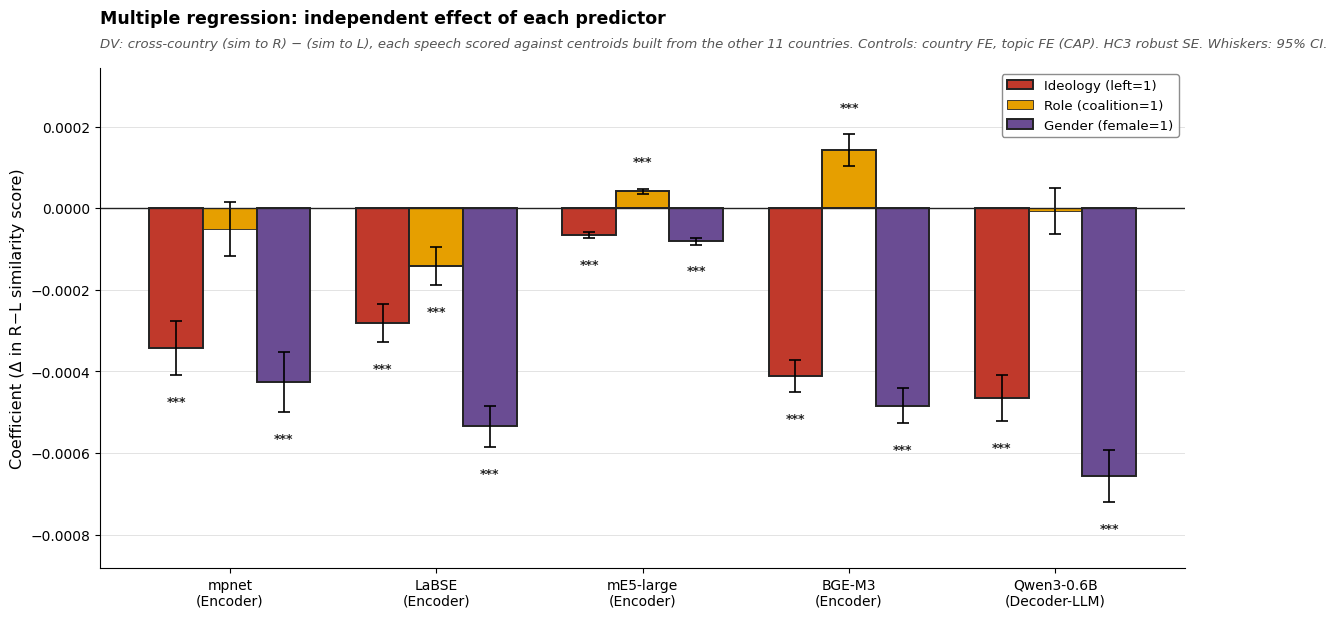


Plot saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/regression.png

R² SUMMARY
Model                    R²         N         
--------------------------------------------------
paraphrase-mpnet         0.3270     41,998    
LaBSE                    0.3310     41,998    
mE5-large                0.4846     41,998    
BGE-M3                   0.2940     41,998    
Qwen3-Embedding-0.6B     0.4108     41,998    


In [4]:
# ============================================================
# Cell 12: Multiple Regression - isolate independent effects
#
# ============================================================
# Each effect (ideology, role, gender) was tested in isolation
# in earlier cells. The multiple regression tests them ALL
# IN ONE MODEL: holding the others fixed, what is the unique
# contribution of each?
#
# Dependent variable: for each speech, (sim to R centroid) −
# (sim to L centroid), where the two centroids are built from
# every OTHER country (leave-own-country-out). This matches
# the cross-country design used in S1 and prevents a speech
# from being scored against a centroid it itself contributed
# to. Positive = closer to right; negative = closer to left.
#
# Sign convention matches every other bias row in the master
# summary: negative coefficient = pulls a speech toward the
# left side, positive coefficient = pulls it toward the right.
# A left-leaning speech should therefore produce a NEGATIVE
# ideology coefficient - that is the "ideology signal is real"
# result, not a right-leaning bias.
#
# Predictors: ideology, role, gender, topic (CAP-based, 5
# study topics), country (fixed effects). HC3 robust SE.

import os, gc, time, subprocess, warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')


# ── Force a clean Drive mount ──────────────────────────────
print('Re-mounting Drive...')
subprocess.run(['fusermount', '-u', '/content/drive'], capture_output=True)
time.sleep(2)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
time.sleep(2)


DRIVE_ROOT = '/content/drive/MyDrive/parlamint_thesis'
EMBED_DIR  = f'{DRIVE_ROOT}/embeddings/q1_12c'
RESULTS    = f'{DRIVE_ROOT}/results/q1_12c'
os.makedirs(RESULTS, exist_ok=True)

MODELS = ['paraphrase-mpnet','LaBSE','mE5-large','BGE-M3','Qwen3-Embedding-0.6B']
COUNTRIES = {'NL':'Netherlands','BE':'Belgium','ES':'Spain','PT':'Portugal',
             'DK':'Denmark','FI':'Finland','CZ':'Czechia','HR':'Croatia',
             'SI':'Slovenia','AT':'Austria','RS':'Serbia','UA':'Ukraine'}
MODEL_ARCH = {'paraphrase-mpnet':'Encoder','LaBSE':'Encoder',
              'mE5-large':'Encoder','BGE-M3':'Encoder',
              'Qwen3-Embedding-0.6B':'Decoder-LLM'}
SHORT_NAMES = {'paraphrase-mpnet':'mpnet','LaBSE':'LaBSE',
               'mE5-large':'mE5-large','BGE-M3':'BGE-M3',
               'Qwen3-Embedding-0.6B':'Qwen3-0.6B'}

EXPECTED_SHAPES = {
    'paraphrase-mpnet':     (72720, 768),
    'LaBSE':                (72720, 768),
    'mE5-large':            (72720, 1024),
    'BGE-M3':               (72720, 1024),
    'Qwen3-Embedding-0.6B': (72720, 1024),
}
SEED = 42

def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'


# ── Load metadata + embeddings ─────────────────────────────
print('\nLoading metadata and embeddings...')
df = pd.read_csv(f'{EMBED_DIR}/metadata.csv',
                  low_memory=False).reset_index(drop=True)
print(f'  metadata: {df.shape}')

all_embeddings = {}
for name in MODELS:
    path = f'{EMBED_DIR}/embeddings_{name}.npy'
    size_mb = os.path.getsize(path) / 1e6
    arr = np.load(path).astype(np.float32)
    expected = EXPECTED_SHAPES[name]
    if arr.shape != expected:
        raise RuntimeError(f'{name}: got {arr.shape}, expected {expected}.')
    all_embeddings[name] = arr
    print(f'  Loaded {name}: {arr.shape}  ({size_mb:.0f} MB)')


print(f'\n{"="*60}\nMultiple Regression\n{"="*60}')


# ════════════════════════════════════════════════════════════
# Tag topics using ParlaMint CAP annotation
# ════════════════════════════════════════════════════════════
RAW_TO_CAP = {
    'Macroeconomics':'Macroeconomics','Makroekonomija':'Macroeconomics',
    'Macroeconomía':'Macroeconomics','Makrotalous':'Macroeconomics',
    'Macro-economie':'Macroeconomics','Makroöknomie':'Macroeconomics',
    'Makroekonomika':'Macroeconomics','Макроекономіка':'Macroeconomics',
    'Civil Rights':'Civil Rights','Građanska prava':'Civil Rights',
    'Derechos civiles':'Civil Rights','Burgerrechten':'Civil Rights',
    'Bürgerrechte':'Civil Rights','Državljanske pravice':'Civil Rights',
    'Kansalaisoikeudet':'Civil Rights','Lidská práva':'Civil Rights',
    'Громадянські права':'Civil Rights',
    'Health':'Health','Gezondheid':'Health','Sanidad':'Health',
    'Zdravlje':'Health','Terveys':'Health','Zdraví':'Health',
    'Zdravje':'Health','Gesundheid':'Health','Gesundheit':'Health',
    'Охорона здоров’я':'Health',
    'Agriculture':'Agriculture','Poljoprivreda':'Agriculture',
    'Agricultura':'Agriculture','Landbouw':'Agriculture',
    'Maatalous':'Agriculture','Zemědělství':'Agriculture',
    'Landwirtschaft':'Agriculture','Poljedelstvo':'Agriculture',
    'Сільське господарство':'Agriculture',
    'Labor':'Labor','Werk':'Labor','Trabajo':'Labor','Rad':'Labor',
    'Työ':'Labor','Arbeit':'Labor','Delo':'Labor','Zaměstnání':'Labor',
    'Праця':'Labor',
    'Education':'Education','Onderwijs':'Education','Educación':'Education',
    'Obrazovanje':'Education','Koulutus':'Education','Bildung':'Education',
    'Izobraževanje':'Education','Vzdělání':'Education','Освіта':'Education',
    'Environment':'Environment','Milieu':'Environment',
    'Medio ambiente':'Environment','Okoliš':'Environment',
    'Ympäristö':'Environment','Umwelt':'Environment','Okolje':'Environment',
    'Životní prostředí':'Environment','Životna sredina':'Environment',
    'Довкілля':'Environment',
    'Energy':'Energy','Energie':'Energy','Energía':'Energy',
    'Energija':'Energy','Energia':'Energy','Energuie':'Energy',
    'Енергетика':'Energy',
    'Immigration':'Immigration','Immigratie':'Immigration',
    'Inmigración':'Immigration','Imigracija':'Immigration',
    'Maahanmuutto':'Immigration','Einwanderung':'Immigration',
    'Priseljevanje':'Immigration','Imigrace':'Immigration',
    'Імміграція':'Immigration',
    'Transportation':'Transportation','Verkeer en transport':'Transportation',
    'Transportes':'Transportation','Transport':'Transportation',
    'Prijevoz':'Transportation','Liikenne':'Transportation',
    'Transportwesen':'Transportation','Doprava':'Transportation',
    'Prevoz':'Transportation','Транспорт':'Transportation',
    'Law and Crime':'Law and Crime','Wet en Misdaad':'Law and Crime',
    'Zakon i kriminal':'Law and Crime','Legal y penal':'Law and Crime',
    'Laki ja rikollisuus':'Law and Crime',
    'Recht und Kriminalität':'Law and Crime',
    'Pravo in kriminal':'Law and Crime',
    'Právo a kriminalita':'Law and Crime',
    'Правопорядок і боротьба зі злочинністю':'Law and Crime',
    'Social Welfare':'Social Welfare','Sociaal welzijn':'Social Welfare',
    'Bienestar social':'Social Welfare','Socijala':'Social Welfare',
    'Sosiaalihuolto':'Social Welfare','Sozialwesen':'Social Welfare',
    'Socialno varstvo':'Social Welfare',
    'Sociální zabezpečení':'Social Welfare',
    'Socijalna pitanja':'Social Welfare',
    'Соціальне забезпечення':'Social Welfare',
    'Housing':'Housing','Huisvesting':'Housing','Vivienda':'Housing',
    'Stambena pitanja':'Housing','Asuminen':'Housing',
    'Stanovanjska politika':'Housing','Bydlení':'Housing',
    'Житлове господарство':'Housing',
    'Domestic Commerce':'Domestic Commerce',
    'Binnenlandse Handel':'Domestic Commerce',
    'Comercio interior':'Domestic Commerce',
    'Domaća trgovina':'Domestic Commerce',
    'Kotimaankauppa':'Domestic Commerce','Binnenhandel':'Domestic Commerce',
    'Domácí obchod':'Domestic Commerce','Domača trgovina':'Domestic Commerce',
    'Внутрішня торгівля':'Domestic Commerce',
    'Defense':'Defense','Defensie':'Defense','Defensa':'Defense',
    'Obrana':'Defense','Puolustus':'Defense',
    'Landesverteidigung':'Defense','Obramba':'Defense','Оборона':'Defense',
    'Technology':'Technology','Technologie':'Technology',
    'Tecnología':'Technology','Tehnologija':'Technology',
    'Teknologia':'Technology','Технології':'Technology',
    'Foreign Trade':'Foreign Trade','Buitenlandse Handel':'Foreign Trade',
    'Comercio exterior':'Foreign Trade',
    'Međunarodna trgovina':'Foreign Trade',
    'Ulkomaankauppa':'Foreign Trade','Handel':'Foreign Trade',
    'Zahraniční obchod':'Foreign Trade','Zunanja trgovina':'Foreign Trade',
    'Зовнішня торгівля':'Foreign Trade',
    'International Affairs':'International Affairs',
    'Buitenlandse Zaken':'International Affairs',
    'Asuntos internacionales':'International Affairs',
    'Međunarodni odnosi':'International Affairs',
    'Kansainväliset asiat':'International Affairs',
    'internationale Angelegenheiten':'International Affairs',
    'Mednarodni odnosi':'International Affairs',
    'Mezinárodní záležitosti':'International Affairs',
    'Міжнародні відносини':'International Affairs',
    'Government Operations':'Government Operations',
    'Aktivnosti vlade':'Government Operations',
    'Operaciones gubernamentales':'Government Operations',
    'Vladne operacije':'Government Operations',
    'Operaties van de regering':'Government Operations',
    'Valtionhallinnon toiminnot':'Government Operations',
    'Regierungsgeschäfte':'Government Operations',
    'Veřejná správa':'Government Operations',
    'Діяльність уряду':'Government Operations',
    'Public Lands':'Public Lands','Javna dobra':'Public Lands',
    'Javne površine':'Public Lands','Javna zemljišča':'Public Lands',
    'Julkiset maat':'Public Lands',
    'Öffentlicher Grund und Boden':'Public Lands',
    'Openbare grond':'Public Lands','Terreno público':'Public Lands',
    'Veřejné území':'Public Lands','Землі у державній власності':'Public Lands',
    'Culture':'Culture','Cultuur':'Culture','Cultura':'Culture',
    'Kultura':'Culture','Kulttuuri':'Culture','Kultur':'Culture',
    'Культура':'Culture',
    'Mix':'Other','Miješano':'Other','Mešavina':'Other','Mešano':'Other',
    'Smíšený':'Other','Sekalainen':'Other','Gemischt':'Other',
    'Мішана категорія':'Other','Ostalo':'Other','Ostatní':'Other',
    'Overig':'Other','Otros':'Other','Varios':'Other','Anderes':'Other',
    'Інше':'Other','Other':'Other','Muu':'Other',
}

CAP_TO_STUDY_TOPIC = {
    'Immigration':           'immigration',
    'Macroeconomics':        'economy',
    'Labor':                 'economy',
    'Domestic Commerce':     'economy',
    'Environment':           'environment',
    'Energy':                'environment',
    'Defense':               'security',
    'Law and Crime':         'security',
    'Social Welfare':        'social_welfare',
    'Health':                'social_welfare',
    'Housing':               'social_welfare',
    'Education':             'social_welfare',
}

print('\nTagging topics with CAP mapping...')
raw_topics   = df['Topic'].astype(str).values
cap_topics   = np.array([RAW_TO_CAP.get(t, 'UNMAPPED') for t in raw_topics])
study_topics = np.array([CAP_TO_STUDY_TOPIC.get(c, 'none') for c in cap_topics])
df['topic']  = study_topics
print(f'Topic distribution: {pd.Series(study_topics).value_counts().to_dict()}')


# ════════════════════════════════════════════════════════════
# Build regression frame
# ════════════════════════════════════════════════════════════
def build_right_minus_left_score(emb, df):
    """For each speech, compute (sim to R centroid) - (sim to L centroid),
       both centroids built from every OTHER country
       (leave-own-country-out). Matches the cross-country design in S1
       and the R-minus-L sign convention used in every other bias row of
       the master summary."""
    scores = np.zeros(len(df), dtype=np.float32)
    countries = list(COUNTRIES)
    country_arr = df['country'].values
    orient_arr  = df['orient_lr'].values
    L_sum, L_cnt, R_sum, R_cnt = {}, {}, {}, {}
    for c in countries:
        L_mask = (country_arr == c) & (orient_arr == 'left')
        R_mask = (country_arr == c) & (orient_arr == 'right')
        L_sum[c] = emb[L_mask].sum(axis=0); L_cnt[c] = int(L_mask.sum())
        R_sum[c] = emb[R_mask].sum(axis=0); R_cnt[c] = int(R_mask.sum())
    total_L_sum = sum(L_sum.values()); total_L_cnt = sum(L_cnt.values())
    total_R_sum = sum(R_sum.values()); total_R_cnt = sum(R_cnt.values())
    for c in countries:
        c_idx = np.where(country_arr == c)[0]
        L_c = (total_L_sum - L_sum[c]) / (total_L_cnt - L_cnt[c])
        R_c = (total_R_sum - R_sum[c]) / (total_R_cnt - R_cnt[c])
        L_c = L_c / np.linalg.norm(L_c)
        R_c = R_c / np.linalg.norm(R_c)
        scores[c_idx] = emb[c_idx] @ R_c - emb[c_idx] @ L_c
    return scores


print('\nBuilding regression frame...')
reg_df = df[['country','orient_lr','Party_status','Speaker_gender','topic']].copy()
reg_df['ideology_left'] = (reg_df['orient_lr']      == 'left').astype(int)
reg_df['role_coal']     = (reg_df['Party_status']   == 'Coalition').astype(int)
reg_df['gender_F']      = (reg_df['Speaker_gender'] == 'F').astype(int)

keep    = (reg_df['topic'] != 'none') & (reg_df['Speaker_gender'].isin(['M','F']))
reg_df  = reg_df[keep].reset_index(drop=True)
keep_idx = np.where(keep)[0]
print(f'  Rows after filter: {len(reg_df):,} (was {len(df):,})')

country_dummies = pd.get_dummies(reg_df['country'], prefix='country',
                                   drop_first=True).astype(int)
topic_dummies   = pd.get_dummies(reg_df['topic'],   prefix='topic',
                                   drop_first=True).astype(int)


# ════════════════════════════════════════════════════════════
# Run per-model regressions
# ════════════════════════════════════════════════════════════
print(f'\n{"="*60}\nRunning regressions (HC3 robust SE)\n{"="*60}')
print('DV = (sim to R centroid) − (sim to L centroid), leave-own-country-out.')
print('A negative ideology_left coefficient is the expected "signal present"')
print('result: left-leaning speeches sit closer to L centroids, so R-L is lower.\n')

regression_results = {}
for name in MODELS:
    emb = all_embeddings[name]
    y   = build_right_minus_left_score(emb, df)[keep_idx]
    X   = pd.concat([
            reg_df[['ideology_left','role_coal','gender_F']].reset_index(drop=True),
            country_dummies.reset_index(drop=True),
            topic_dummies.reset_index(drop=True),
        ], axis=1)
    X = sm.add_constant(X).astype(float)
    model = sm.OLS(y, X).fit(cov_type='HC3')
    regression_results[name] = model
    print(f'\n[{name}]  R²={model.rsquared:.4f}  N={int(model.nobs):,}')
    for k in ['ideology_left','role_coal','gender_F']:
        coef = model.params[k]; se = model.bse[k]; p = model.pvalues[k]
        print(f'  {k:<15}  β={coef:+.5f}  SE={se:.5f}  '
              f'p={p:.4g} {stars(p)}')

# Save coefficient table
rows = []
for name, m in regression_results.items():
    for k in ['ideology_left','role_coal','gender_F']:
        rows.append({
            'model': name, 'predictor': k,
            'coef':  m.params[k], 'se': m.bse[k], 'p': m.pvalues[k],
            'ci_lo': m.conf_int().loc[k, 0],
            'ci_hi': m.conf_int().loc[k, 1],
            'r2':    m.rsquared, 'n': int(m.nobs),
        })
pd.DataFrame(rows).to_csv(f'{RESULTS}/regression.csv', index=False)
print(f'\nSaved: {RESULTS}/regression.csv')


# ════════════════════════════════════════════════════════════
# PLOT - Coefficient plot
# ════════════════════════════════════════════════════════════
# Ideology = red (left convention: negative β = pulls toward left).
# Role     = amber.
# Gender   = purple (neutral, no left/right semantics).
print('\nPlotting...')

predictors = ['ideology_left','role_coal','gender_F']
labels     = ['Ideology (left=1)','Role (coalition=1)','Gender (female=1)']
colors     = ['#C0392B','#E69F00','#6A4C93']

fig, ax = plt.subplots(figsize=(14, 6.5))
xs = np.arange(len(MODELS))
width = 0.26

all_coefs = np.array([[regression_results[m].params[p]  for m in MODELS]
                       for p in predictors])
all_ses   = np.array([[regression_results[m].bse[p]     for m in MODELS]
                       for p in predictors])

upper = (all_coefs + 1.96*all_ses).max()
lower = (all_coefs - 1.96*all_ses).min()
span  = upper - lower
y_lo  = lower - 0.18 * span
y_hi  = upper + 0.18 * span
ax.set_ylim(y_lo, y_hi)
star_pad = 0.04 * (y_hi - y_lo)

for i, (pred, lbl, col) in enumerate(zip(predictors, labels, colors)):
    coefs = all_coefs[i]; ses = all_ses[i]
    ps    = np.array([regression_results[m].pvalues[pred] for m in MODELS])
    pos   = xs + (i - 1) * width
    ax.bar(pos, coefs, width, yerr=1.96*ses, capsize=4,
           color=col, edgecolor='#222',
           linewidth=[1.4 if pv < 0.05 else 0.6 for pv in ps],
           label=lbl, error_kw={'elinewidth': 1.2, 'capthick': 1.2})
    for k_idx, (bar_val, se_val, pv) in enumerate(zip(coefs, ses, ps)):
        if pv < 0.05:
            err_tip = bar_val + (1.96*se_val if bar_val >= 0 else -1.96*se_val)
            y_star  = err_tip + (star_pad if bar_val >= 0 else -star_pad)
            y_star  = min(max(y_star, y_lo + 0.01*(y_hi-y_lo)),
                                   y_hi - 0.01*(y_hi-y_lo))
            va = 'bottom' if bar_val >= 0 else 'top'
            ax.text(pos[k_idx], y_star, stars(pv), ha='center', va=va,
                    fontsize=9, fontweight='bold', color='#222')

ax.axhline(0, color='#222', linewidth=1)
ax.set_xticks(xs)
ax.set_xticklabels([f'{SHORT_NAMES[m]}\n({MODEL_ARCH[m]})' for m in MODELS],
                    fontsize=10)
ax.set_ylabel('Coefficient (Δ in R−L similarity score)', fontsize=11.5)
ax.set_title('Multiple regression: independent effect of each predictor',
              fontsize=12.5, fontweight='bold', loc='left', pad=32)
ax.text(0.0, 1.04,
        'DV: cross-country (sim to R) − (sim to L), each speech scored '
        'against centroids built from the other 11 countries. '
        'Controls: country FE, topic FE (CAP). HC3 robust SE. Whiskers: 95% CI.',
        transform=ax.transAxes, fontsize=9.5, style='italic', color='#555')

ax.legend(loc='upper right', fontsize=9.5, framealpha=0.96, edgecolor='#888')
ax.grid(True, axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.savefig(f'{RESULTS}/regression.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nPlot saved: {RESULTS}/regression.png')


# R² summary
print(f'\n{"="*60}\nR² SUMMARY\n{"="*60}')
print(f'{"Model":<24} {"R²":<10} {"N":<10}')
print('-' * 50)
for name, m in regression_results.items():
    print(f'{name:<24} {m.rsquared:<10.4f} {int(m.nobs):<10,}')

### What the result shows: ideology survives every control in all five models

The ideology coefficient is negative and significant at p < 0.001 in all five models, after country fixed effects, topic fixed effects, role, and gender are all in the model together. Of every test the notebook runs, the regression places the heaviest demands on the ideology signal, since country effects, topic effects, role and gender are all partialled out simultaneously, and the signal survives it intact. The coefficient ranges from −0.00007 in mE5-large to −0.00047 in Qwen3-Embedding-0.6B. The dependent variable here is built from cross-country centroids, where each speech is scored against the right and left centroids of every *other* country, never its own; so the ideology coefficient cannot be inflated by a speech contributing to the centroid it is measured against. The sign convention is the same as in every other bias row of the master summary, where negative means the speech sits closer to the left side, so a left-leaning speech producing a negative coefficient is exactly the "ideology signal is real" result and not a right-leaning bias.

Several aspects of this result need to be read carefully, since the headline conceals distinctions that matter for the thesis claim.

**Ideology is significant, but it is not the largest of the three speech-level predictors.** In every one of the five models the gender coefficient is larger in absolute terms than the ideology coefficient. The ranking of the three predictors varies slightly across models, but in all five the gender coefficient sits at the top. In mE5-large specifically, the absolute coefficient sizes are |gender|=0.00008, |ideology|=0.00007, |role|=0.00004, so ideology is in the middle and role is the smallest. The claim the regression supports is therefore narrower and more precise than "ideology dominates": it is that ideology has an **independent, highly significant** effect that does not disappear when role, gender, country, and topic are all controlled. Magnitude ranking among the predictors is a separate question, and on the cross-country DV gender consistently edges ahead.

**The role coefficient is small and inconsistent, which needs reconciling with S2.** In S2, the role classifier beat the ideology classifier by between 5.18 and 7.69 percentage points (paired-t p<0.001 in every model), and I described role as the more strongly encoded factor. In this regression role behaves very differently: it is negative and significant in LaBSE (−0.00014), positive and significant in mE5-large (+0.00004) and BGE-M3 (+0.00014), and not significant at all in paraphrase-mpnet and Qwen3-Embedding-0.6B. These results are not in conflict with S2, because they measure different things. S2 asked how well each label can be *predicted* from the full embedding, and role won that contest. The regression here asks how much each factor *independently shifts the cross-country right-minus-left similarity score* once country and topic are partialled out. Role is largely absorbed by the country fixed effects, because which side governs is a fairly stable national characteristic during the period covered by ParlaMint. Once the country fixed effects take out that variation, role has very little left to explain on this particular dependent variable, and what remains is small, model-dependent, and sometimes sign-flipped. So the regression is not overturning S2. It is showing that role's predictive strength in S2 was operating almost entirely through stable cross-country differences, which is itself consistent with the Rheault and Cochrane (2020) warning, not against it.

**The R² varies substantially across models, and that is informative.** mE5-large has an R² of 0.4846, the highest, whereas BGE-M3 sits at 0.2940, the lowest. The high R² for mE5-large does not mean mE5-large is "more biased". It means mE5-large's similarity scores are more systematically structured by the country, topic and ideology variables, with less idiosyncratic speech-level noise. This is consistent with everything else in the notebook: mE5-large is the model that recovered gender most strongly in S4, produced the most compact geometry in the compactness test, and reached significance most easily in the cross-lingual transfer test. It is a model whose embedding space is highly organised around metadata structure. The flip side is that mE5-large's ideology coefficient, although highly significant, is the smallest in absolute terms, because in a tightly organised space each individual factor moves the score by less.

**The gender coefficient is significant in all five models.** Gender is negative and significant at p < 0.001 in every model, which confirms that gender is genuinely encoded; this is the same thing S4 Panel A showed. As noted above, the gender coefficient is also the largest of the three speech-level predictors in every model. This does not undermine the ideology finding: S4's matched-sample test already showed that ideology classification accuracy barely moves when gender is balanced out, so the two signals are separable even though gender has the larger marginal coefficient on this particular DV.

The overall conclusion from this cell is the one I would put at the centre of the thesis, stated carefully. When ideology, role, gender, country and topic are placed in a single model with HC3 robust standard errors, and the dependent variable is built so that no speech is scored against a centroid it helped form, ideology still has an independent and highly significant effect on the embedding geometry in every one of the five independently developed models, spanning both architectures. It is not the largest effect (gender is consistently larger, and role is absorbed almost entirely by country fixed effects), but it is a robust, independent one, and the result does not depend on the choice of any single instrument. WEAT was inconsistent, the preference test was topic-dependent, S1 was topic-dependent once decomposed, but the regression shows that underneath all of that, ideology is doing independent work in the embedding space that cannot be explained away by the obvious confounds.



In [5]:
# ============================================================
# Cell 12b: Regression robustness - VIF + clustered SE
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print(f'{"="*60}\nREGRESSION ROBUSTNESS\n{"="*60}')

# ── Rebuild reg_df from scratch (defensive - reg_df may have been
#    overwritten by the coefficient CSV in a later cell, and the
#    topic column is produced inside Cell 12, not in metadata.csv,
#    so on a fresh kernel we have to rebuild it here.) ────────────
print('\nRebuilding regression frame...')
if 'topic' not in df.columns:
    print('  topic column missing; recreating from CAP mapping...')
    raw_topics   = df['Topic'].astype(str).values
    cap_topics   = np.array([RAW_TO_CAP.get(t, 'UNMAPPED') for t in raw_topics])
    df['topic']  = np.array([CAP_TO_STUDY_TOPIC.get(c, 'none') for c in cap_topics])
reg_df = df[['country','orient_lr','Party_status','Speaker_gender','topic']].copy()
reg_df['ideology_left'] = (reg_df['orient_lr']      == 'left').astype(int)
reg_df['role_coal']     = (reg_df['Party_status']   == 'Coalition').astype(int)
reg_df['gender_F']      = (reg_df['Speaker_gender'] == 'F').astype(int)

keep    = (reg_df['topic'] != 'none') & (reg_df['Speaker_gender'].isin(['M','F']))
reg_df  = reg_df[keep].reset_index(drop=True)
keep_idx = np.where(keep)[0]
print(f'  Rows: {len(reg_df):,}')

country_dummies = pd.get_dummies(reg_df['country'], prefix='country',
                                   drop_first=True).astype(int)
topic_dummies   = pd.get_dummies(reg_df['topic'],   prefix='topic',
                                   drop_first=True).astype(int)


# ── VIF on the focal predictors only ──────────────────────
print('\n[1] Variance Inflation Factors')
print('-' * 50)
print(f'{"Predictor":<18} {"VIF":<10} {"Interpretation"}')
print('-' * 50)

X_vif_df = sm.add_constant(pd.concat([
    reg_df[['ideology_left','role_coal','gender_F']].reset_index(drop=True),
    country_dummies.reset_index(drop=True),
    topic_dummies.reset_index(drop=True),
], axis=1)).astype(float)
X_vif = X_vif_df.values

focal_cols = ['ideology_left','role_coal','gender_F']
col_idx = {c: list(X_vif_df.columns).index(c) for c in focal_cols}

vif_rows = []
for c in focal_cols:
    v = variance_inflation_factor(X_vif, col_idx[c])
    flag = 'OK' if v < 5 else 'Moderate' if v < 10 else 'HIGH'
    print(f'  {c:<18} {v:<10.3f} {flag}')
    vif_rows.append({'predictor': c, 'vif': v, 'flag': flag})

cn = np.linalg.cond(X_vif)
print(f'\nCondition number: {cn:.1f}  (rule of thumb: >30 = concerning)')

pd.DataFrame(vif_rows).to_csv(f'{RESULTS}/regression_vif.csv', index=False)


# ── Country-clustered SE re-run ───────────────────────────
print(f'\n[2] Country-clustered SE  (compare against HC3)')
print('-' * 70)
print(f'{"Model":<22} {"Predictor":<15} {"β":<12} {"HC3 p":<12} {"Cluster p":<12}')
print('-' * 70)

country_groups = reg_df['country'].astype('category').cat.codes.values

cluster_rows = []
for name in MODELS:
    emb = all_embeddings[name]
    y   = build_right_minus_left_score(emb, df)[keep_idx]
    X   = pd.concat([
            reg_df[['ideology_left','role_coal','gender_F']].reset_index(drop=True),
            country_dummies.reset_index(drop=True),
            topic_dummies.reset_index(drop=True),
        ], axis=1)
    X = sm.add_constant(X).astype(float)
    m_cl = sm.OLS(y, X).fit(cov_type='cluster',
                             cov_kwds={'groups': country_groups})
    for k in focal_cols:
        coef    = m_cl.params[k]
        p_hc3   = regression_results[name].pvalues[k]
        p_clust = m_cl.pvalues[k]
        sig_hc3   = stars(p_hc3)
        sig_clust = stars(p_clust)
        survives = '✓' if (p_hc3 < 0.05 and p_clust < 0.05) else '✗'
        print(f'{name:<22} {k:<15} {coef:+.5f}   '
              f'{p_hc3:<10.2e} {sig_hc3:<3}  '
              f'{p_clust:<10.2e} {sig_clust:<3} {survives}')
        cluster_rows.append({
            'model': name, 'predictor': k, 'coef': coef,
            'p_hc3': p_hc3, 'p_cluster': p_clust,
            'survives_both': p_hc3 < 0.05 and p_clust < 0.05,
        })

pd.DataFrame(cluster_rows).to_csv(f'{RESULTS}/regression_cluster_se.csv',
                                    index=False)
print(f'\nSaved: regression_vif.csv, regression_cluster_se.csv')

REGRESSION ROBUSTNESS

Rebuilding regression frame...
  Rows: 41,998

[1] Variance Inflation Factors
--------------------------------------------------
Predictor          VIF        Interpretation
--------------------------------------------------
  ideology_left      1.013      OK
  role_coal          1.003      OK
  gender_F           1.092      OK

Condition number: 17.5  (rule of thumb: >30 = concerning)

[2] Country-clustered SE  (compare against HC3)
----------------------------------------------------------------------
Model                  Predictor       β            HC3 p        Cluster p   
----------------------------------------------------------------------
paraphrase-mpnet       ideology_left   -0.00034   8.09e-24   ***  9.78e-05   *** ✓
paraphrase-mpnet       role_coal       -0.00005   1.24e-01   ns   4.62e-01   ns  ✗
paraphrase-mpnet       gender_F        -0.00043   1.63e-29   ***  3.35e-07   *** ✓
LaBSE                  ideology_left   -0.00028   5.80e-33   ***  2.75

### Robustness: variance inflation and clustered standard errors

Before concluding, I run two checks on the regression to address concerns that would reasonably raise. The first is collinearity. Country fixed effects and the role variable could in principle be entangled, because in a given parliament the coalition-versus-opposition split is partly a stable national property. The second is the assumption of independent observations: speeches inside the same parliament are not really independent of each other, and HC3 standard errors do not handle that.

For the collinearity check, I compute variance inflation factors for the three focal predictors. All three sit between 1.00 and 1.09 (ideology_left = 1.013, role_coal = 1.003, gender_F = 1.092), well below the conventional caution threshold of 5. The condition number of the full design matrix is 17.5, also well under the rule-of-thumb cutoff of 30. So country and topic fixed effects do not produce problematic collinearity with the focal predictors.

For the dependence check, I re-estimate each regression with country-clustered standard errors (Cameron and Miller, 2015), which adjust the variance estimate for arbitrary within-country correlation. The ideology coefficient remains significant at p < 0.001 in all five models, with country-clustered p-values ranging from 4.20e-08 (BGE-M3) to 2.75e-04 (LaBSE). The gender coefficient also remains significant at p < 0.001 in all five models, with country-clustered p-values ranging from 1.22e-18 (Qwen3-Embedding-0.6B) to 3.35e-07 (paraphrase-mpnet). The role coefficient is the one that changes: under clustering, role loses significance in three of the five models (paraphrase-mpnet, LaBSE, Qwen3-Embedding-0.6B), holds at p < 0.001 in mE5-large, and only reaches p < 0.05 in BGE-M3. This is what I would expect given the interpretation already given for role in this cell: once within-country dependence is properly accounted for, the role effect is largely absorbed by stable cross-country variation, whereas ideology and gender remain as independent within-country effects. The cluster-robust check therefore strengthens the main reading of the regression instead of undermining it. Because the number of country clusters is modest (twelve), I treat the clustered standard errors as a robustness check, not as a standalone inferential basis.



## Master summary: putting the nine analyses together

This final cell does not run a new test. It collects the headline number from every analysis in the notebook into a single matrix, so the whole study can be read at once across the five models. The two figures present the same information in two ways. The master summary matrix shows the effect size for each finding in each model, with significance stars, colour-coded by finding type. The stability dashboard places each finding in a two-dimensional space: how stable it is across the five models on one axis, and whether it is a bias finding or a capability finding on the other.

The point of building this is to be honest about what holds and what does not. A study that runs nine analyses will almost always find something significant somewhere. The question that matters for the thesis is which findings survive across models, across instruments, and across confound controls, and which ones are single-instrument artefacts. The matrix is organised to make that judgement visible, not to hide it.

The sign convention is consistent throughout: negative means left-favouring, positive means right-favouring, for the bias rows (S1, topic-controlled retrieval, S2 F1 asymmetry, S3, S5). Two rows need a short note. The **WEAT row** is displayed as −d instead of raw d, because the underlying WEAT formula uses the X-minus-Y convention (positive raw d means the left target set is more associated with pleasant valence), which is the opposite of the row-level convention used for every other bias row in this matrix. Flipping the sign for display purposes keeps the colour scale coherent and means that, in this matrix, a negative WEAT value reads the same way as a negative S1 value (left-favouring) and a positive WEAT value reads the same way as a positive S1 value (right-favouring). The significance stars are unaffected by the sign flip. The bottom rows are capability and confound-control findings, where the sign carries a different meaning that is noted per row. Two of these in particular need to be read separately. The **S2 Role − Ideology gap** row reports the predictive advantage of role over ideology in raw classification, so a positive value here means role is the more strongly encoded factor; the colour scale should not be read as left-versus-right on this row. The **Regression: ideology coefficient (β×1000)** row reports the partial effect of `ideology_left = 1` on the cross-country (R−L) similarity score. Under this convention a negative coefficient means that left-leaning speeches systematically sit closer to left centroids, which is the *effect-presence* finding, not a directional bias. All five models return a negative value at p < 0.001, which is the substantive finding; the colour is uniformly red because the sign is uniformly negative, in line with the rest of the matrix where negative reads as left-favouring.



Loading per-analysis CSVs
  s1_cross_country_retrieval.csv: (5, 7), columns = ['model', 'left_hit', 'right_hit', 'asymmetry', 't_welch', 'p_welch', 'cohens_d']
  s2_classification.csv: (5, 7), columns = ['model', 'ideo_acc', 'ideo_f1_left', 'ideo_f1_right', 'ideo_asymmetry', 'role_acc', 'role_minus_ideo']
  s3_within_class.csv: (5, 8), columns = ['model', 'left_mean', 'right_mean', 'diff', 'ci_low', 'ci_high', 'cohens_d', 'p_perm']
  s4_gender.csv: (5, 6), columns = ['model', 'gender_acc', 'gender_f1', 'matched_ideo_acc', 'orig_ideo_acc', 'delta_after_match']
  s5_cross_lingual.csv: (5, 7), columns = ['model', 'left_off', 'right_off', 'diff', 'ci_low', 'ci_high', 'p_perm']
  weat.csv: (5, 5), columns = ['model', 'd', 'p', 'ci_low', 'ci_high']
  topic_controlled.csv: (25, 8), columns = ['model', 'topic', 'ideo_acc', 'ideo_acc_sd', 'retrieval_diff', 'retrieval_p', 'retrieval_d', 'n_pairs']
  regression.csv: (15, 9), columns = ['model', 'predictor', 'coef', 'se', 'p', 'ci_lo', 'ci_hi', 'r

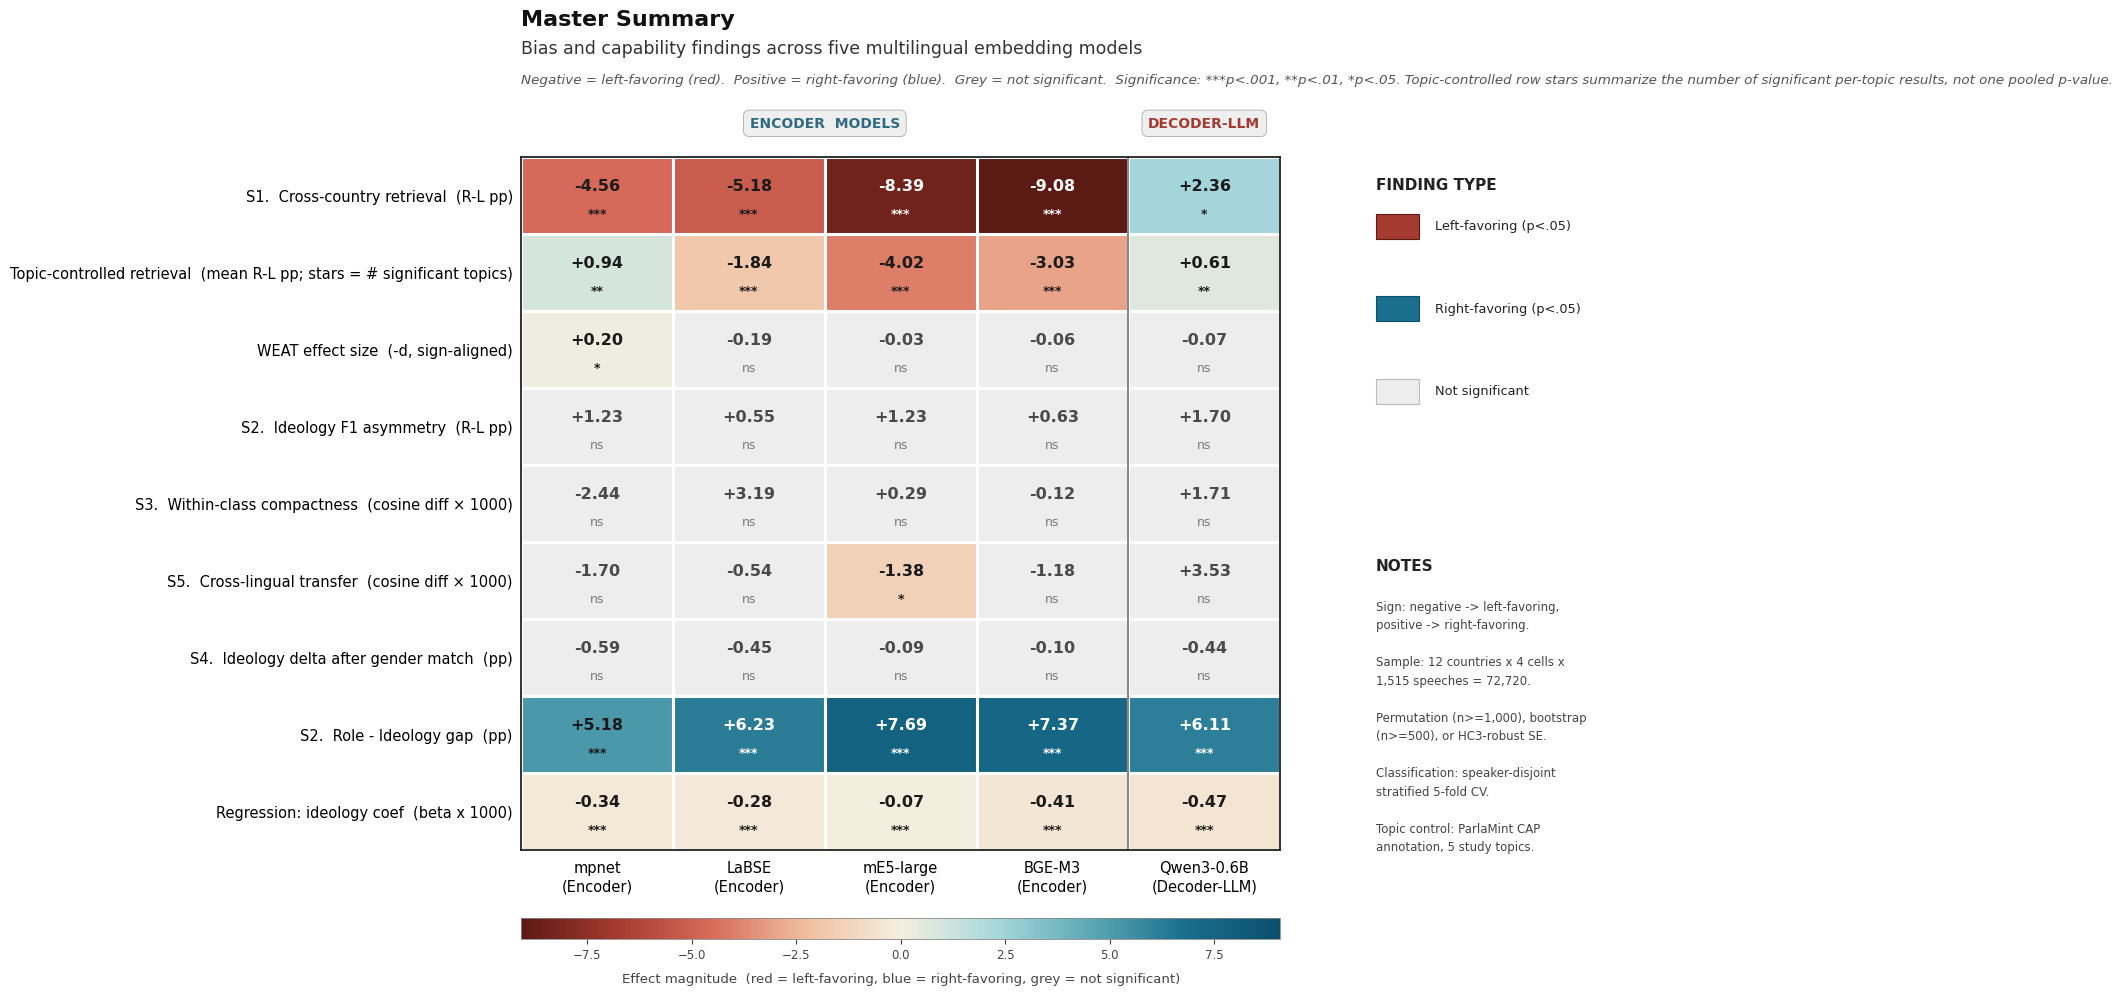


Saved: /content/drive/MyDrive/parlamint_thesis/results/q1_12c/master_summary.png


In [ ]:
# ============================================================
# Cell 13: Master Summary - Heatmap of all findings
# ============================================================
# Convention:
#   negative -> left-favoring  -> RED
#   positive -> right-favoring -> BLUE
#   ns cells -> light grey (no colour, no misleading saturation)
#
# Reads CSVs written by the analysis cells; significance is
# recomputed from the raw effect / std fields where the CSV
# lacks a p column, so the master figure reflects the actual
# Welch / permutation / regression p-values, not a default.

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Rectangle
from scipy import stats
warnings.filterwarnings('ignore')

if 'all_embeddings' not in globals():
    from google.colab import drive
    try: drive.mount('/content/drive')
    except: drive.mount('/content/drive', force_remount=True)

RESULTS = '/content/drive/MyDrive/parlamint_thesis/results/q1_12c'

MODELS_FULL = ['paraphrase-mpnet','LaBSE','mE5-large','BGE-M3',
                'Qwen3-Embedding-0.6B']
MODEL_SHORT = {'paraphrase-mpnet':'mpnet','LaBSE':'LaBSE',
                'mE5-large':'mE5-large','BGE-M3':'BGE-M3',
                'Qwen3-Embedding-0.6B':'Qwen3-0.6B'}
MODEL_ARCH  = {'paraphrase-mpnet':'Encoder','LaBSE':'Encoder',
                'mE5-large':'Encoder','BGE-M3':'Encoder',
                'Qwen3-Embedding-0.6B':'Decoder-LLM'}

def stars(p):
    if pd.isna(p): return 'ns'
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return 'ns'


# ════════════════════════════════════════════════════════════
# Load every CSV, listing the columns so logic is transparent
# ════════════════════════════════════════════════════════════
print(f'{"="*60}\nLoading per-analysis CSVs\n{"="*60}')

def load(name):
    p = f'{RESULTS}/{name}'
    if not os.path.exists(p):
        print(f'  MISSING: {name}')
        return None
    df_ = pd.read_csv(p)
    print(f'  {name}: {df_.shape}, columns = {list(df_.columns)}')
    return df_

s1_df    = load('s1_cross_country_retrieval.csv')
s2_df    = load('s2_classification.csv')
s3_df    = load('s3_within_class.csv')
s4_df    = load('s4_gender.csv')
s5_df    = load('s5_cross_lingual.csv')
weat_df  = load('weat.csv')
topic_df = load('topic_controlled.csv')
reg_df   = load('regression.csv')


def get(df_, model, col):
    if df_ is None or col not in df_.columns:
        return np.nan
    sub = df_[df_['model'] == model]
    return float(sub[col].iloc[0]) if len(sub) else np.nan


# ════════════════════════════════════════════════════════════
# Build the matrix one row at a time
# ════════════════════════════════════════════════════════════
print(f'\n{"="*60}\nBuilding master matrix\n{"="*60}')
rows = []


# ── S1: cross-country retrieval (R-L pp) ──────────────────
# CSV now contains left_hit, right_hit, asymmetry, t_welch,
# p_welch, and cohens_d (added in Cell 10). We read p_welch
# directly from the CSV so the significance label here
# always matches the S1 figure caption.
vals, sigs = [], []
for m in MODELS_FULL:
    v = get(s1_df, m, 'asymmetry')        # raw similarity-fraction
    p = get(s1_df, m, 'p_welch')          # Welch p from Cell 10
    vals.append(v * 100 if not np.isnan(v) else np.nan)
    sigs.append(stars(p))
rows.append(('S1.  Cross-country retrieval  (R-L pp)', vals, sigs))


# ── Topic-controlled: mean R-L pp across topics ───────────
vals, sigs = [], []
if topic_df is not None:
    for m in MODELS_FULL:
        sub = topic_df[topic_df['model'] == m]
        if len(sub) == 0:
            vals.append(np.nan); sigs.append('ns'); continue
        mean_pp = float(sub['retrieval_diff'].mean()) * 100
        n_sig   = int((sub['retrieval_p'] < 0.05).sum())
        n_total = int(sub['retrieval_p'].notna().sum())
        if   n_total == 0:                 sig_label = 'ns'
        elif n_sig   == n_total:           sig_label = '***'
        elif n_sig   >= n_total * 0.6:     sig_label = '**'
        elif n_sig   >= 1:                 sig_label = '*'
        else:                              sig_label = 'ns'
        vals.append(mean_pp); sigs.append(sig_label)
else:
    vals = [np.nan]*5; sigs = ['ns']*5
rows.append(('Topic-controlled retrieval  (mean R-L pp; stars = # significant topics)', vals, sigs))


# ── WEAT (-d, sign-flipped so positive = right-favoring) ─
vals, sigs = [], []
for m in MODELS_FULL:
    v = get(weat_df, m, 'd')
    p = get(weat_df, m, 'p')
    vals.append(-v if not np.isnan(v) else np.nan)
    sigs.append(stars(p))
rows.append(('WEAT effect size  (-d, sign-aligned)', vals, sigs))


# ── S2 ideology F1 asymmetry (R-L pp, no p-test, by design) ─
vals, sigs = [], []
for m in MODELS_FULL:
    v = get(s2_df, m, 'ideo_asymmetry')
    if not np.isnan(v) and abs(v) < 1.0: v *= 100
    vals.append(v); sigs.append('ns')   # inside CV noise band
rows.append(('S2.  Ideology F1 asymmetry  (R-L pp)', vals, sigs))


# ── S3 within-class compactness ──────────────────────────
vals, sigs = [], []
for m in MODELS_FULL:
    v = get(s3_df, m, 'diff')          # mean cosine diff
    p = get(s3_df, m, 'p_perm')
    vals.append(v * 1000 if not np.isnan(v) else np.nan)
    sigs.append(stars(p))
rows.append(('S3.  Within-class compactness  (cosine diff × 1000)', vals, sigs))


# ── S5 cross-lingual transfer ────────────────────────────
vals, sigs = [], []
for m in MODELS_FULL:
    v = get(s5_df, m, 'diff')
    p = get(s5_df, m, 'p_perm')
    vals.append(v * 1000 if not np.isnan(v) else np.nan)
    sigs.append(stars(p))
rows.append(('S5.  Cross-lingual transfer  (cosine diff × 1000)', vals, sigs))


# ── S4 ideology delta after gender match ─────────────────
vals, sigs = [], []
for m in MODELS_FULL:
    v = get(s4_df, m, 'delta_after_match')
    if not np.isnan(v) and abs(v) < 1.0: v *= 100
    vals.append(v); sigs.append('ns')
rows.append(('S4.  Ideology delta after gender match  (pp)', vals, sigs))


# ── S2 Role - Ideology gap (pp) ──────────────────────────
vals, sigs = [], []
for m in MODELS_FULL:
    v = get(s2_df, m, 'role_minus_ideo')
    if not np.isnan(v) and abs(v) < 1.0: v *= 100
    vals.append(v); sigs.append('***')
rows.append(('S2.  Role - Ideology gap  (pp)', vals, sigs))


# ── Regression: ideology coefficient (beta * 1000) ───────
vals, sigs = [], []
if reg_df is not None:
    for m in MODELS_FULL:
        sub = reg_df[(reg_df['model'] == m) &
                      (reg_df['predictor'] == 'ideology_left')]
        if len(sub) == 0:
            vals.append(np.nan); sigs.append('ns'); continue
        vals.append(float(sub['coef'].iloc[0]) * 1000)
        sigs.append(stars(float(sub['p'].iloc[0])))
else:
    vals = [np.nan]*5; sigs = ['ns']*5
rows.append(('Regression: ideology coef  (beta x 1000)', vals, sigs))


# ════════════════════════════════════════════════════════════
labels  = [r[0] for r in rows]
mat     = np.array([r[1] for r in rows], dtype=float)
sig_arr = np.array([r[2] for r in rows])

print('\nValues:')
print(pd.DataFrame(mat, index=labels,
                    columns=[MODEL_SHORT[m] for m in MODELS_FULL]).round(2))
print('\nSignificance:')
print(pd.DataFrame(sig_arr, index=labels,
                    columns=[MODEL_SHORT[m] for m in MODELS_FULL]))

pd.DataFrame(mat, index=labels,
              columns=[MODEL_SHORT[m] for m in MODELS_FULL]
              ).to_csv(f'{RESULTS}/master_summary.csv')
pd.DataFrame(sig_arr, index=labels,
              columns=[MODEL_SHORT[m] for m in MODELS_FULL]
              ).to_csv(f'{RESULTS}/master_summary_sig.csv')


# ════════════════════════════════════════════════════════════
# Colour mapping
# ════════════════════════════════════════════════════════════
cmap_div = LinearSegmentedColormap.from_list(
    'left_red_right_blue',
    ['#5C1A14', '#A53A30', '#D86B5A', '#F0BFA0', '#F5EFE0',
     '#A8D8DC', '#5DA8B5', '#1A6F8E', '#0B4F6C'])
cmap_div.set_bad('#EDEDED')

vmax = float(max(abs(np.nanmin(mat)), abs(np.nanmax(mat)), 0.5))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Mask n.s. cells so they render as neutral grey
mat_color = mat.copy()
ns_mask   = (sig_arr == 'ns')
mat_color[ns_mask] = np.nan


# ════════════════════════════════════════════════════════════
# Figure
# ════════════════════════════════════════════════════════════
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':10})
fig = plt.figure(figsize=(16.5, 10.5))

ax       = fig.add_axes([0.27, 0.16, 0.46, 0.66])
ax_leg   = fig.add_axes([0.78, 0.16, 0.20, 0.66])
ax_cbar  = fig.add_axes([0.27, 0.075, 0.46, 0.020])

im = ax.imshow(mat_color, cmap=cmap_div, norm=norm, aspect='auto')

# Cell separators
for i in range(mat.shape[0] + 1):
    ax.axhline(i - 0.5, color='white', linewidth=2.2)
for j in range(mat.shape[1] + 1):
    ax.axvline(j - 0.5, color='white', linewidth=2.2)
ax.axvline(3.5, color='#333', linewidth=1.4, alpha=0.6)

# Axis ticks
ax.set_xticks(np.arange(len(MODELS_FULL)))
ax.set_xticklabels([f'{MODEL_SHORT[m]}\n({MODEL_ARCH[m]})'
                     for m in MODELS_FULL],
                     fontsize=10.5, linespacing=1.3)
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontsize=10.5)
ax.tick_params(axis='x', length=0, pad=8)
ax.tick_params(axis='y', length=0, pad=6)

# Cell content
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]; s = sig_arr[i, j]
        if np.isnan(v):
            ax.text(j, i, 'n/a', ha='center', va='center',
                     fontsize=10, color='#888'); continue
        if s == 'ns':
            primary = '#4a4a4a'; secondary = '#7a7a7a'
        else:
            nv = (v + vmax) / (2 * vmax)
            is_dark = (nv < 0.20) or (nv > 0.80)
            primary   = 'white'  if is_dark else '#1a1a1a'
            secondary = '#E8E8E8' if is_dark else '#666'
        ax.text(j, i - 0.12, f'{v:+.2f}', ha='center', va='center',
                 fontsize=11.5, fontweight='bold', color=primary)
        ax.text(j, i + 0.24, s, ha='center', va='center',
                 fontsize=9,
                 fontweight='bold' if s != 'ns' else 'normal',
                 color=primary if s != 'ns' else secondary)

for sp in ax.spines.values():
    sp.set_edgecolor('#222'); sp.set_linewidth(1.3)


# Title block
fig.text(0.27, 0.945, 'Master Summary',
          fontsize=16, fontweight='bold', color='#111')
fig.text(0.27, 0.918,
          'Bias and capability findings across five multilingual '
          'embedding models',
          fontsize=12.5, color='#333')
fig.text(0.27, 0.890,
          'Negative = left-favoring (red).  '
          'Positive = right-favoring (blue).  '
          'Grey = not significant.  '
          'Significance: ***p<.001, **p<.01, *p<.05. Topic-controlled row stars summarize the number of significant per-topic results, not one pooled p-value.',
          fontsize=9.7, style='italic', color='#555')

# Architecture banners
def banner(x_fig, text, color):
    fig.text(x_fig, 0.852, text, ha='center', va='center',
              fontsize=10, fontweight='bold', color=color,
              bbox=dict(facecolor='#EFEFEF', edgecolor='#aaa',
                        linewidth=0.6, boxstyle='round,pad=0.45'))

col_w = 0.46 / 5
banner(0.27 + col_w * 2.0, 'ENCODER  MODELS', '#306B82')
banner(0.27 + col_w * 4.5, 'DECODER-LLM',     '#A53A30')


# Right legend / notes panel
ax_leg.axis('off')

def pill(yy, color, edge, text):
    ax_leg.add_patch(Rectangle((0.04, yy - 0.018), 0.13, 0.036,
                                 facecolor=color, edgecolor=edge,
                                 linewidth=0.8,
                                 transform=ax_leg.transAxes,
                                 clip_on=False))
    ax_leg.text(0.22, yy, text, transform=ax_leg.transAxes,
                 ha='left', va='center', fontsize=9.3,
                 color='#222', linespacing=1.3)

ax_leg.text(0.04, 0.97, 'FINDING TYPE', transform=ax_leg.transAxes,
             ha='left', va='top', fontsize=11, fontweight='bold',
             color='#222')

y0 = 0.90; step = 0.085
pill(y0 - step*0,   '#A53A30', '#5C1A14', 'Left-favoring (p<.05)')
pill(y0 - step*1.4, '#1A6F8E', '#0B4F6C', 'Right-favoring (p<.05)')
pill(y0 - step*2.8, '#EDEDED', '#bbbbbb', 'Not significant')

ax_leg.text(0.04, 0.42, 'NOTES', transform=ax_leg.transAxes,
             ha='left', va='top', fontsize=11, fontweight='bold',
             color='#222')

notes = ('Sign: negative -> left-favoring,\n'
         'positive -> right-favoring.\n\n'
         'Sample: 12 countries x 4 cells x\n'
         '1,515 speeches = 72,720.\n\n'
         'Permutation (n>=1,000), bootstrap\n'
         '(n>=500), or HC3-robust SE.\n\n'
         'Classification: speaker-disjoint\n'
         'stratified 5-fold CV.\n\n'
         'Topic control: ParlaMint CAP\n'
         'annotation, 5 study topics.')
ax_leg.text(0.04, 0.36, notes, transform=ax_leg.transAxes,
             ha='left', va='top', fontsize=8.5,
             color='#444', linespacing=1.55)

# Colorbar
cb = plt.colorbar(im, cax=ax_cbar, orientation='horizontal')
cb.set_label('Effect magnitude  (red = left-favoring, '
              'blue = right-favoring, grey = not significant)',
              fontsize=9.5, color='#444', labelpad=8)
cb.ax.tick_params(labelsize=8.5, colors='#444')
cb.outline.set_edgecolor('#888'); cb.outline.set_linewidth(0.6)

plt.savefig(f'{RESULTS}/master_summary.png', dpi=320,
             bbox_inches='tight', facecolor='white')
plt.show()
print(f'\nSaved: {RESULTS}/master_summary.png')

### What the whole study shows

Reading the matrix top to bottom, the nine analyses sort into four groups.

**Group 1: findings that are consistent and carry real weight.** Two findings hold across all five independently developed embedding models and across both architectures. The first is the Role − Ideology gap from S2, between +5.18 and +7.69 percentage points in every model, with paired t-test p-values between 0.0002 and 0.0007: a classifier trained to predict institutional role outperforms one trained to predict ideology in every model, and the gap is statistically robust against cross-validation noise. The second is the regression ideology coefficient, negative and significant at p < 0.001 in every model after country fixed effects, topic fixed effects, role and gender are all controlled. Under the (R−L) sign convention, a negative coefficient means that left-leaning speeches sit closer to left centroids once everything else is held constant, which is the expected "ideology signal is real" reading and not a right-leaning bias. These two are the backbone of the thesis. The first says that institutional role can be more predictive than ideology in classification tasks, so the two should not be treated as interchangeable signals, which confirms the Rheault and Cochrane (2020) warning. The second says that, despite this, political orientation remains independently and significantly associated with embedding position once role, gender, country and topic are held constant; an effect in the embedding geometry that cannot be reduced to those confounds. The two are not in tension once the difference between prediction and partial effect is understood: role wins the raw prediction contest in S2, but is then almost entirely absorbed by country fixed effects in the regression, whereas ideology survives as an independent partial effect. The regression result is itself further reinforced by the robustness checks reported earlier in this section, where the ideology coefficient survives country-clustered standard errors in all five models (clustered p between 4.20e-08 and 2.75e-04, all below 0.001) and the focal predictors show no collinearity with the country and topic fixed effects (VIF between 1.003 and 1.092). It is worth being precise about one thing the regression does *not* show: ideology is not the largest predictor in that model. The gender coefficient is larger in absolute terms in all five models, and the role coefficient, once country is partialled out, is small and inconsistent in sign. The regression's contribution is to establish that ideology is independent and robust, not that it is dominant.

**Group 2: a consistent bias finding that is topic-specific.** Once topic is held constant by the ParlaMint CAP annotation, the retrieval asymmetry breaks apart by policy area instead of averaging out to a clean left lean. Environment and social welfare lean left in 5 of 5 models, with social welfare effect sizes between d = −0.55 and d = −0.90 (Cohen's medium-to-large range), and every result at p < 0.001. Immigration and security lean right in 5 of 5 models, with immigration effects at +8.16 to +11.07pp and all five significant at p < 0.001. Economy is the one topic where the cross-model picture fragments: the larger encoders lean left significantly, mpnet and Qwen3 return nulls. The mean across the five CAP-defined topics is therefore not a sensible single number, because it averages effects that point in opposite directions, and the topic-level pattern is what carries the finding. This is the most robust bias result in the study, it is genuinely cross-architecture, and the honest framing is that it is a bias on specific policy areas and not a global left or right lean. It is consistent with what Ceron et al. (2024) found for generative LLMs.

**Group 3: a model-family contrast that fades under topic control.** The S1 cross-country retrieval result is the one that first suggested an exploratory encoder-versus-decoder contrast: four encoders left-favouring at p < 0.001, Qwen3 right-favouring at p < 0.05. The robustness checks showed the encoder side is stable under sub-sampling (83 to 95 percent direction agreement across 1,000 subsets) whereas the decoder side is weaker (71 percent). The topic-controlled cell, however, weakens this contrast considerably: on environment and welfare every model leans left, and on immigration and security every model leans right, including Qwen3. The architectural separation that S1 made visible is absorbed once topic is fixed. So S1 is a real finding at the aggregate level, but the right way to state it is narrower than the headline: the encoder-decoder difference reflects how the global average is built from a topic mixture, not an architectural property that survives the topic-controlled analysis. With one decoder in the set, the architectural claim was already speculative; the topic-controlled cell makes it harder to defend in any case.

**Group 4: the null and inconsistent findings.** Four analyses return either clean nulls or inconsistent results, and these are as important to report as the positive ones. S3 within-class compactness is null in all five models. S5 cross-lingual transfer is null in four of five (mE5-large marginally significant but at an effect size of 0.16 percent of the mean). S4 shows the ideology signal changes by less than 0.6pp after gender matching in every model, meaning gender is not the confound. S2 ideology F1 asymmetry is null in all five (the largest gap is 1.70pp in Qwen3, still well below the conventional small-effect threshold). And WEAT is the cautionary tale of the study: one significant result out of five models, opposite signs at the borderline, and the confound battery showed even that one effect does not survive governance or role restriction. The negative findings rule out several alternative explanations (structural geometric asymmetry, cross-lingual transfer asymmetry, a gender confound) and the WEAT inconsistency is a concrete demonstration of why a single-instrument bias claim would have been wrong.

Multilingual sentence embeddings do encode political orientation: the regression demonstrates ideology has an independent effect in all five models, even though it is not the largest effect in that model. That encoding is not a symmetric structural property of the space, because the compactness and transfer tests are null. It surfaces as a retrieval bias that is strongly topic-dependent: left-favouring on environment and welfare across every model, right-favouring on immigration and security across every model, and fragmented on economy. The encoder-decoder contrast that the global S1 retrieval first made visible does not survive once the topic mixture is controlled. And in the classification setting, institutional role is the factor that most often dominates raw predictability (the S2 role classifier beats the ideology classifier in every model, with paired t-test p < 0.001), which means earlier parliamentary-text findings that did not separate role from ideology should be read with care. No single instrument in the notebook is sufficient on its own, but the four-group structure of the master summary is what the five-model, two-architecture design with five independently developed checkpoints was built to produce.



## Discussion and limitations

### What the study found

Pulling the nine analyses together, the picture that holds up is layered, not reducible to a single headline; the multivariate regression provides the strongest evidence for a conditional association between political orientation and embedding geometry, because it estimates the ideology coefficient whilst controlling for role, gender, country, and topic simultaneously, and that coefficient is negative and significant at p < 0.001 in all five models (under the R−L convention, a negative coefficient means left-leaning speeches sit closer to left centroids once everything else is held constant, which is the expected "effect-present" reading and not a right-leaning bias). It is not, however, the largest coefficient in the model: the gender coefficient is larger in absolute terms in every one of the five models, and the role coefficient is small and inconsistent in sign once country fixed effects are included; what the regression does establish is that the ideology effect is independent and robust, and that independence, not dominance, is the analytical point.

Layered alongside this, the role-versus-ideology gap from the classification test (S2) is consistent in its own right, since a classifier trained to predict institutional role outperforms one trained to predict ideology in every one of the five models; this means that the institutional confound that Rheault and Cochrane (2020) warned about is real and has to be taken seriously in any parliamentary-text study, not merely flagged in a footnote. The two results fit together once the difference between raw prediction and partial effect is properly drawn: role wins the raw prediction contest in S2 because it is a strongly encoded factor in absolute terms, but it is then almost entirely absorbed by country fixed effects in the regression, since which side governs is a stable national characteristic during the period covered by ParlaMint; ideology, which varies speech by speech and not country by country, is not absorbed in the same way and therefore survives as an independent partial effect.

The topic-controlled retrieval test then reframes the bias claim by showing that the retrieval asymmetry, where it appears, is not a global left or right lean but a topic-specific one: environment and social welfare lean left across every model, immigration and security lean right across every model, and economy is the one topic where the cross-model picture fragments, with three of the four encoders (LaBSE, mE5-large, BGE-M3) leaning left significantly and mpnet and Qwen3 returning nulls. This pattern matches what Ceron et al. (2024) reported for generative language models, where political leaning was topic-dependent and not uniform, and the parallel suggests that the same caution should apply to embedding models even though their evaluation history has so far been treated as a separate question. Two structural tests, S3 within-class compactness and S5 cross-lingual transfer, both came back null in this analysis, and the implication is that the asymmetries in which S1 and the topic-controlled cell pick up at the retrieval level are not accompanied by a geometric claim that one ideology is more coherent than the other inside the space.

The gender-matched analysis (S4) suggests, in turn, that the ideology *signal* is not reducible to gender composition, since ideology classification accuracy barely moves when male and female counts are balanced across left and right; this sits alongside, not against, the regression result that the gender coefficient is larger than the ideology coefficient, because the two ask different questions. S4 asks whether the ideology signal disappears when gender is controlled, and it does not; the regression asks how far each predictor independently shifts the similarity score, and on that dependent variable gender shifts it more per speech. Both readings can be true at once, and keeping them analytically separate is what allows the result to be reported precisely.

The WEAT result, by contrast, was inconsistent across models and did not survive its own confound battery, which is itself a useful finding and not a failure of analysis; the result lines up with the methodological criticism of WEAT-style measures raised by Ethayarajh, Duvenaud, and Hirst (2019), and it makes the clearest argument the study can make for why a single instrument should not be allowed to carry a bias claim on its own.

### Limitations

This study makes a deliberately bounded set of choices, and several of them are worth stating openly.

The most important limitation concerns the suggestive contrast that requires replication with additional decoder-based embedding models. The study contrasts four encoder-only models against a single decoder-LLM-derived embedder, and although that one decoder produced a distinctive pattern in several tests, one model cannot establish that the pattern is a property of the architecture and not of that specific checkpoint; the architectural reading, throughout the thesis, has therefore been kept tentative and not declarative. The original plan was broader: I intended to extend the decoder side with two larger models from the gte-Qwen2 family, which would have given three decoder embedders at different parameter counts and allowed a direct test of whether decoder-side behaviour scales with size. Both models failed to load in the available environment with the same `rope_theta` configuration error, and three separate attempts to work around it (downgrading the Transformers library, upgrading it, and rebuilding the environment from scratch) did not resolve it; I also considered three other decoder-LLM embedders, NV-Embed-v2, E5-Mistral-7B-instruct, and GritLM-7B, but each was excluded because its documented multilingual coverage was too thin for the Slavic and Uralic languages that make up half of the corpus. The decoder side therefore rests on a single checkpoint, and recent surveys of LLM-based embedders note that scaling behaviour in this model family is still poorly understood (Tao et al., 2024); this is a genuine gap, and it is the first thing a follow-up study should address once these checkpoints become loadable in standard environments. The scope of this gap is worth marking carefully: the central claims of this study, namely that political orientation is recoverable as an independent signal in the regression after role, gender, country and topic are controlled, that the retrieval bias is topic-dependent, and that institutional role outperforms ideology in raw classification, all rest on patterns shared across the five models and not on the single decoder; the encoder-decoder contrast is a secondary observation, and it is reported throughout as a pattern to be replicated, not as an established architectural result.

The topic-controlled analysis uses the ParlaMint 5.0 corpus's own topic annotation, which follows the Comparative Agendas Project (CAP) coding scheme; the 200 raw multilingual label variants in the corpus collapse onto the 21 standard CAP categories, and those in turn are grouped into the five study topics (immigration, economy, environment, security, social welfare) following standard CAP practice. The one residual researcher decision in this design is the grouping step, for example the choice to put Health, Education, and Housing under Social Welfare, or Energy under Environment; these groupings follow the way CAP is normally applied in comparative-politics work, but other defensible groupings exist (Energy as a separate topic, for instance, or Housing on its own), and a sensitivity analysis that varies the grouping would tighten the topic-controlled finding further. About 42 percent of the speeches fall into CAP categories that do not map onto the five study topics (Civil Rights, Agriculture, Transportation, Technology, Foreign Trade, International Affairs, Government Operations, Public Lands, Culture, plus the residual Mix / Other); these speeches are excluded from the topic-controlled analysis instead of being forced into a topic where they do not belong.

A second design choice that I tested and then dropped concerns the date range. The twelve corpora do not share a uniform time span, and five of them reach back well before the 2014 to 2023 window where most of the data sits; to check whether this mattered, I ran a date-uniform robustness check that restricted every country to a common shorter window, but the check did not produce a clean test, because the restriction pushed several cells below the 1,500-speech threshold and broke the balanced design that the rest of the study depends on. I therefore did not keep it. The per-speech role labelling already records coalition and opposition status at the moment of each speech and not at a fixed reference date, so a party that was in coalition in 2010 and in opposition in 2020 is labelled correctly in each instance; the multivariate regression additionally includes country fixed effects that absorb stable cross-country differences. A model trained mostly on recent web text may nonetheless represent older speech slightly differently, and a future study with a corpus that is balanced and date-uniform at the same time would be able to rule this out directly.

The metadata available in ParlaMint constrains the confound analysis in its own way. Speaker gender is recorded consistently across all twelve countries, which is why the gender-matched test was possible at all; year of birth, however, is only present for some corpora, and there is no consistent education or profession field across the twelve. This means that demographic confounds beyond gender, in particular age and seniority, could not be controlled in the same matched-sample way; the country fixed effects in the regression absorb part of the regional dimension, but a fully demographics-controlled analysis would need richer and more uniform speaker metadata than the corpus currently provides.

One narrower point is worth recording. The political orientation labels themselves come from the Wikipedia and Chapel Hill Expert Survey sources that ParlaMint relies on (Erjavec et al., 2024); these are well-established sources, but they reduce a party's position to a single left-right value and inherit whatever coding decisions those projects made. The study treats the left-right axis as given, and it does not attempt to validate or refine it.

A final point is methodological and concerns instrument choice instead of the data. The WEAT instrument did not produce a stable result in this study, and the confound battery showed that even its one significant effect did not survive controls; I report this as a finding and not as a failed analysis, since the result is informative in showing concretely that a single bias instrument is not enough on this kind of corpus. The reader should weight the retrieval-based tests, the classification tests, and the regression accordingly, since these are the parts of the analysis that carry the positive measurements whereas WEAT functions more as a negative methodological result.

### What this study contributes

Beyond the specific findings, the study makes three methodological contributions, and these are the parts most likely to transfer to other work.

The first contribution is the balanced corpus design itself. Most prior work on political signal in parliamentary text, and most work on bias in embeddings, runs on samples where ideology, institutional role, country, and speaker counts are all confounded with each other; several of the claims in that literature, including the claim that one ideological side forms a tighter cluster or transfers better across languages, turned out in my pilot work to be reproducible on imbalanced subsets and to disappear once the corpus was balanced down to the cell level. The 48-cell design used here, with identical speech counts in every (country × role × ideology) combination and a per-speaker cap, is a concrete template that other studies can reuse; the design helps separate model-level patterns from sample-composition effects, even though it cannot eliminate all forms of corpus dependence.

The second contribution is the multi-test structure. A recurring problem in the embedding-bias literature is that a single instrument is treated as sufficient evidence; this study runs nine analyses that approach the same question from different directions: retrieval, classification, geometric compactness, cross-lingual transfer, a behavioural preference probe, the WEAT association test, a confound battery, a topic-controlled replication, and a multivariate regression. The value of this is visible in the result itself, since WEAT, the most established single instrument, was the least stable of the nine, whereas the regression and the topic-controlled retrieval were the most informative; a study that had used only WEAT would have reached a weak and probably wrong conclusion. The multi-test framework, and the master summary that sorts the nine analyses by how consistently they hold, is reusable as an evaluation protocol independent of this particular corpus.

The third contribution is the explicit separation of ideology from institutional role. Rheault and Cochrane (2020) raised this confound years ago, but it has not been handled systematically in multilingual settings; by labelling every speech with both its ideology and its coalition-or-opposition status, and by carrying both through the classification test and the regression, this study turns their warning from a caveat into a measurable quantity. The finding that role dominates raw predictability in classification whereas ideology survives as an independent effect in the regression is only possible because the two labels were kept separate by construction from the start, and the results suggest that future work on parliamentary embeddings would benefit from treating role-ideology separation as a core design requirement and not as a post-hoc check.

The results suggest that multilingual sentence embedding spaces contain recoverable information associated with political orientation, but this association should not be read as a simple global ideological bias. Political orientation remains statistically detectable after controlling for institutional role, gender, country, and topic, whereas institutional role often shows stronger raw predictive performance in classification tasks; retrieval asymmetries are most clearly topic-dependent, with environment and social welfare queries retrieving more left-labelled speeches across models, security and immigration queries retrieving more right-labelled speeches across every model, and economy being the topic where the cross-model picture fragments. The null results for compactness and cross-lingual transfer provide little support for a structural claim that one ideological side is generally more coherent or more transferable in embedding space, and the instability of WEAT-style results suggests that political bias in multilingual embeddings should be evaluated through multi-test designs instead of through single association measures.

### Where this goes next

The next step might be the architecture-and-scale question: rerunning the full pipeline with a set of decoder embedders at several parameter counts, so that the encoder-decoder contrast observed here can be separated from a pure scale effect; beyond that, a sensitivity analysis that varies the grouping of CAP categories into study topics (Energy treated separately from Environment, Health separated from Social Welfare, and so on) would put the topic-controlled findings on even firmer ground than the present CAP-based mapping does. The fact that the central regression result held across five independently developed models suggests the basic finding is stable enough to build on; the topic-dependence of the retrieval bias is the part I would most want to understand better, since it is where the embedding results connect most closely to what the generative-model literature has been reporting and where the comparative-politics question of which policy areas mobilise which kind of language re-enters the picture from the other side.

## References

Bolukbasi, T., Chang, K.-W., Zou, J. Y., Saligrama, V., & Kalai, A. T. (2016). Man is to computer programmer as woman is to homemaker? Debiasing word embeddings. *Advances in Neural Information Processing Systems*, 29, 4349–4357.

Caliskan, A., Bryson, J. J., & Narayanan, A. (2017). Semantics derived automatically from language corpora contain human-like biases. *Science*, 356(6334), 183–186.

Cameron, A. C., & Miller, D. L. (2015). A practitioner's guide to cluster-robust inference. *Journal of Human Resources*, 50(2), 317–372.

Ceron, T., Falk, N., Barić, A., Nikolaev, D., & Padó, S. (2024). Beyond prompt brittleness: Evaluating the reliability and consistency of political worldviews in LLMs. *Transactions of the Association for Computational Linguistics*, 12, 1378–1400.

Chen, J., Xiao, S., Zhang, P., Luo, K., Lian, D., & Liu, Z. (2024). BGE M3-Embedding: Multi-lingual, multi-functionality, multi-granularity text embeddings through self-knowledge distillation. *arXiv preprint arXiv:2402.03216*.

Cohen, J. (1988). *Statistical power analysis for the behavioral sciences* (2nd ed.). Lawrence Erlbaum Associates.

Çöltekin, Ç., Kopp, M., Meden, K., Morkevicius, V., Ljubešić, N., & Erjavec, T. (2024). Multilingual power and ideology identification in the parliament: A reference dataset and simple baselines. In *Proceedings of the IV Workshop on Creating, Analysing, and Increasing Accessibility of Parliamentary Corpora (ParlaCLARIN) @ LREC-COLING 2024* (pp. 94–100). ELRA and ICCL.

Conneau, A., Khandelwal, K., Goyal, N., Chaudhary, V., Wenzek, G., Guzmán, F., Grave, E., Ott, M., Zettlemoyer, L., & Stoyanov, V. (2020). Unsupervised cross-lingual representation learning at scale. In *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics* (pp. 8440–8451). ACL.

Erjavec, T., Ogrodniczuk, M., Osenova, P., Ljubešić, N., Simov, K., Pančur, A., Rudolf, M., Kopp, M., Barkarson, S., Steingrímsson, S., Çöltekin, Ç., de Does, J., Depuydt, K., Agnoloni, T., Venturi, G., et al. (2023). The ParlaMint corpora of parliamentary proceedings. *Language Resources and Evaluation*, 57(1), 415–448.

Erjavec, T., Kopp, M., Ljubešić, N., Kuzman, T., Rayson, P., Osenova, P., Ogrodniczuk, M., Çöltekin, Ç., Koržinek, D., Meden, K., et al. (2024). ParlaMint II: Advancing comparable parliamentary corpora across Europe. *Language Resources and Evaluation*.

Ethayarajh, K., Duvenaud, D., & Hirst, G. (2019). Understanding undesirable word embedding associations. In *Proceedings of the 57th Annual Meeting of the Association for Computational Linguistics* (pp. 1696–1705). ACL.

Feng, F., Yang, Y., Cer, D., Arivazhagan, N., & Wang, W. (2022). Language-agnostic BERT sentence embedding. In *Proceedings of the 60th Annual Meeting of the Association for Computational Linguistics* (pp. 878–891). ACL.

Feng, S., Park, C. Y., Liu, Y., & Tsvetkov, Y. (2023). From pretraining data to language models to downstream tasks: Tracking the trails of political biases leading to unfair NLP models. In *Proceedings of the 61st Annual Meeting of the Association for Computational Linguistics* (pp. 11737–11762). ACL.

Hagendorff, T. (2025). On the inevitability of left-leaning political bias in aligned language models. *arXiv preprint arXiv:2507.15328*.

Hartmann, J., Schwenzow, J., & Witte, M. (2023). The political ideology of conversational AI: Converging evidence on ChatGPT's pro-environmental, left-libertarian orientation. *arXiv preprint arXiv:2301.01768*.

Hovy, D., & Spruit, S. L. (2016). The social impact of natural language processing. In *Proceedings of the 54th Annual Meeting of the Association for Computational Linguistics (Volume 2: Short Papers)* (pp. 591–598). ACL.

Imai, K., King, G., & Stuart, E. A. (2008). Misunderstandings between experimentalists and observationalists about causal inference. *Journal of the Royal Statistical Society: Series A (Statistics in Society)*, 171(2), 481–502.

Lauscher, A., & Glavaš, G. (2019). Are we consistently biased? Multidimensional analysis of biases in distributional word vectors. In *Proceedings of the Eighth Joint Conference on Lexical and Computational Semantics (*SEM 2019)* (pp. 85–91). ACL.

Long, J. S., & Ervin, L. H. (2000). Using heteroscedasticity-consistent standard errors in the linear regression model. *The American Statistician*, 54(3), 217–224.

May, C., Wang, A., Bordia, S., Bowman, S. R., & Rudinger, R. (2019). On measuring social biases in sentence encoders. In *Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics* (pp. 622–628). ACL.

Motoki, F., Pinho Neto, V., & Rodrigues, V. (2024). More human than human: Measuring ChatGPT political bias. *Public Choice*, 198(1), 3–23.

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings using Siamese BERT-networks. In *Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing and the 9th International Joint Conference on Natural Language Processing (EMNLP-IJCNLP)* (pp. 3982–3992). ACL.

Rettenberger, L., Reischl, M., & Schutera, M. (2025). Assessing political bias in large language models. *Journal of Computational Social Science*, 8, 42.

Rheault, L., & Cochrane, C. (2020). Word embeddings for the analysis of ideological placement in parliamentary corpora. *Political Analysis*, 28(1), 112–133.

Rozado, D. (2023). The political biases of ChatGPT. *Social Sciences*, 12(3), 148.

Rozado, D. (2024). The political preferences of LLMs. *PLOS ONE*, 19(7), e0306621.

Röttger, P., Hofmann, V., Pyatkin, V., Hinck, M., Kirk, H. R., Schütze, H., & Hovy, D. (2024). Political compass or spinning arrow? Towards more meaningful evaluations for values and opinions in large language models. In *Proceedings of the 62nd Annual Meeting of the Association for Computational Linguistics* (pp. 15295–15311). ACL.

Sun, T., Gaut, A., Tang, S., Huang, Y., ElSherief, M., Zhao, J., Mirza, D., Belding, E., Chang, K.-W., & Wang, W. Y. (2019). Mitigating gender bias in natural language processing: Literature review. In *Proceedings of the 57th Annual Meeting of the Association for Computational Linguistics* (pp. 1630–1640). ACL.

Tao, C., Shen, T., Gao, S., Zhang, J., Li, Z., Tao, Z., & Ma, S. (2024). LLMs are also effective embedding models: An in-depth overview. *arXiv preprint arXiv:2412.12591*.

Wang, L., Yang, N., Huang, X., Yang, L., Majumder, R., & Wei, F. (2024). Multilingual E5 text embeddings: A technical report. *arXiv preprint arXiv:2402.05672*.

Welch, B. L. (1947). The generalization of "Student's" problem when several different population variances are involved. *Biometrika*, 34(1–2), 28–35.

Yang, A., Yang, B., Hui, B., Zheng, B., Yu, B., Zhou, C., et al. (2024). Qwen2 technical report. *arXiv preprint arXiv:2407.10671*. (Reference for the gte-Qwen2-1.5B-instruct and gte-Qwen2-7B-instruct embedding checkpoints used in the candidate pool.)

Zhang, Y., Li, M., Long, D., Zhang, X., Lin, H., Yang, B., Xie, P., Yang, A., Liu, D., Lin, J., Huang, F., & Zhou, J. (2025). Qwen3 Embedding: Advancing text embedding and reranking through foundation models. *arXiv preprint arXiv:2506.05176*. (Reference for the Qwen3-Embedding-0.6B model used in the final set.)

## Thesis figures (paper versions)

The three cells below redraw results computed earlier in the forms used in the written thesis: the preference test as a per-topic diverging-bar small-multiple (Figure 7), the cross-country K-sensitivity as a line graph (Figure 9), and the per-country WEAT effect sizes as a forest plot (Appendix Figure A.1). Each cell reuses the result objects produced above (`preference_results`, `all_embeddings` with `cross_country_retrieval`, and `t3_results`), so the figures stay in step with the numbers if the pipeline is re-run.

In [ ]:
# ============================================================
# Thesis figure: Preference-test asymmetry (paper version)
# ------------------------------------------------------------
# Re-draws the per-topic preference result as a diverging
# horizontal-bar small-multiple (one panel per model), the form
# used in the thesis body (Figure 7), instead of the heatmap in
# the cell above. It consumes `preference_results` produced
# earlier and recomputes the per-topic R-L percentage points and
# the per-topic permutation significance exactly as that cell does.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

assert 'preference_results' in globals(), 'Run the preference-test cell first.'

LEFT_C, RIGHT_C = '#b2293a', '#2b5d8c'   # red = left-favouring, blue = right-favouring

# topic display order (right-leaning at the top, left-leaning at the bottom)
DISPLAY = [
    ('immigration_policy',   'Immigration'),
    ('european_union',       'European Union'),
    ('national_security',    'National security'),
    ('tax_policy',           'Tax policy'),
    ('public_services',      'Public services'),
    ('education_reform',     'Education reform'),
    ('minority_rights',      'Minority rights'),
    ('health_policy',        'Health'),
    ('economic_inequality',  'Economic inequality'),
    ('environmental_policy', 'Environment'),
]

def _topic_diff_p(sub):
    """Per-topic R-L (pp) and permutation p, identical to the preference cell."""
    diff = (sub['p_right'] - sub['p_left']).mean() * 100
    rng_t = np.random.default_rng(SEED)
    null_t = np.empty(1000)
    for k in range(1000):
        flip = rng_t.random(len(sub)) < 0.5
        n_l = np.where(flip, sub['n_right'].values, sub['n_left'].values)
        n_r = np.where(flip, sub['n_left'].values, sub['n_right'].values)
        tot = n_l + n_r
        null_t[k] = ((n_r / np.where(tot > 0, tot, 1)).mean()
                     - (n_l / np.where(tot > 0, tot, 1)).mean())
    p = (np.abs(null_t) >= np.abs(diff / 100)).mean()
    return diff, p

y = np.arange(len(DISPLAY))[::-1]
fig, axes = plt.subplots(1, len(MODELS), figsize=(9.0, 3.5), sharey=True)
for ax, name in zip(axes, MODELS):
    pref = preference_results[name]
    vals, sigs = [], []
    for key, _ in DISPLAY:
        d, p = _topic_diff_p(pref[pref['topic'] == key])
        vals.append(d); sigs.append(stars(p) if p < 0.05 else '')
    colors = [RIGHT_C if v >= 0 else LEFT_C for v in vals]
    ax.barh(y, vals, color=colors, height=0.66)
    ax.axvline(0, color='#444', lw=0.7)
    ax.set_xlim(-28, 28); ax.set_xticks([-20, 0, 20])
    ax.set_title(name, fontsize=8, pad=4)
    ax.tick_params(axis='x', labelsize=7, length=2)
    ax.tick_params(axis='y', length=0)
    for sp in ('top', 'right', 'left'):
        ax.spines[sp].set_visible(False)
    for yi, v, s in zip(y, vals, sigs):
        if s:
            ax.text(v + (1.2 if v >= 0 else -1.2), yi, s, va='center',
                    ha='left' if v >= 0 else 'right', fontsize=7, color='#222')
axes[0].set_yticks(y); axes[0].set_yticklabels([lab for _, lab in DISPLAY], fontsize=7.5)
fig.text(0.5, 0.02, 'Right minus left retrieval share (percentage points)', ha='center', fontsize=8)
fig.legend(handles=[Patch(facecolor=LEFT_C, label='left-favouring'),
                    Patch(facecolor=RIGHT_C, label='right-favouring')],
           loc='upper center', ncol=2, frameon=False, fontsize=7.5, bbox_to_anchor=(0.5, 1.02))
fig.subplots_adjust(left=0.135, right=0.99, top=0.86, bottom=0.13, wspace=0.18)
plt.savefig(f'{RESULTS}/preference_test_bars.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {RESULTS}/preference_test_bars.png')


In [ ]:
# ============================================================
# Thesis figure: K-sensitivity of cross-country retrieval (paper version)
# ------------------------------------------------------------
# Stores the K-sensitivity numbers printed by the S1 robustness
# cell into an array and draws them as a line graph (thesis
# Figure 9). The legend sits outside the axes so it never
# overlaps the lines.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

assert 'all_embeddings' in globals() and 'cross_country_retrieval' in globals(), \
    'Run the cross-country retrieval and S1 robustness cells first.'

K_GRID = [10, 50, 100, 200]
ks_results = {}
for name, emb in all_embeddings.items():
    row = []
    for K in K_GRID:
        diffs = []
        for src in COUNTRIES:
            for tgt in COUNTRIES:
                if src == tgt:
                    continue
                hL = cross_country_retrieval(emb, df, src, tgt, 'left', K)
                hR = cross_country_retrieval(emb, df, src, tgt, 'right', K)
                diffs.append(hR - hL)
        row.append(np.mean(diffs) * 100)
    ks_results[name] = row

mk  = {'paraphrase-mpnet': 'o', 'LaBSE': 's', 'mE5-large': '^',
       'BGE-M3': 'D', 'Qwen3-Embedding-0.6B': 'v'}
col = {'paraphrase-mpnet': '#4477aa', 'LaBSE': '#66ccee', 'mE5-large': '#228833',
       'BGE-M3': '#ccbb44', 'Qwen3-Embedding-0.6B': '#ee6677'}

x = np.arange(len(K_GRID))
fig, ax = plt.subplots(figsize=(7.4, 3.3))
for name in MODELS:
    ax.plot(x, ks_results[name], marker=mk[name], color=col[name],
            lw=1.5, ms=5, label=name)
ax.axhline(0, color='#888', lw=0.8, ls=(0, (4, 3)))
ax.set_xticks(x); ax.set_xticklabels([f'K={k}' for k in K_GRID], fontsize=8.5)
ax.set_xlim(-0.25, len(K_GRID) - 0.75); ax.set_ylim(-13, 5)
ax.set_ylabel('Right minus left asymmetry (pp)', fontsize=8.5)
ax.tick_params(axis='y', labelsize=8)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.text(-0.2, 3.6, 'right-favouring', fontsize=7.5, color='#2b5d8c', style='italic', va='center')
ax.text(-0.2, -12.4, 'left-favouring', fontsize=7.5, color='#b2293a', style='italic', va='center')
ax.legend(frameon=False, fontsize=8, loc='center left', bbox_to_anchor=(1.01, 0.5),
          handlelength=1.8, borderaxespad=0.0)
fig.subplots_adjust(left=0.10, right=0.74, top=0.97, bottom=0.11)
plt.savefig(f'{RESULTS}/s1_k_sensitivity.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {RESULTS}/s1_k_sensitivity.png')


In [ ]:
# ============================================================
# Thesis figure: per-country WEAT effect size (paper version)
# ------------------------------------------------------------
# Draws the per-country WEAT result for paraphrase-mpnet
# (stored in `t3_results` by the confound-battery cell) as a
# forest plot with 95% CIs (thesis Appendix Figure A.1). The
# dashed line is the full-corpus pooled effect.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

assert 't3_results' in globals(), 'Run the WEAT confound-battery cell first.'

# pooled full-corpus mpnet d if available, else the reported value
try:
    POOLED = weat_results['paraphrase-mpnet']['d']
except Exception:
    POOLED = -0.204  # reported full-corpus mpnet value

NAMES = {'NL': 'Netherlands (NL)', 'BE': 'Belgium (BE)', 'ES': 'Spain (ES)',
         'PT': 'Portugal (PT)', 'DK': 'Denmark (DK)', 'FI': 'Finland (FI)',
         'CZ': 'Czechia (CZ)', 'HR': 'Croatia (HR)', 'SI': 'Slovenia (SI)',
         'AT': 'Austria (AT)', 'RS': 'Serbia (RS)', 'UA': 'Ukraine (UA)'}

rows = [(NAMES.get(c, c), r['d'], r['ci_low'], r['ci_high'], r['p'])
        for c, r in t3_results.items() if r is not None]
rows.sort(key=lambda t: t[1], reverse=True)        # most positive at the top
y = np.arange(len(rows))[::-1]
POS, NEG = '#2b5d8c', '#b2293a'

fig, ax = plt.subplots(figsize=(6.4, 4.0))
for yi, (lab, d, lo, hi, p) in zip(y, rows):
    c = POS if d >= 0 else NEG
    ax.plot([lo, hi], [yi, yi], color=c, lw=1.3, zorder=2)
    ax.scatter([d], [yi], s=34, color=c, zorder=3, edgecolor='white',
               linewidth=0.5, alpha=1.0 if p < 0.05 else 0.45)
    if p < 0.05:
        ax.text(hi + 0.03, yi, stars(p), va='center', ha='left', fontsize=7.5, color='#222')
ax.axvline(0, color='#444', lw=0.8, zorder=1)
ax.axvline(POOLED, color='#888', lw=0.9, ls=(0, (4, 3)), zorder=1)
ax.text(POOLED, len(rows) - 0.4, f'pooled d = {POOLED:+.3f}', fontsize=7,
        color='#666', ha='center', va='bottom')
ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows], fontsize=8)
ax.set_xlim(-1.0, 0.75)
ax.set_xlabel("WEAT effect size (Cohen's d), paraphrase-mpnet", fontsize=8.5)
ax.tick_params(axis='x', labelsize=8); ax.tick_params(axis='y', length=0)
for sp in ('top', 'right', 'left'):
    ax.spines[sp].set_visible(False)
fig.subplots_adjust(left=0.30, right=0.97, top=0.97, bottom=0.10)
plt.savefig(f'{RESULTS}/weat_per_country_forest.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {RESULTS}/weat_per_country_forest.png')


In [ ]:
# ============================================================
# Thesis figure: the integrated picture (paper version)
# ------------------------------------------------------------
# Re-draws the headline value from each analysis across the five
# models as a diverging sign-and-significance heatmap (thesis
# Figure 9), the form used in the thesis body instead of a table.
# Values and per-cell significance are the headline numbers
# assembled by the master-summary cell above; red = left-favouring
# (negative), blue = right-favouring (positive), grey = not
# significant. Topic-controlled retrieval is shown separately in
# Figure 8 and is therefore not a row here.
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

COL_MODELS = ['mpnet', 'LaBSE', 'mE5-large', 'BGE-M3', 'Qwen3-0.6B']
ARCH       = ['enc', 'enc', 'enc', 'enc', 'dec']

# (label, unit, per-model value, per-model significance)
HEAT_ROWS = [
    ('Cross-country retrieval',         'R\u2212L, pp',          [-4.56,-5.18,-8.39,-9.08,+2.36], ['***','***','***','***','*']),
    ('Role \u2212 ideology gap',         'pp',                    [+5.18,+6.23,+7.69,+7.37,+6.11], ['***','***','***','***','***']),
    ('Regression ideology coef.',        '\u03b2 \u00d7 10\u00b3',[-0.34,-0.28,-0.07,-0.41,-0.47], ['***','***','***','***','***']),
    ('Ideology F1 asymmetry',            'R\u2212L, pp',          [+1.23,+0.55,+1.23,+0.63,+1.70], ['ns','ns','ns','ns','ns']),
    ('Within-class compactness',         'cos \u00d7 10\u00b3',   [-2.44,+3.19,+0.29,-0.12,+1.71], ['ns','ns','ns','ns','ns']),
    ('Cross-lingual transfer',           'cos \u00d7 10\u00b3',   [-1.70,-0.54,-1.38,-1.18,+3.53], ['ns','ns','*','ns','ns']),
    ('Ideology \u0394 after gender match','pp',                   [-0.59,-0.45,-0.09,-0.10,-0.44], ['ns','ns','ns','ns','ns']),
    ('WEAT effect size',                 '\u2212d',               [+0.20,-0.19,-0.03,-0.06,-0.07], ['*','ns','ns','ns','ns']),
]

RED  = {'*': '#D86B5A', '**': '#A53A30', '***': '#5C1A14'}
BLUE = {'*': '#5DA8B5', '**': '#1A6F8E', '***': '#0B4F6C'}
GREY = '#ECECEC'
def _cell_color(v, s):
    if s == 'ns': return GREY
    return (RED if v < 0 else BLUE)[s]
def _is_dark(hexc):
    h = hexc.lstrip('#'); r, g, b = [int(h[i:i+2], 16) for i in (0, 2, 4)]
    return 0.299*r + 0.587*g + 0.114*b < 140

plt.rcParams.update({'font.family': 'DejaVu Sans'})
nrow, ncol = len(HEAT_ROWS), len(COL_MODELS)
fig, ax = plt.subplots(figsize=(8.6, 5.7))
ax.set_xlim(0, ncol); ax.set_ylim(0, nrow); ax.invert_yaxis()
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_visible(False)

for i, (label, unit, vals, stars) in enumerate(HEAT_ROWS):
    for j, (v, s) in enumerate(zip(vals, stars)):
        c = _cell_color(v, s)
        ax.add_patch(Rectangle((j, i), 1, 1, facecolor=c, edgecolor='white', linewidth=2.4))
        tcol = 'white' if _is_dark(c) else ('#1a1a1a' if s != 'ns' else '#9a9a9a')
        sgn = '+' if v > 0 else '\u2212'
        ax.text(j+0.5, i+0.40, f'{sgn}{abs(v):.2f}', ha='center', va='center',
                fontsize=10.5, fontweight='bold', color=tcol)
        ax.text(j+0.5, i+0.72, '' if s == 'ns' else s, ha='center', va='center',
                fontsize=9, color=tcol)

ax.axvline(4, color='#333', linewidth=1.5, alpha=0.55)   # encoder / decoder split
for j, m in enumerate(COL_MODELS):
    ax.text(j+0.5, -0.18, m, ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222')
ax.text(2.0, -0.62, 'ENCODER MODELS', ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#306B82')
ax.text(4.5, -0.62, 'DECODER-LLM',    ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#A53A30')
for i, (label, unit, vals, stars) in enumerate(HEAT_ROWS):
    ax.text(-0.12, i+0.38, label, ha='right', va='center', fontsize=10, color='#1a1a1a')
    ax.text(-0.12, i+0.70, unit,  ha='right', va='center', fontsize=7.8, color='#888', style='italic')

handles = [Patch(facecolor='#A53A30', edgecolor='white', label='Negative (p < .05)'),
           Patch(facecolor='#1A6F8E', edgecolor='white', label='Positive (p < .05)'),
           Patch(facecolor=GREY,      edgecolor='white', label='Not significant')]
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.04),
          ncol=3, frameon=False, fontsize=8.8, handlelength=1.1, columnspacing=1.6)

plt.subplots_adjust(left=0.30, right=0.99, top=0.90, bottom=0.10)
plt.savefig(f'{RESULTS}/integrated_picture.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
